# Prithvi-EO-2.0 burn-scar mapping — DIMER E2E segmentation fine-tuning tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/prithvi-burnscar-segmentation-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/prithvi-burnscar-segmentation-pipeline/blob/main/tutorials/prithvi_burnscar_segmentation_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-ibm--nasa--geospatial%2FPrithvi--EO--2.0--300M--BurnScars-ffcc4d?style=flat)](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars) [![Upstream](https://img.shields.io/badge/Upstream-NASA--IMPACT%2FPrithvi--EO--2.0-181717?style=flat&logo=github&logoColor=white)](https://github.com/NASA-IMPACT/Prithvi-EO-2.0) [![Paper](https://img.shields.io/badge/arXiv-2412.02732-b31b1b.svg)](https://arxiv.org/abs/2412.02732)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.0 — **standalone** (§4)  
**Capability:** burn-scar segmentation of six-band HLS scenes with a Prithvi-EO-2.0 ViT-L encoder and U-Net decoder, held-out IoU/F1 against a not-burned baseline, and bounded fine-tuning of the decoder to labelled scenes

**This notebook is standalone.** It carries the repository's package (3 modules under `src/prithvi_burnscar_segmentation_pipeline/`, at revision `fbeff73285b8`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `a3f2c410e45b8ac7417976614528a872f024d831` (~1317 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.2); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh **GPU** runtime builds an isolated environment from the hash-locked pins (torch, torchvision, terratorch and its stack, tifffile, numpy, safetensors, huggingface-hub); nothing is installed into the notebook's own Python, so no restart is needed and Run all completes in one pass. It then stages and digest-verifies the pinned Prithvi burn-scar checkpoint (1.30 GB) from the Hub, statically audits the Lightning pickle against an allow-list, converts it once into safetensors with a pinned digest, rebuilds the architecture from the installed `terratorch` package and loads it strictly, fetches the digest-pinned HLS Burn Scars tarball (2.6 GB, no credential) and extracts exactly the 44 pinned scenes and masks, validates them and assigns the model repository's roles (24 training, 8 validation, 12 test), segments the held-out scenes with the frozen model and scores them against the not-burned baseline, runs a bounded fine-tuning of the neck, U-Net decoder and head, scores the same scenes again, segments the three example scenes shipped with the upstream repository, exports the adapter as safetensors with a manifest, and reloads that artifact into a fresh pipeline to verify prediction parity. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.0 §5). On a T4 the whole path takes a few minutes of model time after the downloads; building the isolated environment and the tarball are the slowest steps.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell to supply your own labelled scenes — as `BYOD_PATH` (a path in the runtime, which works on Colab, Kaggle and Jupyter) or, when it is empty, through the Colab upload dialog — as a zip (or folder) holding `pairs.csv` (columns `id`, `image`, `label`) beside six-band 512 × 512 GeoTIFF chips (blue, green, red, narrow NIR, SWIR 1, SWIR 2 — surface reflectance in [0, 1] or × 10 000) and single-band label rasters (0 = not burned, 1 = burn scar, −1 = no data); at least **7** labelled chips with some burn scar (the seeded 25 % test / 20 % validation split must leave the 4 training chips adaptation needs; Section 4 prints the minimum and refuses a smaller set by name). An optional `group` column (a fire or HLS tile id) keeps every chip of one group in one role, so neighbouring scenes of one fire cannot sit on both sides of the split. Your chips flow through the same contract — validation, frozen baseline, adaptation, held-out evaluation, inference, artifact export and reload parity; Section 5 puts the model back to the pinned base first, so the frozen numbers on your scenes are the packaged model's. The expected schema, the ceilings and the privacy guidance are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

Prithvi-EO-2.0 (Szwarcman et al., 2024) is NASA and IBM's foundation model for Harmonized Landsat Sentinel-2 imagery: a ViT-L masked autoencoder pretrained on 4.2 M global multispectral samples. The checkpoint packaged here is the upstream authors' fine-tune for burn-scar mapping — the 300 M-parameter encoder, a learned pyramid neck over four encoder depths, a U-Net decoder and a two-class head — trained on the 804 labelled HLS scenes of the HLS Burn Scars dataset (2018–2021, contiguous United States) with TerraTorch, on the non-overlapping splits the authors publish beside the checkpoint.

Two things about this row are handled in the open. **The upstream asset is a pickle** — a PyTorch Lightning checkpoint. Section 3 downloads and digest-verifies it, statically lists every global the pickle would import (a state dict of tensors and nothing else), refuses anything outside that allow-list, unpickles it exactly once through torch's weights-only loader, and writes a safetensors file whose digest is pinned in the carried module; the model you run is rebuilt from the installed `terratorch` package and loads that file strictly. **The dataset ships as one 2.6 GB tarball**, so Section 4 pins the tarball by size and digest, streams through it once and copies out exactly the 88 pinned members (each pinned again by size and digest, no `extractall`, no paths taken from the archive), and leaves the other 1,522 alone. **The model is already fine-tuned on this dataset**, so the bounded adaptation in Section 6 is a demonstration of the contract, selected by validation loss with the frozen model as epoch 0; the point of the contract is the same recipe applied to *your* labelled scenes.

**Learning objectives:** install the pinned runtime; inspect the carried pipeline, dataset and metrics modules; stage and digest-verify a pickled checkpoint, read its static audit and see it converted into safetensors; extract pinned members from a digest-verified tarball and validate real labelled multispectral scenes with an ignore class; read pixel IoU, F1, precision and recall against a not-burned baseline; run a bounded decoder fine-tuning with explicit hyperparameters and frozen BatchNorm statistics; compare the adapted and frozen models on the same held-out scenes, per scene and pooled, and look at the masks; segment the upstream example scenes; and export a safetensors adapter that reloads against the pinned base with verified parity. The three example scenes are not new to the checkpoint — the notebook shows where each one comes from.

**This notebook does not demonstrate:** burn severity or dNBR estimation, active-fire detection, temporal stacks (the packaged fine-tune is single-date), tiling of scenes larger than 512 × 512, atmospheric correction, cloud masking, the published benchmark scores, and any claim that a 44-scene sample stands in for an operational evaluation. The repository exposes none of these.

**Who this notebook is for.** The intended audience is a learner who knows basic Python, has used Colab or Jupyter, and wants to see how a geospatial foundation model fine-tuned for one task is evaluated and adapted honestly: how its burn-scar maps are scored against a baseline that predicts *not burned* everywhere, what a bounded fine-tuning of the decoder does to a model that already trained on this dataset, and how the change is exported and reloaded. No prior experience with Prithvi, TerraTorch or remote sensing models is assumed; terms are explained where they first matter and again in the **Glossary** at the end. A GPU runtime (T4 or better) is expected.

**Input → Model → Output.**

| | Segmentation | Bounded fine-tuning |
|---|---|---|
| Input | six-band 512 × 512 HLS reflectance chips (blue, green, red, narrow NIR, SWIR 1, SWIR 2) | labelled chips with 0 / 1 / −1 masks (24 training, 8 validation, 12 test in the sample) |
| Model | the Prithvi-EO-2.0 ViT-L encoder, pyramid neck, U-Net decoder and two-class head, loaded from audited, converted safetensors | the same model; only the neck, decoder and head (20.3 M parameters) are trained, the encoder and BatchNorm statistics stay frozen |
| Output | a per-pixel burn-scar mask, softmax scores, burn fraction; pixel IoU / F1 beside the not-burned baseline | the adapted model's numbers beside the frozen model's on the same held-out scenes, and an 81 MB safetensors adapter that reloads with parity |

**How to use this notebook.** Choose a GPU runtime (**Runtime → Change runtime type → T4 GPU**), then **Runtime → Run all**. Run all completes in one pass: Section 1 installs nothing into the notebook's own Python, so no restart is needed. Sections 1–3 are **infrastructure** — the isolated environment, the carried package and the audited model snapshot — and their cells are collapsed; you may run them without studying them. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited, and the defaults reproduce the recorded run. Before each principal result the notebook asks you to **Predict**; after it come **What to notice** and a collapsible **Check your reasoning** with a worked answer from the recorded run (the Kaggle Tesla T4 run of 25 September 2026 recorded in `docs/release-verification.md`). Every adaptation starts from the pinned base, so re-running Section 6 with other settings is a fresh experiment. **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Writing your predictions down is optional.

**Roadmap:** 1–3 infrastructure → 4 the labelled scenes, validation and refusals *(evaluation practice)* → 5 the frozen model against the not-burned baseline *(core concept)* → 6 bounded fine-tuning of the neck, decoder and head *(core concept)* → 7 the held-out paired comparison with per-scene numbers and a figure *(evaluation practice)* → 8 the upstream example scenes and their provenance, export and fresh reload *(engineering)* → interpretation, an optional experiment, troubleshooting, glossary and your conclusion.

## Prerequisites

- **Runtime:** a fresh supported **GPU** runtime (Google Colab T4 or better, or a Jupyter kernel with a CUDA GPU and Python 3.12): the ViT-L encoder runs in float16 autocast and the default adaptation needs about 2.5 GB of GPU memory; on CPU one 512 × 512 scene takes tens of seconds and the adaptation would take an hour. About 6 GB of disk is needed for the checkpoint, its conversion and the tarball; building the isolated environment (terratorch pulls torchgeo, lightning and their dependencies) takes several minutes the first time and is reused on a re-run.
- **Knowledge:** what a multispectral surface-reflectance scene is (bands, scaling, no-data), what a pixel-wise segmentation mask and an ignore class are, and how IoU, precision and recall are read against a majority baseline.
- **Executable serialization handled explicitly:** the pinned checkpoint is a pickle. It is digest-verified, statically audited against an allow-list (audit digest pinned) and unpickled **once** through torch's weights-only loader to produce the safetensors the model is actually loaded from. No Hub-hosted Python module is imported; `terratorch` is installed from PyPI at a pinned version.
- **Data contract:** a record is `{id, image, label}` — a (6, 512, 512) reflectance array (or a GeoTIFF; 13-band Sentinel-2 L1C files are reduced to the six HLS-equivalent bands) with values in [0, 1] or × 10 000, no-data 0 or −9999, and a (512, 512) mask with 0 / 1 / −1. Validation is structural: nothing checks that the bands are the right six in the right order, that the reflectance is corrected, or that the label belongs to the scene.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — commercial imagery under licence or unreleased fire-damage assessments are exactly that. The default path uploads nothing.
- **External access (data):** besides the model snapshot, the default path fetches one pinned object — the 2.6 GB `hls_burn_scars.tar.gz` of the Hugging Face dataset `ibm-nasa-geospatial/hls_burn_scars` at an immutable revision — over HTTPS, digest-verified before any member is read; the dataset is CC BY 4.0 (NASA IMPACT / University of Alabama in Huntsville).
- **External access:** the Hugging Face Hub only, to fetch the pinned `ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars` snapshot (~1317 MB in total) at revision `a3f2c410e45b…`. No GitHub access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 131 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab and Kaggle import some packages, NumPy and often PyTorch among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env_<lock digest>/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 131 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins in the cell) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message.

The same cell then starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. It is the only cell that runs in the kernel (it is marked `# dimer: kernel cell`), and it is safe to re-run: a complete environment built from this exact lock is reused rather than rebuilt, and a live worker is kept with every variable created so far, so the cells after it keep working. To start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Infrastructure: build (or reuse) the isolated environment and route later cells to it
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import signal
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from multiprocessing.connection import Connection
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'terratorch==1.2.13',
    'tifffile==2026.9.15',
    'numpy==2.5.3',
    'safetensors==0.8.0',
    'huggingface-hub==1.32.0',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = '0f2c040bc50a894db19a8fcacfb407a22ad5b05ba4dc7af612e64dceddcb2315'
LOCKED_PACKAGES = 131
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
absl-py==2.5.0 \
    --hash=sha256:0c996f25c0490700fadabe6351630f6111534fa0ae252cc6d2014ea3b141135f \
    --hash=sha256:0f17b89f2a4eaaedc4f28c622998aa690564b3012a396a4ffad0821007fe03ba
    # via tensorboard
aenum==3.1.17 \
    --hash=sha256:0dad0421b2fbe30e3fb623b2a0a23eff823407df53829d6a72595e7f76f3d872 \
    --hash=sha256:8b883a37a04e74cc838ac442bdd28c266eae5bbf13e1342c7ef123ed25230139 \
    --hash=sha256:a969a4516b194895de72c875ece355f17c0d272146f7fda346ef74f93cf4d5ba
    # via lightly
affine==3.0.1 \
    --hash=sha256:cda3b303325e7bf2bf34817e68753a0d1c4cacbdd451fe67c4878dc2ecbaa540 \
    --hash=sha256:e1b3c38c5d4d3ef5024a182a6d1bf1e0c51ab221825781c741aeb4d0c079a7e2
    # via rasterio
aiohappyeyeballs==2.7.1 \
    --hash=sha256:065665c041c42a5938ed220bdcd7230f22527fbec085e1853d2402c8a3615d9d \
    --hash=sha256:9243213661e29250eb41368e5daa826fc017156c3b8a11440826b2e3ed376472
    # via aiohttp
aiohttp==3.14.3 \
    --hash=sha256:03cd2bde3d7f085b64e549c985f4bb928cad7e8ecf5323bfca320db548d81b39 \
    --hash=sha256:041badb8f84396357c4d3ad26de6afd7a32b112f43d3c63045c0c8278cfd2043 \
    --hash=sha256:0a5ff2dfbb9ce645fa5b8ef3e02c6c0b9cc3f6030ff863d0c51fffc50cb5541b \
    --hash=sha256:0fdea2281997af69da84c77ffa6f5938a0285f21fb3887c249d67419ca865b3d \
    --hash=sha256:11fb37ef075669eee52ab1928fbf6e1741fada40409fa309ebde9607a962aebf \
    --hash=sha256:134ac5ddcf61c6fad984b9a5727d83492ada43d63471db20fb73042c13fca62f \
    --hash=sha256:152516815ef926786a0b6ae2b8f1fd2e0c71582dee0b435636865316fd4891b7 \
    --hash=sha256:1576145bdceeb92382d899751e12743a3a5b8e460a841e3e50543859e54864dc \
    --hash=sha256:16100ad3ab8d649fdfbee87602d9d2dcdca9df0b9eda8a1b5fdc0d41f96da559 \
    --hash=sha256:16ea7e24c309fb7c0bbd505d149abe4fe4dccfb8db911db7dbec0921bc889a6f \
    --hash=sha256:18c441d0a8fca6de8d1f546849b9f0ab20d435993e2c5b59562b2fae6be2f929 \
    --hash=sha256:18cb43369747b2ae007bd2655fb8e63a099c2ff1d207962943636dac989b3147 \
    --hash=sha256:1b59533861b70a2185c8f4f350f791f39d64358ef6944ce71c5240c9ec0982c9 \
    --hash=sha256:1c5281acc88b92396f88c7e1e2748f8466689df22b80170e4f51efa712fb47a8 \
    --hash=sha256:1c5ec8fb1bcc31a8466f74aaf26c345d5c386fa4bd08a3f0eb9c7a4a3fe8b5bf \
    --hash=sha256:1caa7b0d05f3e3a36f87788c59e970a7ee1cefcfcbb924a9f138c4a6551c9cb7 \
    --hash=sha256:21c016079415ed3fd676963e9793700a566d85dbbd6bfc564b9b2d209147dcc8 \
    --hash=sha256:2498f0fe69ead802f9675beca44a7c21c62fdaa4ec5145ea1c3ad6edbee29f85 \
    --hash=sha256:25bd2708db6bdf6a6630dd37bdcdfcb47c4434d22ac69c64665b802910140b30 \
    --hash=sha256:270d3dace9ca2f10f0da5d8ebe519b7a310fc6112ed916e32df5866df0888553 \
    --hash=sha256:2e1161602f45a54de2ce0905243a95f58cb42dcd378402f3697f5e0b21e9d2e7 \
    --hash=sha256:2e9878ae68e4a5f1c0abe4dd497dbc3d51946f5837b56759e2a02e78fa90ef86 \
    --hash=sha256:30402d03a7c0ff52bce290b57e564e9079fd9d0cb545c8aba73f86a103162d2e \
    --hash=sha256:33a2d7c28d33797a2e99923dffa63f83d908a19b6bf26cfe80fa790aa5e1a75a \
    --hash=sha256:362a3fd481769cac1a824514bcd86fda51c65e8fe6e051099e008fddde6db17c \
    --hash=sha256:38901a84da3ce22249f6e860bf8f90d141bcab7da090cc398f8bb58c0e44b7da \
    --hash=sha256:39aded8c7f3b935b54aab1d8d73c70ec0ee2d3ec3b943e0e86611bc150ba47f5 \
    --hash=sha256:3a26434dafe408229ff3403458ca58de24fb51936504decac49ce6755f77e59d \
    --hash=sha256:3ae5b3a59436d089b5395d910121a390feed4d00578eb95a0fd1a329fe963100 \
    --hash=sha256:3d4f72af88ac2474bb5bca640030320e3d38a0163a1d7533500e87be458eef71 \
    --hash=sha256:3f42e9b78301f11c8f861746175d8b9c1ccef713fcad9eab396e2f6db8ed4a22 \
    --hash=sha256:42a67efc36300d052fb4508a53e8b6901b9284b599ae63945c377569c5fcc1e1 \
    --hash=sha256:48d67b87db6279c044760787eb01f6413032c2e6f3ba1cafaa492b1c8e578479 \
    --hash=sha256:498c6c623134f8e09a3c4e60bcd607a0b4590dd7dbf08dd40851b27cbb520ccb \
    --hash=sha256:49f7325beb0f85ef4aef5f48f490269575f83e6e2acad00a1d80b807eb027062 \
    --hash=sha256:4e3ac92d90e92773b2362d506068e9a948192bd553e743c5b2429e28527c8661 \
    --hash=sha256:530125ee1163c4219af35dc3aa1206e541e7b31b6efc1a3f93b70a136f65d427 \
    --hash=sha256:5373dc80ad1aa2fb9ad95c83f24eef418bbda3a61375f128e5b0192e4f3f9b32 \
    --hash=sha256:53e5179d8abb5710f8e83ba207c41c8d1261fcffd4616500e15ca2b7a33be10a \
    --hash=sha256:53e7b4ce82b54a8bcc71b3b67a5cbd177ca1d7f592cbc92cd38b7349f73482db \
    --hash=sha256:543906c127fb1d929b95076db19b83fa2d46751006ff1e23b093aa5ac4d8db42 \
    --hash=sha256:54cfcdee2770dac994417cbb0ee1f3eb0e7cb6b30c79bf44f2c02ff79ec5124a \
    --hash=sha256:55bdcc472aafe2de4a253045cc128007a64f1e0264fb675791e132ea5edaa3bd \
    --hash=sha256:56f355e79f71aef2a85c80305cc915f894b170dba76de5fe84f6351939b83c06 \
    --hash=sha256:5895ef58c4620afe02fa16044f023dc4dafec08158f9d08874a46a7dbc0341b8 \
    --hash=sha256:5bcb6ff3fdab1258a192679ff1a05d44f59626430aa05cd1a9d2447423599228 \
    --hash=sha256:5f08ec777f35ee70720233b8b9811d3bb5d728137f30ac91b7457709c3261ac0 \
    --hash=sha256:614c61d478b83953e261d02bb2df750f17227cd33ef8002945bf5aebbde21919 \
    --hash=sha256:617105e2c3018ee38d0c8ce5ee3c84f621a6d8b9f723202aacaff28449ca91ee \
    --hash=sha256:6debfa7312ff9d4c124dc71d72e9a0a4b9e0879e48ba6fcb42bef5c3300289e2 \
    --hash=sha256:7041d52c3a7fa20c9e8c182b534704abb19502c8bdcbde7ab23bfda6f642394f \
    --hash=sha256:70c987b27534f9ae1a723f47ae921571d616da21d3208282bf4c52af5164ac43 \
    --hash=sha256:74ab5b6a9fb13e873e5a90946588baecaf488745e1db1a4a5c433f971f035098 \
    --hash=sha256:78253b573e6ffab5028924fc98bc281aae05445969982a10864bc360dea2016c \
    --hash=sha256:7a75aa63cbf9b21cfaf60dc2657e19df2c2867d91707d653fee171ffeedd1371 \
    --hash=sha256:8800c996b01c2772a783e3e46f3e1abd5823029adca0df54231960de9bfefa5b \
    --hash=sha256:89176250f686cb9853c0fb7ead90e639e915b84a6f43eedc2a4e7ec21f1037f0 \
    --hash=sha256:8a5fd34f7f7410d1730d5c2ba873cacb2eed3fede366feb268a70ba22581ed8f \
    --hash=sha256:8b3b60de05f3dcb6f6a00f818bb2ec781cee4de0645f59ccaf99b1d1823b6100 \
    --hash=sha256:8f2f1c4c032c7cedd7d8da6f54c97b70266c6570c3108d3fdffee7188bb70529 \
    --hash=sha256:9491196535a88924a60afd5b5f434b5b203b6cc616250878dbdb223a8f7844bc \
    --hash=sha256:9aa6e61fdf20105c4144e755bd586008ff450791d67b1c8146fdc15959c4d51c \
    --hash=sha256:9d9edccfe496b476db5f398d97b865e9a6752bcf8aec4eef8390ce20fb64bb41 \
    --hash=sha256:9fc7b5bfec6573f3ae844f457fdde5adeb713f8b8e4a81ad64fc207b49383716 \
    --hash=sha256:a0dc483c00da8b673abbb367eb6f8d8f4bcec30eb58529ea13cb42e7fd2dfa33 \
    --hash=sha256:a3a8296e7ab5c295f53f1041487cb088e1480775aafbf7fe545d93b770a0f96f \
    --hash=sha256:a3e22975f905b89a55a488c2a08f2fdb2186175349e917d48985cc468a3d4c6e \
    --hash=sha256:a4af35c443e0b1a1bd6a8af3f3485d7fda15c142751a00f3ff8090f0b93346fa \
    --hash=sha256:a94dbaae5ae27bd849c93570669bff91e0510f33a80805738e3de72a7be0447b \
    --hash=sha256:ac74facc01463f138b0da5580329cfcc82818dea5656e83ddcd11268fc12ff80 \
    --hash=sha256:ad4c8b7488d745d2ca4838ebd8ae5ba9b56341d30b1da43640e4ce87f9f49646 \
    --hash=sha256:b014a6ed7cf912e787149fdc529166d3ceabac23f26efeea3158c9aba2354e7e \
    --hash=sha256:b20032766aedf6261c7a566585a40867d092ac03a0d81592d5370ef9b054f99b \
    --hash=sha256:b2466434105a4e03113c36ec775cc2ebe6676b62eae326fa670bb607ef788c1c \
    --hash=sha256:b304db572b4368edd8dda8a2274f73156fe15558fca4a917cb8a09fc47af5963 \
    --hash=sha256:ba59d59aba08ac02fc03b0c8983ccd5ee39a199d0552ce9e6d2b4845b34d59ae \
    --hash=sha256:bd52f811e65f6fb634b1047159657c98f52b407f8efec907bcfc09da9a4c0a25 \
    --hash=sha256:bdd0e2834dce1a26c1bbe26464861e16bbe217042cbff619247c11594472518c \
    --hash=sha256:c23ec8ee9d5ab2f5421f9c7fffce208435607af27fd46d4a44e031954352838f \
    --hash=sha256:c39846c3aad97a8530c89d7a3869a8f8e9e3762c6ac0504481e5c80948f7e807 \
    --hash=sha256:c3c200cf9757edd785051dc699c7ecbec22110dbfcb3fefc7a9f9695eda8ea7a \
    --hash=sha256:c7d3a97c678d34fc5b59da671ee9cd630096ddc643e7b5a30d54a2a6f3574d3f \
    --hash=sha256:c8653fd547c93a61aadc612007790f5555cdd18946fa48cf45e26d8ea4ea473d \
    --hash=sha256:cc7cb243a68167172f48c1fd43cee91ec4b1d40cefd190edd43369d1a6bc9c82 \
    --hash=sha256:ccd4893707b3e2a13e39c90d43cf80edf2e4d0457935bcc103bf2346214c3f15 \
    --hash=sha256:cd817772b2fcf2b8c0905795318485f9ec16eae60b29feb7f4c77085311637f0 \
    --hash=sha256:cda5fd5c95ad7a125a2e8464acc78b98b94c475a3780d6aa0aa157c93f470f4d \
    --hash=sha256:cef89a58e628c4efcac3275c2d68083f82426dcdc89c1492a6f654f9f7ea6ab9 \
    --hash=sha256:d1558173930a5a8d3069cee5c92fc91c87c4dbcb099debbb3622053717145a19 \
    --hash=sha256:d6088ec9894113802bddb3c09e974929aed2c7b3a8c456219b8aab4481f1a239 \
    --hash=sha256:d6218d92e450824e9b4881f44e8c09f1853b490f9a64130801024a4793b1b3b0 \
    --hash=sha256:d77640cc618c1d99fc4f8589c0f24a730adfa54eb1e57ef7bf0c8dfb78da898c \
    --hash=sha256:d7d2deec16eeedf55f2c7cf75b521ea3856a5177e123844f8fd0f114ce252cb5 \
    --hash=sha256:db332af25642007330fca8be5c4d194caf2bea7a7fc84415aff3497af5dfee6b \
    --hash=sha256:dd54d0e8717de95939766febac482ac0474d8ac3b048115f9f2b1d23a16e7db4 \
    --hash=sha256:ddcac3c6b382e81f1dd0499199d4136b877beb4cb5ef770bbbfba56c4b8f55d2 \
    --hash=sha256:df82f3787c940c94986b34222d59c9e38843fba85139f36e85255a82ad5355a9 \
    --hash=sha256:dfa68deb2a443bdaa3ea5297b0699c1464f08aef3812b486d1348eee61b07dc0 \
    --hash=sha256:dff9461ec275f22135650d5ba4b4931a11f3958df7dfbb8db630000d4dee0883 \
    --hash=sha256:e1e74298bab6ee0d6e749ed4fd1901c7e604bdda32c03d787a2cc71c46d0433d \
    --hash=sha256:e2667f0bbe7eb6c74eae5e9691441ad186e5845ca3cff63230fc09c4e7514f5d \
    --hash=sha256:e3be98a7c30b8c25d573dafba7171d66dfb05ee6a9070fc46535464ff97700a6 \
    --hash=sha256:e568e14940c09955aa51f4e645b6daa18a581c5dcfcd73744dcc86a856e3ced3 \
    --hash=sha256:e72ee89e28d907a18f46959b4eb0bb06701cc7f8cf4366e00029e2ccfaaf5924 \
    --hash=sha256:e92eb8acc45eb6a9f4935071a77edf5b85cc6f8dfad5cd99e97653c26593cdde \
    --hash=sha256:ea05e1f97ceea523942d9b2a7d7c0359d781d683d6b043f5943a602b14da4787 \
    --hash=sha256:eac645b09bcfdf73df7536331f0678c1086ea250981118ddb5199e17ccef72bb \
    --hash=sha256:eb0495d778817619273c108784292be161a924b9f5ae5cbbc70a2caa6838250b \
    --hash=sha256:ebe8e504f058fe91223351cecd2d9d6946c9d241bb0250d898ffbdf584cc72b0 \
    --hash=sha256:ed099d105449c4f9e84f24af203cd131349d4761d8813fa7e02c32e7128cd910 \
    --hash=sha256:f0f177d1b195b9e06376cfd7d308d8a1b920909a609d03ac82a8c73bbb16d3b9 \
    --hash=sha256:f3d2669fe7dec7fc359ecdb5984b29b50d85d5d00f8c1cb61de4f4a24ee42627 \
    --hash=sha256:f4e05329faa0ea1a404b37de4f034fd2c2defcca06a68dc6745e4e56c88e8a48 \
    --hash=sha256:f53bcd52f585e1ac3e590d61434eb61f9a88c38df041b4ea126d97144344a77b \
    --hash=sha256:f55119f7bf25f49ed210f6096090715da24f2943c62102448915fde3c62877ce \
    --hash=sha256:f631fe87a6f30df5fbe6d79640b25e4cffb38c31c7fb6f10871517b84b0f8c1a \
    --hash=sha256:f8fb78a83c9e5f741ca3a68cfb455c1f5bb83b4e7249a3848b3cd78d0a8563b0 \
    --hash=sha256:fa9467a8113aa69d3d7c55a70ef0b7c636010a40993f3df9d9d0d73b3eb7ef24 \
    --hash=sha256:fd51ebf9d3a00c074df4ede271023f4d2dba289bcc740b88191872716014e3c5
    # via fsspec
aiosignal==1.4.0 \
    --hash=sha256:053243f8b92b990551949e63930a839ff0cf0b0ebbe0597b0f3fb19e1a0fe82e \
    --hash=sha256:f47eecd9468083c2029cc99945502cb7708b082c232f9aca65da147157b251c7
    # via aiohttp
albucore==0.0.24 \
    --hash=sha256:adef6e434e50e22c2ee127b7a3e71f2e35fa088bcf54431e18970b62d97d0005 \
    --hash=sha256:f2cab5431fadf94abf87fd0c89d9f59046e49fe5de34afea8f89bc8390253746
    # via
    #   albumentations
    #   terratorch
albumentations==2.0.8 \
    --hash=sha256:4da95e658e490de3c34af8fcdffed09e36aa8a4edd06ca9f9e7e3ea0b0b16856 \
    --hash=sha256:c4c4259aaf04a7386ad85c7fdcb73c6c7146ca3057446b745cc035805acb1017
    # via terratorch
annotated-types==0.8.0 \
    --hash=sha256:13b2beaad985e05e2d6407ee4c4f35590b11f8d693a258a561055cac8f64cab7 \
    --hash=sha256:f072f4d804ea359e4eaf198b1af7a8b0943881a87f31bb764f8bf219bb9419e0
    # via pydantic
anyio==4.15.1 \
    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \
    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94
    # via httpx
attrs==26.1.0 \
    --hash=sha256:c647aa4a12dfbad9333ca4e71fe62ddc36f4e63b2d260a37a8b83d2f043ac309 \
    --hash=sha256:d03ceb89cb322a8fd706d4fb91940737b6642aa36998fe130a9bc96c985eff32
    # via
    #   affine
    #   aiohttp
    #   rasterio
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   httpcore
    #   httpx
    #   lightly
    #   pyogrio
    #   pyproj
    #   rasterio
    #   requests
charset-normalizer==3.5.2 \
    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \
    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \
    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \
    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \
    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \
    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \
    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \
    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \
    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \
    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \
    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \
    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \
    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \
    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \
    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \
    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \
    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \
    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \
    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \
    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \
    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \
    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \
    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \
    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \
    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \
    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \
    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \
    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \
    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \
    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \
    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \
    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \
    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \
    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \
    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \
    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \
    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \
    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \
    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \
    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \
    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \
    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \
    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \
    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \
    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \
    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \
    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \
    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \
    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \
    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \
    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \
    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \
    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \
    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \
    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \
    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \
    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \
    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \
    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \
    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \
    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \
    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \
    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \
    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \
    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \
    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \
    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \
    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \
    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \
    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \
    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \
    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \
    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \
    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \
    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \
    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \
    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \
    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \
    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \
    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \
    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \
    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \
    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \
    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \
    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \
    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \
    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \
    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \
    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \
    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \
    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \
    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \
    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \
    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \
    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \
    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \
    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \
    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \
    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \
    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \
    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \
    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \
    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \
    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \
    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \
    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \
    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \
    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \
    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \
    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \
    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \
    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \
    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \
    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \
    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \
    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \
    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \
    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \
    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \
    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \
    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \
    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \
    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \
    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \
    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \
    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \
    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \
    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \
    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \
    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \
    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \
    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \
    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \
    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \
    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \
    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \
    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \
    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \
    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \
    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \
    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \
    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \
    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \
    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \
    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \
    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \
    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \
    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \
    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \
    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \
    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \
    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \
    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \
    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \
    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \
    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \
    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \
    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \
    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \
    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \
    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \
    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \
    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \
    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \
    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \
    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \
    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \
    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \
    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \
    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \
    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \
    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f
    # via requests
click==8.5.0 \
    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \
    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34
    # via
    #   huggingface-hub
    #   rasterio
cloudpickle==3.1.2 \
    --hash=sha256:7fda9eb655c9c230dab534f1983763de5835249750e85fbcef43aaa30a9a2414 \
    --hash=sha256:9acb47f6afd73f60dc1df93bb801b472f05ff42fa6c84167d25cb206be1fbf4a
    # via joblib
contourpy==1.4.0 \
    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \
    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \
    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \
    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \
    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \
    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \
    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \
    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \
    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \
    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \
    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \
    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \
    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \
    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \
    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \
    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \
    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \
    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \
    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \
    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \
    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \
    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \
    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \
    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \
    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \
    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \
    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \
    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \
    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \
    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \
    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \
    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \
    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \
    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \
    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \
    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \
    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \
    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \
    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \
    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \
    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \
    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \
    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \
    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \
    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \
    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \
    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \
    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \
    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \
    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \
    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \
    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \
    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \
    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \
    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \
    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \
    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \
    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \
    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \
    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \
    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \
    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \
    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \
    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \
    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \
    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \
    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \
    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \
    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \
    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707
    # via matplotlib
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
cycler==0.12.1 \
    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \
    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c
    # via matplotlib
diffusers==0.40.0 \
    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \
    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541
    # via terratorch
docstring-parser==0.18.0 \
    --hash=sha256:292510982205c12b1248696f44959db3cdd1740237a968ea1e2e7a900eeb2015 \
    --hash=sha256:b3fcbed555c47d8479be0796ef7e19c2670d428d72e96da63f3a40122860374b
    # via jsonargparse
einops==0.8.2 \
    --hash=sha256:54058201ac7087911181bfec4af6091bb59380360f069276601256a76af08193 \
    --hash=sha256:609da665570e5e265e27283aab09e7f279ade90c4f01bcfca111f3d3e13f2827
    # via
    #   terratorch
    #   torchgeo
filelock==4.0.12 \
    --hash=sha256:5f17ee83ecee8a6f3e389c75822fb70a1c2f0506b99438a6dffa1d56793588c8 \
    --hash=sha256:cf42711a7ac791818b299fab0332a088c65aeeefa36290de98db92c434303b0c
    # via
    #   diffusers
    #   huggingface-hub
    #   torch
fonttools==4.66.1 \
    --hash=sha256:058cd823b80bac59e64dfad9e3b6fcd677852f9a3804971bbf6b48cc611e785c \
    --hash=sha256:05aeb146451f37289f782c3c861f3d0f4b86c2dd2e4620b46683544c7406640e \
    --hash=sha256:05c0fff6b4a5d872ed89cab2c4f81060b86ace263903eb4e8d0edcac47a60dfa \
    --hash=sha256:08d8956e3ec990c75230d92f1630b215e8f3738c83a003421c22b31ebfd0ce15 \
    --hash=sha256:09ae73bd219e1245debd8376077a0fa6e03175e255c4f51bae5f6a271bfe384a \
    --hash=sha256:0dc6fd99cb8c30941036308b148da9432640442a6f26f36d71dad9be24cbd0e9 \
    --hash=sha256:1801fdad5600118327171e0e8aa79f7cc48831dd55ab36998c9de03bd5ffe6cd \
    --hash=sha256:261d8dc95845e751f975fe8d6075600593ee253470d46d1b84801688051b09f6 \
    --hash=sha256:2aeb745f2664eb811026997c95628071137a777ea2ad296deec9cb393f0b23cf \
    --hash=sha256:2c7340497cf53490293e0c2b61011e0191633022ede0a0a964a68157a98b0fb4 \
    --hash=sha256:2ce4c93160535761f22c80b2afbc96cabc09855363a5d1a5554265b8a4c85901 \
    --hash=sha256:2d320483928c7831f0139ecb361954a26b2e2a8995681200155835dd8cd4a7d5 \
    --hash=sha256:2d637468dac23aac0e223bd52e66f8faa3b0dfcef57435460fa2107e830226cd \
    --hash=sha256:3087a430722aba8de429c2539fd2a58a9cf05238cdfefd8626460001052ca878 \
    --hash=sha256:34378db9a398b59de18cc79d942f0a907c6fc6301945e065ec888202f607aa3f \
    --hash=sha256:36bb24d4b98faacaff04af1d5e0a4285feba6ed1da6728cd34b6b6deb6bbb934 \
    --hash=sha256:38ce8f5fbd5c17dd2153d47d7c8d4108f3deda3f2b4a79b60ddc470a58faded3 \
    --hash=sha256:43d1284c1964666ee833f2badd3017dc138f53d4889043ffca66c5ce4188f188 \
    --hash=sha256:53e5854ea8003efec34adc0863c18ce91da923018354d27366f7fee7db928d7a \
    --hash=sha256:56d41d650cb8fc6cfe1d85ed7c62a0a56cbeed07bc65ca795475b914d401312a \
    --hash=sha256:5de5d80fbc0e50ff794c244e8fb7afd3eadfe0fa232ba8b162b8c551df22fcb4 \
    --hash=sha256:60f5ea17aed4262630afa43f26997ceabd6417fa05dcedf54c665f5a29193e18 \
    --hash=sha256:64967c6ddb0d4c610dfd8cb1485981b2d27972ddfb7d4bbbd9e199d2a089c450 \
    --hash=sha256:668f092bc0de8902167df6a0d5c5aedc3b4f9e43cf88eea92e9b46a2bd3968f5 \
    --hash=sha256:66fad3b7874062c2a2692f0ae6dea56d24f01b778c7f191950ca3ff997e25a88 \
    --hash=sha256:6946fe7bfb28590a1fd4061a17609c9a843952deb65dcf30d1fe725070c3e7a4 \
    --hash=sha256:71c7ca1b5f46f5dd549f56b47d47c0b709217675c23d3a7bc6aa1a69b6d9bbae \
    --hash=sha256:72299346b96b9244dabcc051b24e4653da4edfda6105544cfb10ce856a1afaac \
    --hash=sha256:7234ae9e28db64273fbbfa72caebd0a97e3bdba6b05064114741b9539ef339d0 \
    --hash=sha256:7b8ff9e0edbcee2fbf7dff0c41b9041c1901c26acf64e23adb67495012df11de \
    --hash=sha256:7cf4f996f9b1cb549bff9ea4c50813988a26ec922c95cfa85c7e4f1270447e06 \
    --hash=sha256:7f49f2834f5d006fe0f3bb10fec73b261806c50941f0cfbc08294074ffc32210 \
    --hash=sha256:83572afe48733bad7a4a9c11721d3a726c2e976d82b063fc9bdd049d76955abd \
    --hash=sha256:8526b2b7ec4db6b81efb83438be52b1264eda9a4994d867163cfe8c65581ce8d \
    --hash=sha256:8aed2bbcd6216253ef1b015763593365ee8084f621dfa53bb957c19d5e05f7cd \
    --hash=sha256:90de3477394c73481d27d2b86091c1c736053ee13ff52c42f0e151948e8578c6 \
    --hash=sha256:9261ef507f2dd74203443a472b65b5a26429eb378f975016dec7dc7305b24898 \
    --hash=sha256:9ea6c93091cbf83161a544388746a0911550bd98cb911faca3591cf5ead166ac \
    --hash=sha256:b13c8c541ce0b794add3211b3641cc0e113d707f73e06235e6fe9731bd7c45a9 \
    --hash=sha256:b18803cbdef248e7ee1be59cb277fbbe1da1faaa6f726fa5d3557904e6a3d967 \
    --hash=sha256:b878c78b2af11b879bd4f26bb0d8bda2a4c64543fdd3f28efe2c80f97f043885 \
    --hash=sha256:b8b71db96d605784e2c5ebf0788a406018ea8fdd80338491f4c83613d5cd1fec \
    --hash=sha256:b913b8e9f7ca9bec44d1eb919f591c596c61041aa357c96be55ff93169859e91 \
    --hash=sha256:c258eba62260beb33c110b03a6912cefa3635239c4ab5615b7225fb6f7b85238 \
    --hash=sha256:c47299bca4b5acaaeb32100f77b944feea151de9ef1773365a410dc3d49b945b \
    --hash=sha256:c666fefdd5613a0e99aa4516e6ff4ef87aa86cf1c7ba12a73550f4770e46b750 \
    --hash=sha256:c724e56213494c6695335577822b2d1628d102e71614de8b7eb8e30886d6a314 \
    --hash=sha256:d3b5403e82d0c7659ff1d9f956e29a3a68d094f043e9f5bc0442796fc3a4fb58 \
    --hash=sha256:d4f76868aea9cc4ce47fdbeaa904c02ee7d85dd0ad095071ae77f0bda6e62cf5 \
    --hash=sha256:d84ac0bf776b68396185bd919dd29e633d94300660335efc40b55b294b886903 \
    --hash=sha256:d8f0a8f16c4f3a5a87ca971de2631792d8cb4d570951f2000acf712f157d40db \
    --hash=sha256:dbb7b950f8c02deaffb6968994691e8589d671b7ef8396bc9d5b5c0dfbb7292f \
    --hash=sha256:dfba62cc93199ba62c376f90f2a9147d92730d301e44f88e013e50ff5edf6193 \
    --hash=sha256:e1cde50b3ec84ca6fe63ca815de183dbecb88e8adf8ada82d8ea130ef12b2b43 \
    --hash=sha256:e7ea7a08547a453fa000db96ed5714a3dc7e2b4255b9243f897921f8c10c169a \
    --hash=sha256:eef76d5796e604f9d6753fa6d323c4eb9f4e0e43f1dcca553f3e6914f1667b64 \
    --hash=sha256:f08ab7f8461c37ecfdd29ad97fb0c0780b50501bd664bb0f46b6e83ed2b9d2a7 \
    --hash=sha256:fdf4afd75c643e60ef4a96fe64fc8a9def27d2a542112332371a9e5066885f9a
    # via matplotlib
frozenlist==1.8.0 \
    --hash=sha256:0325024fe97f94c41c08872db482cf8ac4800d80e79222c6b0b7b162d5b13686 \
    --hash=sha256:032efa2674356903cd0261c4317a561a6850f3ac864a63fc1583147fb05a79b0 \
    --hash=sha256:03ae967b4e297f58f8c774c7eabcce57fe3c2434817d4385c50661845a058121 \
    --hash=sha256:06be8f67f39c8b1dc671f5d83aaefd3358ae5cdcf8314552c57e7ed3e6475bdd \
    --hash=sha256:073f8bf8becba60aa931eb3bc420b217bb7d5b8f4750e6f8b3be7f3da85d38b7 \
    --hash=sha256:07cdca25a91a4386d2e76ad992916a85038a9b97561bf7a3fd12d5d9ce31870c \
    --hash=sha256:09474e9831bc2b2199fad6da3c14c7b0fbdd377cce9d3d77131be28906cb7d84 \
    --hash=sha256:0c18a16eab41e82c295618a77502e17b195883241c563b00f0aa5106fc4eaa0d \
    --hash=sha256:0f96534f8bfebc1a394209427d0f8a63d343c9779cda6fc25e8e121b5fd8555b \
    --hash=sha256:102e6314ca4da683dca92e3b1355490fed5f313b768500084fbe6371fddfdb79 \
    --hash=sha256:11847b53d722050808926e785df837353bd4d75f1d494377e59b23594d834967 \
    --hash=sha256:119fb2a1bd47307e899c2fac7f28e85b9a543864df47aa7ec9d3c1b4545f096f \
    --hash=sha256:13d23a45c4cebade99340c4165bd90eeb4a56c6d8a9d8aa49568cac19a6d0dc4 \
    --hash=sha256:154e55ec0655291b5dd1b8731c637ecdb50975a2ae70c606d100750a540082f7 \
    --hash=sha256:168c0969a329b416119507ba30b9ea13688fafffac1b7822802537569a1cb0ef \
    --hash=sha256:17c883ab0ab67200b5f964d2b9ed6b00971917d5d8a92df149dc2c9779208ee9 \
    --hash=sha256:1a7607e17ad33361677adcd1443edf6f5da0ce5e5377b798fba20fae194825f3 \
    --hash=sha256:1a7fa382a4a223773ed64242dbe1c9c326ec09457e6b8428efb4118c685c3dfd \
    --hash=sha256:1aa77cb5697069af47472e39612976ed05343ff2e84a3dcf15437b232cbfd087 \
    --hash=sha256:1b9290cf81e95e93fdf90548ce9d3c1211cf574b8e3f4b3b7cb0537cf2227068 \
    --hash=sha256:20e63c9493d33ee48536600d1a5c95eefc870cd71e7ab037763d1fbb89cc51e7 \
    --hash=sha256:21900c48ae04d13d416f0e1e0c4d81f7931f73a9dfa0b7a8746fb2fe7dd970ed \
    --hash=sha256:229bf37d2e4acdaf808fd3f06e854a4a7a3661e871b10dc1f8f1896a3b05f18b \
    --hash=sha256:2552f44204b744fba866e573be4c1f9048d6a324dfe14475103fd51613eb1d1f \
    --hash=sha256:27c6e8077956cf73eadd514be8fb04d77fc946a7fe9f7fe167648b0b9085cc25 \
    --hash=sha256:28bd570e8e189d7f7b001966435f9dac6718324b5be2990ac496cf1ea9ddb7fe \
    --hash=sha256:294e487f9ec720bd8ffcebc99d575f7eff3568a08a253d1ee1a0378754b74143 \
    --hash=sha256:29548f9b5b5e3460ce7378144c3010363d8035cea44bc0bf02d57f5a685e084e \
    --hash=sha256:2c5dcbbc55383e5883246d11fd179782a9d07a986c40f49abe89ddf865913930 \
    --hash=sha256:2dc43a022e555de94c3b68a4ef0b11c4f747d12c024a520c7101709a2144fb37 \
    --hash=sha256:2f05983daecab868a31e1da44462873306d3cbfd76d1f0b5b69c473d21dbb128 \
    --hash=sha256:33139dc858c580ea50e7e60a1b0ea003efa1fd42e6ec7fdbad78fff65fad2fd2 \
    --hash=sha256:332db6b2563333c5671fecacd085141b5800cb866be16d5e3eb15a2086476675 \
    --hash=sha256:33f48f51a446114bc5d251fb2954ab0164d5be02ad3382abcbfe07e2531d650f \
    --hash=sha256:34187385b08f866104f0c0617404c8eb08165ab1272e884abc89c112e9c00746 \
    --hash=sha256:342c97bf697ac5480c0a7ec73cd700ecfa5a8a40ac923bd035484616efecc2df \
    --hash=sha256:3462dd9475af2025c31cc61be6652dfa25cbfb56cbbf52f4ccfe029f38decaf8 \
    --hash=sha256:39ecbc32f1390387d2aa4f5a995e465e9e2f79ba3adcac92d68e3e0afae6657c \
    --hash=sha256:3e0761f4d1a44f1d1a47996511752cf3dcec5bbdd9cc2b4fe595caf97754b7a0 \
    --hash=sha256:3ede829ed8d842f6cd48fc7081d7a41001a56f1f38603f9d49bf3020d59a31ad \
    --hash=sha256:3ef2d026f16a2b1866e1d86fc4e1291e1ed8a387b2c333809419a2f8b3a77b82 \
    --hash=sha256:405e8fe955c2280ce66428b3ca55e12b3c4e9c336fb2103a4937e891c69a4a29 \
    --hash=sha256:42145cd2748ca39f32801dad54aeea10039da6f86e303659db90db1c4b614c8c \
    --hash=sha256:4314debad13beb564b708b4a496020e5306c7333fa9a3ab90374169a20ffab30 \
    --hash=sha256:433403ae80709741ce34038da08511d4a77062aa924baf411ef73d1146e74faf \
    --hash=sha256:44389d135b3ff43ba8cc89ff7f51f5a0bb6b63d829c8300f79a2fe4fe61bcc62 \
    --hash=sha256:48e6d3f4ec5c7273dfe83ff27c91083c6c9065af655dc2684d2c200c94308bb5 \
    --hash=sha256:494a5952b1c597ba44e0e78113a7266e656b9794eec897b19ead706bd7074383 \
    --hash=sha256:4970ece02dbc8c3a92fcc5228e36a3e933a01a999f7094ff7c23fbd2beeaa67c \
    --hash=sha256:4e0c11f2cc6717e0a741f84a527c52616140741cd812a50422f83dc31749fb52 \
    --hash=sha256:50066c3997d0091c411a66e710f4e11752251e6d2d73d70d8d5d4c76442a199d \
    --hash=sha256:517279f58009d0b1f2e7c1b130b377a349405da3f7621ed6bfae50b10adf20c1 \
    --hash=sha256:54b2077180eb7f83dd52c40b2750d0a9f175e06a42e3213ce047219de902717a \
    --hash=sha256:5500ef82073f599ac84d888e3a8c1f77ac831183244bfd7f11eaa0289fb30714 \
    --hash=sha256:581ef5194c48035a7de2aefc72ac6539823bb71508189e5de01d60c9dcd5fa65 \
    --hash=sha256:59a6a5876ca59d1b63af8cd5e7ffffb024c3dc1e9cf9301b21a2e76286505c95 \
    --hash=sha256:5a3a935c3a4e89c733303a2d5a7c257ea44af3a56c8202df486b7f5de40f37e1 \
    --hash=sha256:5c1c8e78426e59b3f8005e9b19f6ff46e5845895adbde20ece9218319eca6506 \
    --hash=sha256:5d63a068f978fc69421fb0e6eb91a9603187527c86b7cd3f534a5b77a592b888 \
    --hash=sha256:667c3777ca571e5dbeb76f331562ff98b957431df140b54c85fd4d52eea8d8f6 \
    --hash=sha256:6da155091429aeba16851ecb10a9104a108bcd32f6c1642867eadaee401c1c41 \
    --hash=sha256:6dc4126390929823e2d2d9dc79ab4046ed74680360fc5f38b585c12c66cdf459 \
    --hash=sha256:7398c222d1d405e796970320036b1b563892b65809d9e5261487bb2c7f7b5c6a \
    --hash=sha256:74c51543498289c0c43656701be6b077f4b265868fa7f8a8859c197006efb608 \
    --hash=sha256:776f352e8329135506a1d6bf16ac3f87bc25b28e765949282dcc627af36123aa \
    --hash=sha256:778a11b15673f6f1df23d9586f83c4846c471a8af693a22e066508b77d201ec8 \
    --hash=sha256:78f7b9e5d6f2fdb88cdde9440dc147259b62b9d3b019924def9f6478be254ac1 \
    --hash=sha256:799345ab092bee59f01a915620b5d014698547afd011e691a208637312db9186 \
    --hash=sha256:7bf6cdf8e07c8151fba6fe85735441240ec7f619f935a5205953d58009aef8c6 \
    --hash=sha256:8009897cdef112072f93a0efdce29cd819e717fd2f649ee3016efd3cd885a7ed \
    --hash=sha256:80f85f0a7cc86e7a54c46d99c9e1318ff01f4687c172ede30fd52d19d1da1c8e \
    --hash=sha256:8585e3bb2cdea02fc88ffa245069c36555557ad3609e83be0ec71f54fd4abb52 \
    --hash=sha256:878be833caa6a3821caf85eb39c5ba92d28e85df26d57afb06b35b2efd937231 \
    --hash=sha256:8a76ea0f0b9dfa06f254ee06053d93a600865b3274358ca48a352ce4f0798450 \
    --hash=sha256:8b7b94a067d1c504ee0b16def57ad5738701e4ba10cec90529f13fa03c833496 \
    --hash=sha256:8d92f1a84bb12d9e56f818b3a746f3efba93c1b63c8387a73dde655e1e42282a \
    --hash=sha256:908bd3f6439f2fef9e85031b59fd4f1297af54415fb60e4254a95f75b3cab3f3 \
    --hash=sha256:92db2bf818d5cc8d9c1f1fc56b897662e24ea5adb36ad1f1d82875bd64e03c24 \
    --hash=sha256:940d4a017dbfed9daf46a3b086e1d2167e7012ee297fef9e1c545c4d022f5178 \
    --hash=sha256:957e7c38f250991e48a9a73e6423db1bb9dd14e722a10f6b8bb8e16a0f55f695 \
    --hash=sha256:96153e77a591c8adc2ee805756c61f59fef4cf4073a9275ee86fe8cba41241f7 \
    --hash=sha256:96f423a119f4777a4a056b66ce11527366a8bb92f54e541ade21f2374433f6d4 \
    --hash=sha256:97260ff46b207a82a7567b581ab4190bd4dfa09f4db8a8b49d1a958f6aa4940e \
    --hash=sha256:974b28cf63cc99dfb2188d8d222bc6843656188164848c4f679e63dae4b0708e \
    --hash=sha256:9ff15928d62a0b80bb875655c39bf517938c7d589554cbd2669be42d97c2cb61 \
    --hash=sha256:a6483e309ca809f1efd154b4d37dc6d9f61037d6c6a81c2dc7a15cb22c8c5dca \
    --hash=sha256:a88f062f072d1589b7b46e951698950e7da00442fc1cacbe17e19e025dc327ad \
    --hash=sha256:ac913f8403b36a2c8610bbfd25b8013488533e71e62b4b4adce9c86c8cea905b \
    --hash=sha256:adbeebaebae3526afc3c96fad434367cafbfd1b25d72369a9e5858453b1bb71a \
    --hash=sha256:b2a095d45c5d46e5e79ba1e5b9cb787f541a8dee0433836cea4b96a2c439dcd8 \
    --hash=sha256:b3210649ee28062ea6099cfda39e147fa1bc039583c8ee4481cb7811e2448c51 \
    --hash=sha256:b37f6d31b3dcea7deb5e9696e529a6aa4a898adc33db82da12e4c60a7c4d2011 \
    --hash=sha256:b4dec9482a65c54a5044486847b8a66bf10c9cb4926d42927ec4e8fd5db7fed8 \
    --hash=sha256:b4f3b365f31c6cd4af24545ca0a244a53688cad8834e32f56831c4923b50a103 \
    --hash=sha256:b6db2185db9be0a04fecf2f241c70b63b1a242e2805be291855078f2b404dd6b \
    --hash=sha256:b9be22a69a014bc47e78072d0ecae716f5eb56c15238acca0f43d6eb8e4a5bda \
    --hash=sha256:bac9c42ba2ac65ddc115d930c78d24ab8d4f465fd3fc473cdedfccadb9429806 \
    --hash=sha256:bf0a7e10b077bf5fb9380ad3ae8ce20ef919a6ad93b4552896419ac7e1d8e042 \
    --hash=sha256:c23c3ff005322a6e16f71bf8692fcf4d5a304aaafe1e262c98c6d4adc7be863e \
    --hash=sha256:c4c800524c9cd9bac5166cd6f55285957fcfc907db323e193f2afcd4d9abd69b \
    --hash=sha256:c7366fe1418a6133d5aa824ee53d406550110984de7637d65a178010f759c6ef \
    --hash=sha256:c8d1634419f39ea6f5c427ea2f90ca85126b54b50837f31497f3bf38266e853d \
    --hash=sha256:c9a63152fe95756b85f31186bddf42e4c02c6321207fd6601a1c89ebac4fe567 \
    --hash=sha256:cb89a7f2de3602cfed448095bab3f178399646ab7c61454315089787df07733a \
    --hash=sha256:cba69cb73723c3f329622e34bdbf5ce1f80c21c290ff04256cff1cd3c2036ed2 \
    --hash=sha256:cee686f1f4cadeb2136007ddedd0aaf928ab95216e7691c63e50a8ec066336d0 \
    --hash=sha256:cf253e0e1c3ceb4aaff6df637ce033ff6535fb8c70a764a8f46aafd3d6ab798e \
    --hash=sha256:d1eaff1d00c7751b7c6662e9c5ba6eb2c17a2306ba5e2a37f24ddf3cc953402b \
    --hash=sha256:d3bb933317c52d7ea5004a1c442eef86f426886fba134ef8cf4226ea6ee1821d \
    --hash=sha256:d4d3214a0f8394edfa3e303136d0575eece0745ff2b47bd2cb2e66dd92d4351a \
    --hash=sha256:d6a5df73acd3399d893dafc71663ad22534b5aa4f94e8a2fabfe856c3c1b6a52 \
    --hash=sha256:d8b7138e5cd0647e4523d6685b0eac5d4be9a184ae9634492f25c6eb38c12a47 \
    --hash=sha256:db1e72ede2d0d7ccb213f218df6a078a9c09a7de257c2fe8fcef16d5925230b1 \
    --hash=sha256:e25ac20a2ef37e91c1b39938b591457666a0fa835c7783c3a8f33ea42870db94 \
    --hash=sha256:e2de870d16a7a53901e41b64ffdf26f2fbb8917b3e6ebf398098d72c5b20bd7f \
    --hash=sha256:e4a3408834f65da56c83528fb52ce7911484f0d1eaf7b761fc66001db1646eff \
    --hash=sha256:eaa352d7047a31d87dafcacbabe89df0aa506abb5b1b85a2fb91bc3faa02d822 \
    --hash=sha256:eab8145831a0d56ec9c4139b6c3e594c7a83c2c8be25d5bcf2d86136a532287a \
    --hash=sha256:ec3cc8c5d4084591b4237c0a272cc4f50a5b03396a47d9caaf76f5d7b38a4f11 \
    --hash=sha256:edee74874ce20a373d62dc28b0b18b93f645633c2943fd90ee9d898550770581 \
    --hash=sha256:eefdba20de0d938cec6a89bd4d70f346a03108a19b9df4248d3cf0d88f1b0f51 \
    --hash=sha256:ef2b7b394f208233e471abc541cc6991f907ffd47dc72584acee3147899d6565 \
    --hash=sha256:f21f00a91358803399890ab167098c131ec2ddd5f8f5fd5fe9c9f2c6fcd91e40 \
    --hash=sha256:f4be2e3d8bc8aabd566f8d5b8ba7ecc09249d74ba3c9ed52e54dc23a293f0b92 \
    --hash=sha256:f57fb59d9f385710aa7060e89410aeb5058b99e62f4d16b08b91986b9a2140c2 \
    --hash=sha256:f6292f1de555ffcc675941d65fffffb0a5bcd992905015f85d0592201793e0e5 \
    --hash=sha256:f833670942247a14eafbb675458b4e61c82e002a148f49e68257b79296e865c4 \
    --hash=sha256:fa47e444b8ba08fffd1c18e8cdb9a75db1b6a27f17507522834ad13ed5922b93 \
    --hash=sha256:fb30f9626572a76dfe4293c7194a09fb1fe93ba94c7d4f720dfae3b646b45027 \
    --hash=sha256:fe3c58d2f5db5fbd18c2987cba06d51b0529f52bc3a6cdc33d3f4eab725104bd
    # via
    #   aiohttp
    #   aiosignal
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   lightning
    #   pytorch-lightning
    #   torch
geopandas==1.2.0 \
    --hash=sha256:72425b0dec1b77122b1e00f72c2b3b91f320cf0331ae236d37e26865e8808628 \
    --hash=sha256:948fd57df4f713697d5cce149333c0e4714965320c9f5ffa411666c577962eba
    # via
    #   terratorch
    #   torchgeo
grpcio==1.84.0 \
    --hash=sha256:026d757df86c5b7a41de8200b9a2cda454aaa5004cb0c7e3374c66eb82f61499 \
    --hash=sha256:06619ba1515e5ee69fb2a514e95dd8be05ce74cb3928d5b34f87f87c86fe3c27 \
    --hash=sha256:08735e3d08d24ab3132cf87e2e5dea8746cabcc7d676c2b0b7362f195feef9d9 \
    --hash=sha256:0d532ade4486dad9b302ffa4d4683d67561051c26d17c4023322845e9fa10140 \
    --hash=sha256:158c1c11cfb61b4849c3caf4d52de6f5ecd376e14446feb4a90dc95a90d616f5 \
    --hash=sha256:15bb76489e337fc492685c9758e2fd4d4ab516b901ad830dc5a91987decf00be \
    --hash=sha256:19aaf172fc2edbefccce3f6e92c5150975dbe56c45744e9e87cf72ebdf85bfbe \
    --hash=sha256:209414080da8c20af94df1395b635da52dd57b5edc9e917e1deca0dc1c4bb55e \
    --hash=sha256:210e4c32f907045eb8158273e60c6ab69a3947697df6245dbda381f26c59485b \
    --hash=sha256:23e6e8e8a75cff88e0a793bfd3becea03a13e2763ae90c1ff573bc19ca5b429a \
    --hash=sha256:27b8b36200a9fbee6e120246f4a8a41657549107ef19fb2c819c4b2fd524f39a \
    --hash=sha256:28d2609691da93051e998495108bbddd2a9f7a561253bae94828d81290f30c15 \
    --hash=sha256:2c024da73b296f040b8360e60bd73a659b230093684a438da0e1260f34cc724e \
    --hash=sha256:393d8a78bff6731ecc5ad2151a821f8fbc1709b137ebb9c25a4ef399fbdcc914 \
    --hash=sha256:3d6a82c4fc6c85f2fb7572c86bdb86f84c97b6580e5f6599f711800bac48a5d8 \
    --hash=sha256:3de427b05f244ba2c2a9bdc67e7a6731c8340811524ecc4435466549f8af1d17 \
    --hash=sha256:406583b4e8fb2282ebd392e12b963e601c1f82e07125a8c2cb5b144e7e024796 \
    --hash=sha256:4119efa6519871719ad81f33bc95ab87857dcb1c5801f30a6e592f2c41164169 \
    --hash=sha256:42959bd50dd660ffc3f2a9bec15a6da4f9aaa0dda555d59ff2d2e80b908456a8 \
    --hash=sha256:455ed6083353b8e938f1d58c765eab2fbb165731e5b507be30fee344915a2a11 \
    --hash=sha256:465eef3d17e59ad22a556fc0138f7c7c799df426734344daec42c797d49fda99 \
    --hash=sha256:47ecf0d9b81d981f07b61bd89eced9d2582f5eaacc3aaa36ad27f81aef70a27f \
    --hash=sha256:49717e857899f4136d7657bf5aded61ac479110a075438290923a4d86af7cd02 \
    --hash=sha256:4aaeceeb7fa7d824c322d1ec3208c8495c88478a927295553235435fc49043ad \
    --hash=sha256:57dc36a5ab0e676f5f6e171de2917fd0aef73f32a9aaf23956bfe19997a30bd1 \
    --hash=sha256:5933a052946873d01a42119a05420d669bdca436aeba2d1851988ccb12b421c0 \
    --hash=sha256:5deda5b4bf62769eb98c119cca43d40e1231e34846b19db5cdea821d446a2253 \
    --hash=sha256:61386101ecaa096b694d0dd278caf99a56aeec78440cc17e918eef0b50f2d567 \
    --hash=sha256:659728f20fc7a0933ed7b1945435e31014b97ab8a5a7edcbaa70da4794aeb191 \
    --hash=sha256:70bb4ce8be0c5606bec259cbd7152374470396413b7863a658a08c849e6b29ff \
    --hash=sha256:71fd60e6e426d293d0a2f685115ad0a0845117602cf13605a4be7524fb5f7bba \
    --hash=sha256:756ea5c2da00fa65c930284892d2a9706828704ca3ba40b4c51c4834eb39fcfd \
    --hash=sha256:800b7e00d92553313c0463c200087930aa78678ec1d528193aeb50906f55989b \
    --hash=sha256:82da34ae4f639c73ac46e521e00c0a49bf86f717b9fb1f405f133e98731e38dc \
    --hash=sha256:8e1a45d174b6b8589f51dce1cea804aa6c1f72c9c80cba91ae2caabeb6d90540 \
    --hash=sha256:8e3f508d0e9e6236ba2f08d56e33355e434e785e813149a1b8477d3edf69779d \
    --hash=sha256:986e9751d416d7a6eaa2fecdac38da63153d63a4b340ba7d624889c490451500 \
    --hash=sha256:9b73836ba0e16fcbb57c31cf6cbc2907c8d8c790b83679df454b74bd15e0be04 \
    --hash=sha256:9bab4cf571653a8afffb83ce21aa27b51dfe629b526b7b6adec35491fe1fc2ea \
    --hash=sha256:a71d24f40b0cc6798feaa978c7411dc1135b7018e9fc0442db611c139bf58344 \
    --hash=sha256:a9383401d9f116f98cacd4eba6c505a6edb80ba65badfc8e8ed8ae64983bcc44 \
    --hash=sha256:b44f0a0fc7bc6677d38cc80bca1a32814ce6c8f200fb8b3c1a61c9d77eaefbf3 \
    --hash=sha256:b5c6f20d657ae09ae4e30d9d3a21edd13f1219d58cc6f999b9d1bb63be9c1baa \
    --hash=sha256:b61692f0069b3eee2fc8a3a1b7f6c044df9e03fede6ce69b3ca832e1c39f26c5 \
    --hash=sha256:b8c62888c3e49debf37ad9773e3c02f77b0c1e811f8fb0962f2b6c3bbab5b97a \
    --hash=sha256:bd8ea8eb3817b226057cc1c0e7ec4b378dcda52043b972b6ff12b1152178967d \
    --hash=sha256:c5559b492007dc09b4de9b95dab05f0b5e53547aad230cf07e46c7dd017a3be5 \
    --hash=sha256:d0fdd25faece8a1f95e8a3a8006e29701b5cf8dadb4a8132e68f3134637004a5 \
    --hash=sha256:e094dd21f077af8194923fc263cad872eaa1802bb0156fd7e5ae18e99cd86715 \
    --hash=sha256:e41c3993eee896c617dbd8a505085d28b6e84a0445ed9a1f40f95808473cf678 \
    --hash=sha256:e88d304f094f4937bc27ec6a435e218a084168f11ec630c8d5d39b431d08d81d \
    --hash=sha256:e90e3bdf7b5eac005fef631adae9cafde16f922def207b80a7c46b253c18ad20 \
    --hash=sha256:ed2c1493c44d0932f1e55fdb5d1ead658c68288ec5d51b8c4928422d98633ef9 \
    --hash=sha256:edb6f87fc60ff438557291501b3e16c7a77c3b01a52d782cf276dccc7c5dd89c \
    --hash=sha256:efb29f8633bf6630dc89de4fe0353ac3d7e4b70ef7b6e29fb40f00e68c127fa5 \
    --hash=sha256:f6c972474ce691aca74e58d17625450cef153dc4760364cadeb167983ea6d589 \
    --hash=sha256:f6d178ba6dc8e82976c184b65fddde172d054c17237993a3e083efe4f134d55b \
    --hash=sha256:f9a456bdbed52a01c9ab8423bdebab04a5363c78676edc55ab9b58bd13bdf9e1 \
    --hash=sha256:fbdbcd06986ede3ce584083b1dc2afe6808e8943e5cf50ad11183c03aceda25a \
    --hash=sha256:fc66cb50c93554b86db0b6625ab5c6e9051dbf8847c08d93c84918e02e413fb7 \
    --hash=sha256:fff5ef3fe1bba7d6147e5f19e01e5e122ac2c076486887ddcb8d42e663400fbe
    # via tensorboard
h11==0.16.0 \
    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \
    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86
    # via httpcore
h5py==3.16.0 \
    --hash=sha256:099f2525c9dcf28de366970a5fb34879aab20491589fa89ce2863a84218bb524 \
    --hash=sha256:0f456f556e4e2cebeebd9d66adf8dc321770a42593494a0b6f0af54a7567b242 \
    --hash=sha256:15922e485844f77c0b9d275396d435db3baa58292a9c2176a386e072e0cf2491 \
    --hash=sha256:1677ad48b703f44efc9ea0c3ab284527f81bc4f318386aaaebc5fede6bbae56f \
    --hash=sha256:171038f23bccddfc23f344cadabdfc9917ff554db6a0d417180d2747fe4c75a7 \
    --hash=sha256:17d1f1630f92ad74494a9a7392ab25982ce2b469fc62da6074c0ce48366a2999 \
    --hash=sha256:1897a771a7f40d05c262fc8f37376ec37873218544b70216872876c627640f63 \
    --hash=sha256:18f2bbcd545e6991412253b98727374c356d67caa920e68dc79eab36bf5fedad \
    --hash=sha256:2b2c02b0a160faed5fb33f1ba8a264a37ee240b22e049ecc827345d0d9043074 \
    --hash=sha256:314b6054fe0b1051c2b0cb2df5cbdab15622fb05e80f202e3b6a5eee0d6fe365 \
    --hash=sha256:346df559a0f7dcb31cf8e44805319e2ab24b8957c45e7708ce503b2ec79ba725 \
    --hash=sha256:370a845f432c2c9619db8eed334d1e610c6015796122b0e57aa46312c22617d9 \
    --hash=sha256:39c2838fb1e8d97bcf1755e60ad1f3dd76a7b2a475928dc321672752678b96db \
    --hash=sha256:3e6cb3387c756de6a9492d601553dffea3fe11b5f22b443aac708c69f3f55e16 \
    --hash=sha256:3fae9197390c325e62e0a1aa977f2f62d994aa87aab182abbea85479b791197c \
    --hash=sha256:42108e93326c50c2810025aade9eac9d6827524cdccc7d4b75a546e5ab308edb \
    --hash=sha256:42b012933a83e1a558c673176676a10ce2fd3759976a0fedee1e672d1e04fc9d \
    --hash=sha256:43259303989ac8adacc9986695b31e35dba6fd1e297ff9c6a04b7da5542139cc \
    --hash=sha256:4c6ab014ab704b4feaa719ae783b86522ed0bf1f82184704ed3c9e4e3228796e \
    --hash=sha256:656f00e4d903199a1d58df06b711cf3ca632b874b4207b7dbec86185b5c8c7d4 \
    --hash=sha256:698dd69291272642ffda44a0ecd6cd3bda5faf9621452d255f57ce91487b9794 \
    --hash=sha256:719439d14b83f74eeb080e9650a6c7aa6d0d9ea0ca7f804347b05fac6fbf18af \
    --hash=sha256:7c4dd4cf5f0a4e36083f73172f6cfc25a5710789269547f132a20975bfe2434c \
    --hash=sha256:7e420b539fb6023a259a1b14d4c9f6df8cf50d7268f48e161169987a57b737ff \
    --hash=sha256:8389e13a1fd745ad2856873e8187fd10268b2d9677877bb667b41aebd771d8b7 \
    --hash=sha256:85b9c49dd58dc44cf70af944784e2c2038b6f799665d0dcbbc812a26e0faa859 \
    --hash=sha256:86385ea895508220b8a7e45efa428aeafaa586bd737c7af9ee04661d8d84a10d \
    --hash=sha256:8975273c2c5921c25700193b408e28d6bdd0111c37468b2d4e25dcec4cd1d84d \
    --hash=sha256:8c1eff849cdd53cbc73c214c30ebdb6f1bb8b64790b4b4fc36acdb5e43570210 \
    --hash=sha256:9300ad32dea9dfc5171f94d5f6948e159ed93e4701280b0f508773b3f582f402 \
    --hash=sha256:96b422019a1c8975c2d5dadcf61d4ba6f01c31f92bbde6e4649607885fe502d6 \
    --hash=sha256:9c9d307c0ef862d1cd5714f72ecfafe0a5d7529c44845afa8de9f46e5ba8bd65 \
    --hash=sha256:a0dbaad796840ccaa67a4c144a0d0c8080073c34c76d5a6941d6818678ef2738 \
    --hash=sha256:a6fbc5367d4046801f9b7db9191b31895f22f1c6df1f9987d667854cac493538 \
    --hash=sha256:bdef06507725b455fccba9c16529121a5e1fbf56aa375f7d9713d9e8ff42454d \
    --hash=sha256:c3f0a0e136f2e95dd0b67146abb6668af4f1a69c81ef8651a2d316e8e01de447 \
    --hash=sha256:c5313566f4643121a78503a473f0fb1e6dcc541d5115c44f05e037609c565c4d \
    --hash=sha256:df02dd29bd247f98674634dfe41f89fd7c16ba3d7de8695ec958f58404a4e618 \
    --hash=sha256:dfc21898ff025f1e8e67e194965a95a8d4754f452f83454538f98f8a3fcb207e \
    --hash=sha256:e06f864bedb2c8e7c1358e6c73af48519e317457c444d6f3d332bb4e8fa6d7d9 \
    --hash=sha256:e2c04d129f180019e216ee5f9c40b78a418634091c8782e1f723a6ca3658b965 \
    --hash=sha256:e4360f15875a532bc7b98196c7592ed4fc92672a57c0a621355961cafb17a6dd \
    --hash=sha256:ec86d4fffd87a0f4cb3d5796ceb5a50123a2a6d99b43e616e5504e66a953eca3 \
    --hash=sha256:fa48993a0b799737ba7fd21e2350fa0a60701e58180fae9f2de834bc39a147ab \
    --hash=sha256:faca8fb4e4319c09d83337adc80b2ca7d5c5a343c2d6f1b6388f32cfecca13c1 \
    --hash=sha256:fb1720028d99040792bb2fb31facb8da44a6f29df7697e0b84f0d79aff2e9bd3 \
    --hash=sha256:ff24039e2573297787c3063df64b60aab0591980ac898329a08b0320e0cf2527 \
    --hash=sha256:ffbab2fedd6581f6aa31cf1639ca2cb86e02779de525667892ebf4cc9fd26434
    # via terratorch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
httpcore==1.0.9 \
    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \
    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8
    # via httpx
httpx==0.28.1 \
    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \
    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad
    # via
    #   diffusers
    #   huggingface-hub
huggingface-hub==1.32.0 \
    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \
    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   diffusers
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
hydra-core==1.4.0.dev10 \
    --hash=sha256:433345fc2d9ecea6e60bed9b5587e9799614a3711993dc41476f21efc7f4ee2d \
    --hash=sha256:f129bd90459043f7f188ad5b4ea950a93c3bac4ef46280a71c6b412545bae8d7
    # via lightly
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   anyio
    #   httpx
    #   requests
    #   yarl
imageio==2.38.0 \
    --hash=sha256:474ea3a39e36e0e8e02d81d7f10412aaecec7a2825e5fbc4f44cbcd7bb7cebfc \
    --hash=sha256:fe1d406862f6bc2930e8ec662d7bc40d4370cb76e3390dcd33819560d2708531
    # via scikit-image
importlib-metadata==9.0.1 \
    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \
    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0
    # via diffusers
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
joblib==1.6.0 \
    --hash=sha256:2ccc96785b12046c08fd6d55839c12857831b54a3c1673ffadd2f04bfc4eda03 \
    --hash=sha256:3dbbf9f6e4b592a2357b854608e980fe6390d131d7a82f011a377ef2ebef7aba
    # via scikit-learn
jsonargparse==4.52.0 \
    --hash=sha256:103168510fab9d45a980fe7560dcbf20d1cce38320a43904583d23869af3bee1 \
    --hash=sha256:1878b16b6be90c3e838aac569784a110fe1eb1806c28e56175cdc7f2e563d78c
    # via
    #   terratorch
    #   torchgeo
kiwisolver==1.5.1 \
    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \
    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \
    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \
    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \
    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \
    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \
    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \
    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \
    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \
    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \
    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \
    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \
    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \
    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \
    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \
    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \
    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \
    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \
    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \
    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \
    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \
    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \
    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \
    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \
    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \
    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \
    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \
    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \
    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \
    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \
    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \
    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \
    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \
    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \
    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \
    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \
    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \
    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \
    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \
    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \
    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \
    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \
    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \
    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \
    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \
    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \
    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \
    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \
    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \
    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \
    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \
    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \
    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \
    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \
    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \
    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \
    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \
    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \
    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \
    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \
    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \
    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \
    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \
    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \
    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \
    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \
    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \
    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \
    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \
    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \
    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \
    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \
    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \
    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \
    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \
    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \
    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \
    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \
    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \
    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \
    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \
    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \
    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \
    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \
    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \
    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \
    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \
    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \
    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \
    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \
    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \
    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \
    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \
    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \
    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \
    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \
    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \
    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \
    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \
    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \
    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \
    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \
    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \
    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \
    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \
    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \
    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \
    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \
    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \
    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \
    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \
    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \
    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \
    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \
    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \
    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \
    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \
    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \
    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \
    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \
    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \
    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \
    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \
    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \
    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \
    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \
    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \
    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \
    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \
    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \
    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \
    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \
    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \
    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \
    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \
    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \
    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \
    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \
    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \
    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \
    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404
    # via matplotlib
kornia==0.8.3 \
    --hash=sha256:0b15f5d359aeafd7ff54ea631ed1943a3eb295c4a6dae3f745ddeada25e33289 \
    --hash=sha256:c06887374eaf39fb614a77ca054383e6cc2092cb7225e45437111b4984d0f866
    # via torchgeo
kornia-rs==0.2.0 \
    --hash=sha256:00facfd3a9f1a1beb09355cfec0c5d2103cf678405394a829dda2cf8f846fbc4 \
    --hash=sha256:0c226a5dd07f0c4618713104867a2b0356ca15e131ad347462294b30965a4d49 \
    --hash=sha256:0e17d8c61836e67c9b5d3ca3227a68c06e52c72e737637795177bb0ca4c33031 \
    --hash=sha256:0e390f20c940c239fb96ac4ad170a2dbcf7c8e6cb5be74b5c0c01de5c813463d \
    --hash=sha256:0f851abc425eab7745b75ed890f8215af1105adbaf709713027898e19e20bf32 \
    --hash=sha256:11ecbb2171a9344c86b2c00e584402cb5e23e32f2b858d5c540493193682b93e \
    --hash=sha256:137e65aa359183c3a4794a20f44f3bce61cdb65c49ab04f282bb090aa8de1176 \
    --hash=sha256:17ff32b28f440f86b4e33a41629c4c186d48fe36c293816fae9389de5eed6f6c \
    --hash=sha256:1a222a68555d1b974f0a96694ed2d3965d0e084860da1ba2d7fcffc541bd9b36 \
    --hash=sha256:1efa260d5aa243fd4e3b689e26dbea9bd7da6c4a22e8bff948e505d41e1d4a4f \
    --hash=sha256:291abe5874d8b746cee439d93b94be6a95313b9301c4bd0a51de25124f17b5a4 \
    --hash=sha256:2f3e8478f9c7a913974cf5096c9f2f89083165f5ba914cf9db71ba272ea30cb8 \
    --hash=sha256:3ae952e8a6d7f63f3de263447f38cfb9bcf42a8fa3d57877180ce02d8be45422 \
    --hash=sha256:45ef703c7b7d55392f08aa94a803abf16f9503405be462f4b7d8ba7217351bec \
    --hash=sha256:46df82415a84acab6ece01c7794cbfc36bb9a73af084fb95f9f8339933eee784 \
    --hash=sha256:49b65eb09ebd3d4138dab967ff6ba9f34e97242ec5b84b3ebe5b866258a216a1 \
    --hash=sha256:4bbbdf91d3428a9e67e79edf4ac1841c86a0f5f33f7e805910924219c9a89c0c \
    --hash=sha256:504f383d0da23056f0ef8f2a10022ca573e8dfb1f9a887a7dce7b20dc873df06 \
    --hash=sha256:568dcbe7f4a352d73ed628383a085e772cd7576f6740eed0b75b15a815b19b73 \
    --hash=sha256:5861641c607cbe406a0066757e09e4fc05ab757f7505fa115229488c67bd9f94 \
    --hash=sha256:5d5c7b8ca6ef465adb2a0f96166acc0dcae333f7adf559d914755d76163dbaf6 \
    --hash=sha256:5d93fea9f284fe1349edd99c3f36804200e8d039296330b205cdf1c7670b1984 \
    --hash=sha256:617c04eebe311ddd9ffa5c4fc17ba3acf8a9a1228c38b2346e54fd7753c9f358 \
    --hash=sha256:712a76c0e163c86f646188c4aa3ded6079894a4a570ee8847627a500e1353a7e \
    --hash=sha256:7ea1a91d30abf6b057b75be8816f635f82eec60c23e1e766ba044f242f5a91de \
    --hash=sha256:82833277685b31e9ae1a2e9ecd00a28646463a05c0ea8b72e3ddb329699f8d16 \
    --hash=sha256:98d0f6a17d114304755dd922d0fbf5e917db59a2602dbc1aad63c1ae051ce7b1 \
    --hash=sha256:9b10498e5661f222c334f659f8db4606ec5d6eb0343710ebda67b9e49914566a \
    --hash=sha256:9b8c54cbef4e38dc01595192fb3c76dcd35448884301a71d7a9d51042223f824 \
    --hash=sha256:a180fff70120c4558355e52eec7ea40e00a556f0d6bb760e0f511c937847cdf9 \
    --hash=sha256:a5ccc43e7b54a845c4250dee107b62d221b4a76f6812a8041196784f4add342a \
    --hash=sha256:b0cf5ba74439c4bacc2136cb6811dbd0fec6d951ae04df4936ca91af95c4f588 \
    --hash=sha256:b1f1483adfa5fb415ecb0318a42e26e91b7e269bcaae983a7587ebfb89a65e8e \
    --hash=sha256:b32aaae48c6893e50dd4dbcc10b5e4a77c6df39971d202e035b0f52aed3b1b94 \
    --hash=sha256:b8778c29eeedfc0a265751b7afd05577be53eb1ad0b3ff8bb509c02753b15f5e \
    --hash=sha256:bb287f5d40fda830fdcd86daaacb2c4a84e8e595fd8179ad9ac0ff99f0f17aae \
    --hash=sha256:c3999f92248b0d04efdcd38130c8782a912c2286d2929c93765db1483661861d \
    --hash=sha256:c9f2b6a358253ad36d6daeee752d09dcd6cf53a098bb09be442e97b3bbbbc132 \
    --hash=sha256:d77c5e5d789b2bfc3c51b0cd66bf4854705636a1d30fe84b95eb424b5b7eb941 \
    --hash=sha256:e00a4cfc81dbf8244705905340fc4160c6a3c64c570e9cf594892386c8dc9f86 \
    --hash=sha256:e25656994be2b574d9f42e5728113a0e85f68e0390a97a1defeaa7fe2cc265ce \
    --hash=sha256:e310bbd431a8d6df14800a3afb9fa593d475970339b472311d26ad2e5fb40d26 \
    --hash=sha256:e7bc5a25f3cdedc1496d3a709efa9f088287e63a628d10ff683be8bc5e99e683 \
    --hash=sha256:ebbf3563956f6e5e14b5afc90d1bb045119aa6b8ca2e272fde1e6e214405598d \
    --hash=sha256:ef04e0c95dec1f4367ced2197c6884848d4c0fec18fbc4e03426520f50c08843 \
    --hash=sha256:f43953e0dc687e71de118e5ededb2739c83a261a67791e65de268bb6ca2a1d52 \
    --hash=sha256:f85141d602f4e27cb07e2adaa03827a6533a45ea70956e6688073544018887bb \
    --hash=sha256:f8b71a0c0bc54ba7fc76f184d66a8f600c19754495313d245e8b28e847ef902e \
    --hash=sha256:fa77412c0167bf75e06b7f6bbd764618f99d6be2e2391f6d41ca116e4d382b09
    # via kornia
lazy-loader==0.6 \
    --hash=sha256:2f4b7824d6401958639008a0cae20c776b61dff619accd6890693e2de8260167 \
    --hash=sha256:77253be3391b06124a0e16105bd663b6c54470af1a9ca8e1cf026f38d58ed056
    # via scikit-image
lightly==1.5.22 \
    --hash=sha256:58694433dd85ec371cb532dba3fea9465009d36e4afac67e53dbf464dba69e2a \
    --hash=sha256:7bb8939976ea5e8fabb20d049812700d51e44f6461f15510a784afd1252a3dbd
    # via
    #   terratorch
    #   torchgeo
lightly-utils==0.0.2 \
    --hash=sha256:57eaa99044bbdab428cc67cd336491096cd406c21b50f15ce51150c1a10843e9 \
    --hash=sha256:a351f3d600f0ab08d12f294725c6457ae000645cb0a1083d0845cb196ccfe698
    # via lightly
lightning==2.6.6 \
    --hash=sha256:1c6329e241f8a85f29fedead89c1ee138b36caa08de60c260c6a7eaee81c8295 \
    --hash=sha256:2bcbd6ee840071cd076c7dc9953d7ac1040df92f1c5fa76583aae644f037ab85
    # via
    #   terratorch
    #   torchgeo
lightning-utilities==0.15.3 \
    --hash=sha256:6c55f1bee70084a1cbeaa41ada96e4b3a0fea5909e844dd335bd80f5a73c5f91 \
    --hash=sha256:792ae0204c79f6859721ac7f386c237a33b0ed06ba775009cb894e010a842033
    # via
    #   lightning
    #   pytorch-lightning
    #   torchmetrics
markdown==3.11 \
    --hash=sha256:180224db6aed87ba9ce1f2781ebcd5826253de8ff637112090e24b84502bbf9f \
    --hash=sha256:cd6c89e7eb308c8b332ed673215a52d208a43f8bacc030b1419376129408719e
    # via tensorboard
markdown-it-py==4.2.0 \
    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \
    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a
    # via rich
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via
    #   jinja2
    #   werkzeug
matplotlib==3.11.2 \
    --hash=sha256:01dc8eaaab5a9fce9ff615eca82345728f289e4715b186ee10c6d85272fc26bb \
    --hash=sha256:02329432ae5c6af87cf208ee575b701d698bdf0b1a3bb28cc6d53c36e967e575 \
    --hash=sha256:07d9b9fa60cd4c393692f50d0bb03123242ddf61c99bb0e95e75feb354e7c1a8 \
    --hash=sha256:116cdb0eb0eb5644fc98eb2975d4b4dd4ad35e5c8e6b851c22e6976f371f7ab5 \
    --hash=sha256:1944895967f87c84c9b4bad29a707b31f5b36df4a3a2339ea1f8ea3ce5105539 \
    --hash=sha256:1a3040b209f3968b4e84161df7b174f07a9fad33b0f2d7e48ea3bbd3075e2863 \
    --hash=sha256:1b9a7ad579856284135e401ecc918c5f8a017ee30539298862a109f51b971710 \
    --hash=sha256:254d4ddb2fa8df3b4c689c0c306063aee10521df82cfb438185e499c75fe37c1 \
    --hash=sha256:2a8285cea8ef4d92aa041d1c33788bcae82248503300f93f1ca2136b9049452f \
    --hash=sha256:30ec15d7eefee71de16b7c689b42ba49715a4644650b76a6c7c70d79daf24e91 \
    --hash=sha256:399fef672f7046ef7d6a57572b2a6f9845f3f5afcff04e7b2df7a363a9f42190 \
    --hash=sha256:3aa4b8516fd26659e4363abbf317c703d9116496c5db2e9d0609a2866dd39dd2 \
    --hash=sha256:3da3bc0cbf7245e7db72cc6d29d12c5abef72cb73059c73b945f14e3545f3eb2 \
    --hash=sha256:3e8576f7c47e02fd4f21f44171302d2d1d58d4471d46da3d71fe8899d19539d9 \
    --hash=sha256:57b9ea60a835937c2012861923cbb91f47db8565775d326d1c42fc926aa10351 \
    --hash=sha256:5e1e923a3fc3326b99ec0a6ff1ab1338ac6c6cc62ad9d8a9c944197c7f8c6221 \
    --hash=sha256:643ff850d8e0f5b8319337f87ed3cb59506afb3df3cc48de777d85871233be7b \
    --hash=sha256:75b6d88402770e181b5d06a67dda4129c31da7d05004d63a21c310ec78d1b83c \
    --hash=sha256:79a258f58253dfa025af80a9e9bb228d75fced007f0e93ae7423fefbde81a74d \
    --hash=sha256:7d43ff8cebb50840648cb6429b2228621dbd709010f3117b3740abb20abf21c0 \
    --hash=sha256:7e5a90f8a707ebb6004a713b1cff091a40cc5df4c7c1cb165e5a505ebc11c292 \
    --hash=sha256:7ef7a53b66780e5d942923724f08577fbc5be1f7322da0f0f3f9dcaa45dd803d \
    --hash=sha256:854df8d7dfe9fdffcbaa6f39e44a6c24b409cb4d7561fbc09213b157d833f6a6 \
    --hash=sha256:894a9cbbecbe30ae6787d464df2e8fc7a8d475cfc68f87c3029f7c11152899b3 \
    --hash=sha256:8c8255de28f986d935a64c9ca71c0ec2d2f41d355691f5ea684725dc91413f71 \
    --hash=sha256:930efb28f59fda124e39265d177bab302625297bb147d2910de725a2fc2aef54 \
    --hash=sha256:a24d5fd36e4f0e742c3851dcd20810e56a95633a342e4bf6cb591c678e8fe61f \
    --hash=sha256:a6939df7567114b6bac7f4c5e06c84a67f197c1b2f2e4b234d4eecb3bfec9482 \
    --hash=sha256:a8756cc73d9af9a7fe0deb54ea2e75ef73b01d9e575877e72acad5458e660943 \
    --hash=sha256:af2661f6ac6bbd1d081996f54fdd9385715c625ace8cec0869055c0cfbf38981 \
    --hash=sha256:bbf1062991d826ed27e2144f3afa4461afbb8ff56e8f703043e191a8163b1ee9 \
    --hash=sha256:bc067c462a86f0e57bf52fc6e058d90171a5420007dac00c46e90153050c69a7 \
    --hash=sha256:bf3fe71fbfb8ec0e310e0bc8537c3405a01f38f25f9394ed2135e6202fed542b \
    --hash=sha256:c0b83f044ce10a98027b105b3931548719a6e8c7ef986b4362651e0b5367c8dc \
    --hash=sha256:c27e577ece613ea12a0790e00b4eb80d901c59a3e16cad474f31d8b1529690b9 \
    --hash=sha256:c5c1c68ee401fc98271263410f0e5ce88285abacf7627132914e8adf3d70ff43 \
    --hash=sha256:c9721f81275499da1feeb36a2cf8192ea086283b3bd16b7dc4c9d7aedb7396d6 \
    --hash=sha256:cc82dde2a0d3e3ad472edce04897ad7146b8d8bfd1df8a32992eebb81af18fdc \
    --hash=sha256:cec596316640f2b394b8f0daa0ea61a8eae82d017b620b9f202befb972a59ea4 \
    --hash=sha256:cf41ecd1b0c0b6f7177ed965a54c2afbe888715c7cf6054dc12d53bc1494002c \
    --hash=sha256:d3304eb5a59442a8867f6920d484591c0fa09ffc29e9260be2feec3351e25869 \
    --hash=sha256:d480038c83691532ed52ff3147db51fa902fc78cb2d8349993a1cdb684435bff \
    --hash=sha256:df4f7784aca81a94f254c0a2767d592ee25f407e488f5fa7203e51093fb6ca27 \
    --hash=sha256:e43b188f0a5b75447bcc197728258166aa64365770ed1caa36595a5e1ca4bbba \
    --hash=sha256:e60cf3047a51edecdc4535a9196bbd6a732936b8e9f8184aabf4d16165884aaf \
    --hash=sha256:eac4b07d4e3743b172451e122ea964f72f152879d4f9adcf3f3d33e518f12ead \
    --hash=sha256:eb3712dc9b464793de0a4e42a7313d50293c751f94bddaf7332a1bc71bccdda9 \
    --hash=sha256:ecea603dd2fbf8242fd31a305a8b12a4ece2de28096870c65fdd0d1e35b8d9a6 \
    --hash=sha256:ef31985c4dedb5f1424e1aec6849a47dd37689cb7fa3c20b1b82187f26806261 \
    --hash=sha256:ef752769cd962f39ea0b6ffc82d1ea43a0012c5a6157c7a075212fa509cfcff2 \
    --hash=sha256:f25446b2981717dca9786bac841cb3fd7efb568e3e3c755dd980481c5cb9228d \
    --hash=sha256:f2ac30cf5eb5dff1b584627ae0b0e1186551a4f69ae3c75073911da497a29170 \
    --hash=sha256:fea03cf56568cc1cba08b470be6a0559e71c3a5b688d54b7179bb35ba23d0821
    # via torchgeo
mdurl==0.1.2 \
    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \
    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba
    # via markdown-it-py
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
multidict==6.9.1 \
    --hash=sha256:006c4478de0a1876f4834e14255776286f09b9846b505fe63f67f9d173a9487c \
    --hash=sha256:024123f0ab402ab33828e24eb80fa8f25167d0d3783ba5f287e39ed741e6abf9 \
    --hash=sha256:02f6d0c4b70f783305e73f9944d8efe6be1022550f0974ba0ae9d8893c0350fa \
    --hash=sha256:02fe09dc197b8ae7e355371e51e5dce2f39060cd5a8badf94904527e23a3f188 \
    --hash=sha256:03731f6fc036180700c9dc2308205a48e5ca6f3ff03087739ab746f294022201 \
    --hash=sha256:03d47df72f084f757c1cb771188d5f4e3a805e4abc4d67e32509272343ae9382 \
    --hash=sha256:03fac50ddfd8302175b77863a015eccfae76767cda5506eef86df559ba861e1f \
    --hash=sha256:042fb0196047e786936a730bd302de83143950da45f2c16078da8f35e1cf7919 \
    --hash=sha256:083735b7f395894e43adb278d5dae901448883a835ff8f1977e285fefdb10418 \
    --hash=sha256:095d900c242e00fbe5f321ee072e7278b4153e78c5ce9c1efde167d62c1e4771 \
    --hash=sha256:0a5769559e3312dd96731fbe15b4abb6033368ac1cad5a98dadd21946a4c7d6c \
    --hash=sha256:0b2fb8c349d1103863750b5d8cb5ace766917f4b35f3d883c8f778853eaa9f76 \
    --hash=sha256:0dd655518f136febd96c05131a76a863e32fc2a1d7acd4e3c959e3ceb77d8345 \
    --hash=sha256:0f06e60fa190aa7abd0914c2a766736fdc8e9f34878c4346338534b73d1b20e2 \
    --hash=sha256:0f2ce963299d42fa3f22a90adc0fdf174792ffef5ff4c7ffb68260548fb05580 \
    --hash=sha256:0f3bd290711c6e9486173a6ee7cd4e7f00c3971c7908c1ec1b6e5437c5e4c6f9 \
    --hash=sha256:10083a8a0f4e1b26b599889e90b9802504ce5d3f7722f925bbb7ca47dd22a7c1 \
    --hash=sha256:13849a1d4f54c3809ae721e9e83ab28f5ea602f33660cb84eb6ef261eac706c1 \
    --hash=sha256:14c56f73e78faa1f68bbb826197cd5871994e70e841b8590829c35912ece5c64 \
    --hash=sha256:15db6a102cbaf1949cf028ecf080aac76d20bcd29ad4e092574db6c6b7af78a5 \
    --hash=sha256:19e31815d41cefc365489e591d105d2baceb2f65aa75d29471fbdbda8651e006 \
    --hash=sha256:1a53de2772cfb74559df2eb4456ec4eeb908435ec55a84b69370d9d745d62aa8 \
    --hash=sha256:1a8adfcaf96f587ab138476eaddef95f29b8a2a8a9afbfea8d2fd62180995d02 \
    --hash=sha256:1a938761c77e0e6edb0c93d02f4e988d44a69e5195e5a3b893e5553311347132 \
    --hash=sha256:1c9f3c25df6c9d3bbae4f6fd3f514b1c5c740a2110f56ccf36069c85417e289c \
    --hash=sha256:1ca5ebe6d454f1e5496cf052386a559f1080bf2de75bf327ebca0a6003b79f19 \
    --hash=sha256:1d804e4caf5d5da37d6dac1325da5629ebef1e27a294c2b568b295814aa36c7b \
    --hash=sha256:1fee9a16d88a1c4865610de31ef5c666671020d7a81d1f510eaf3c97d00ebeba \
    --hash=sha256:23136f5a564654eb61061ec6d5620a4c1ea32c8f552b65e9982a12b72bff601b \
    --hash=sha256:2784090c30a586d5b45197bd9c32f87fb927216cde302f6cfd76d76577e90f08 \
    --hash=sha256:29138fef49828542e859828107e42e50d0e587c513b7eb4b2d92bade2b0860fe \
    --hash=sha256:2c1aeb92eea59d824f004341b26d5e4b47a8a441cf9726769b9a90abf9d0e08f \
    --hash=sha256:2c5d675da8f1cb5650271c8ad5e95c0a3e5a183c105e72d953b12877b1c8d0fd \
    --hash=sha256:3100d169ceb7bc8f05f89a6db11d1b21f119975fc26f29dc45a472e3569f0879 \
    --hash=sha256:31199204b3ced121ff5407a2c342326a5d27e3870abbf94bd80dbd2451b7bc8f \
    --hash=sha256:32217133dddc58c927805cf6c0731d8144584176b768042ee886d51e71860bc9 \
    --hash=sha256:33fa55b990f81c2927e01399ace0d18926c69d69baa8cdaa819424132fb97987 \
    --hash=sha256:35ba0263bae5dd3ad5aad767cc9afc01a8598c7dae30f1b3b2de98b1b32c28bd \
    --hash=sha256:35fc236507fb1b3138f0af5ecd5f94ed752d4d6d826248eae425f86204013eea \
    --hash=sha256:361f7206cf341ba94fb015688f5c8b480f8e63bd58a4c14a48aeca7851a241cc \
    --hash=sha256:369b5aa01b241cd3fea6890bdbb11a1425d87bf1515831500d518f4223e9d72c \
    --hash=sha256:37245ca4105386194dd1d292a6f2aae09bfe1bd7ac6f9ec25093e3cf8e9b143b \
    --hash=sha256:372c063f37480f62c1ae32dc3a1a0a5942b180c883f99789075a8a8ec3c4e709 \
    --hash=sha256:37a9ebe00c698279213d56e6c64e1962ab1e092918270649b397cac3dc196ca4 \
    --hash=sha256:38c9986f9ce50c459b10de216a05f4bd7ed5ac63887d56e500a52bb464b861ce \
    --hash=sha256:3adf06c66041aa21eeb8a71e82379b74773298c8e6d3d839b151aae441a99b94 \
    --hash=sha256:3c95601ed98fad3f6e2f8fe809c3b526b0fab31ef525e00a155e227f3d17f58a \
    --hash=sha256:40aec5299e1ed71fbb988389059da381c3c1a60e0c649acceb2a35d9b128848e \
    --hash=sha256:43124fe172ada86d03ac3c8dc8179091341f6724d5e5d5b160e1587e4cd3761b \
    --hash=sha256:4736d350371337825cac1793c9f7c40701c32a03912548c2a7608e51679cbb96 \
    --hash=sha256:475d04d5192eba487a3e2f935976340baa24529046e9c1c9c7a3b7bf80445ae1 \
    --hash=sha256:4a409ccc42aefec904038695d5d7fd6d8f3af2721b7b6401d55135ec7d6d298e \
    --hash=sha256:4d718fa1b5f0d0dd75e86fbbc5b0c93ea3a5d65216c85c61cd5d7cdddfe08455 \
    --hash=sha256:501ed8b02a5990c67a91c732843609d43a6be1f7576fcdfc867331239f37fbd3 \
    --hash=sha256:539c2cd5fed0947c135cd7eabaaac55f48300dfa1de0f3ca4edb5efa6606f471 \
    --hash=sha256:557a4e1708df428ebe6c3081c83a273d275dad2446ce0d81fc648ac71afdb18d \
    --hash=sha256:56d834b74c993a7d7cb2b8ab33a0d55c3e0d4a3d2f2da2808a4ad3d79189711b \
    --hash=sha256:5800368526647146978389dfaa46da3356291e9f0fff9a4ef12e8c2bef964a0d \
    --hash=sha256:59c123d0e948d760a5f930f316cfefa07e8d632ab84327c0693ee6a88171154f \
    --hash=sha256:5b30ddf7234e611ca877575b62840e6af5977f92f1f9d532eedbb05a44ff8004 \
    --hash=sha256:5ecace251ccfa705bf3d7d35c5032cf750f5c629809740405697bce5c118c4a4 \
    --hash=sha256:5f89dad732280e7a10b74d40b91364f88e13c3f2c08c2ef83a8cd42f7a61af2e \
    --hash=sha256:637f4ae36264bd7b8d9a60193acddc1d735ad52e8ed53a19931ea6d921fea8e5 \
    --hash=sha256:63ada7ee2e9345695f9e9bc4c65d72222253f07b1ac94fd0e37555cc6f3c7f60 \
    --hash=sha256:6441cc837aea58be7d9baef1b2383eb8311ab9303f500f99ac90b584cd78bb14 \
    --hash=sha256:658f90f49cf5af2441cad0a2b801c3ef520471989a1ec55bcb25b255b2ca8d2f \
    --hash=sha256:66987aa68b0f7c2a1cc5f388ca962b8ed92b10f79de38d6d0d8c716154f519d9 \
    --hash=sha256:696477ad71385c4795e3b8e4cf10b0d2c28c2a1ca6a955e031cb1e62993e9ee3 \
    --hash=sha256:6b7e54fd883671d1a8810704851c044b7173287c552b9f5c3d9e0eb9f00ae194 \
    --hash=sha256:6bc94fe17c3c56e5418f79515b786b101845f70609b0d19d0c1ba13448e5633a \
    --hash=sha256:6e6b7e3a1520c39a2772f414cd9ddf5995f77e4e823dfa1522af383addd465a3 \
    --hash=sha256:6ed30be8918e18c8bed0a2e8b70639ecf02feb61ed00ca2e41cfcb2a50fa3f42 \
    --hash=sha256:73533644e1f69ea1164d56cc6505f564c6c44072b646b66d67df2d31fed0348c \
    --hash=sha256:73bcafa21a78d0776b3ee7cd2a63c66f968eb7db8e8d594e32d7329950f6e828 \
    --hash=sha256:7814bbee202acd3bd240204c17d8b87a4c48c81064fd8674dbe527d94d5a4290 \
    --hash=sha256:783ba7d845d79ce976afd9c1e91a4e5714671defa198ee789e8b23316083a485 \
    --hash=sha256:79da2491348b30810728050b4a8ec0416f85884125c2fd44655b3d01150d9c3e \
    --hash=sha256:7a0c98f6a636adf0d7edd60c61589eaf52d149239af754d0bfeb0effedba53a8 \
    --hash=sha256:7ab379f95caee071a37cbd8be86d4c65accc651d391f9f97748fef006f38769c \
    --hash=sha256:7bf6478188f4e47bf5686e8a33da4ae28bf43b1b2528d9ee144d28492bfac60b \
    --hash=sha256:7c6eecfab7ce4cd9487ff8ba936fe38cdfd68c04faf3d5c710363c6a8e695659 \
    --hash=sha256:7c708566da8014b120a64b1eb6d200c6c0c8cb36296383723cdb6fc82038270b \
    --hash=sha256:7c8d5882ba25ac0282258be435d8a05aa0cbcacfce15799154a338f847f159b9 \
    --hash=sha256:7fc59e9ba821b220944ccfe0f89c9dc4745f6d097569992356eb03869f21e953 \
    --hash=sha256:7fd79c521f6290c69125fa2b85fa65d9e657e6a8ffaf722dc881b926bef4aa5c \
    --hash=sha256:803f8b575a71b1b299d677c28db0653459c79b5308874efec813f17b7457c7f1 \
    --hash=sha256:8050e75af7e4c6e2d5260b84eeedb618f3e452e66473432e085b5d1b81429299 \
    --hash=sha256:81cdc537e0a42e3c0170752fcadbe450246d5c3b4b7231d6eb9672456605ac94 \
    --hash=sha256:827c92145b3b976b39430129c89d213b250dacbe5fce678e9a03940e6e848983 \
    --hash=sha256:854fd2f1bc6e8a56b89910b5cd7261a8b40f13ebb31572da985ce59c7da0886d \
    --hash=sha256:877ca17fdcfdf5c397493a71e5ff97a87bb181417fe717fdadc77c08c09301ac \
    --hash=sha256:87cc632c88ee5dc80e12681047839304d98ee5c9a708d686505767001c9b8b9a \
    --hash=sha256:8879510a76940670517ea1cb589978da44b86e286ec3e50d664ef330817afce7 \
    --hash=sha256:8885e3808aedbd6725b921fb67dacaae0678933561ddd47c2b01315198c70e2e \
    --hash=sha256:8b193bf7a443c97d81c47052f60c486071a4bdef4a573fa2514f920089414d45 \
    --hash=sha256:8ed78ccad4c7b421804f5d524b7740946a7ef75d89dc0dac52e9d7c24c472410 \
    --hash=sha256:8f2973bbd2bebd9d2e0cd6394c1292a1a19ccd56bdcbe1e174059f1a39be5b40 \
    --hash=sha256:910d4260512660484c0dc1588a316fbb35a40c081c36fc51d1225351af17cfe4 \
    --hash=sha256:95052e8777a86bae87c0bd0b5ab22d809e3d1d02bf69e3e66ddda5ba75a05805 \
    --hash=sha256:95f273bea318a194f656527ee2ed19494327bc500b8e87d9358e3222579aa28d \
    --hash=sha256:963a8d8f97057082679523d0fd4c53a38f86bc58cabe4556faef682ae53fa2fa \
    --hash=sha256:976fd7689d69ec78d67d31d38d396d8adb562f7e8368279f76aed4aa451fa06d \
    --hash=sha256:989261c5f1735a165f2e4e87cf6d5f17ab734fa18f9ad0383d5adfcdaefce701 \
    --hash=sha256:9ae9614c317c50836689ce2dfde07c05fe0b16378562e2221746c3913ede3c80 \
    --hash=sha256:9b0124b9c17e9890f0819b2e7a5f65ec9a2f5aabd6c8e7ad090c1675cf70dee6 \
    --hash=sha256:9c4880d017555d70dea367dd49271830842d48e3891c2da97da7ce8c4abcee40 \
    --hash=sha256:9c62e71e6289d78c0108d8aeb495f8bd3cad4bc1632fedddc9297ddf287ecc20 \
    --hash=sha256:9d0a21cf76153de8f2d96a877991d6bc59b9ab5180b949e50db73cc193b4a694 \
    --hash=sha256:9e14d17773b1b3c758ff153659a1824608a0cb562c45f484b5ed8a433428444a \
    --hash=sha256:a16a1dc8529f9e734a41c3b856f3eae7ebacdc061dde3f8a844e0c7889c97203 \
    --hash=sha256:a2212a0c842c723d919ea4a22a9296cb6b244b386e4e6ea92adfc7fbf3095519 \
    --hash=sha256:a313bad717dde740959d50850c315b75fd4eb0c5e6b4dc8535db0f1c369be125 \
    --hash=sha256:a32b78c1e52ebd8e247bb68300b90b233300d8816faa008ed0713bc539fb6af0 \
    --hash=sha256:a3ffe881246d28a862f1985824f484cb7361f44d6b99c4c620436ef56462f38d \
    --hash=sha256:a49ff5cdb33654cb7d6a3c377aa2a83ddefaa1db31eb10bcf3c180aa84f9af8a \
    --hash=sha256:a8b75dd3d3638d9a19f23e84af4ffab3b8940422c0df2da2a77005ef5aa3d7ea \
    --hash=sha256:ab64ace1a68682d191d9bedd9d4c939406ad86b1d9f628180410644249ad46c2 \
    --hash=sha256:abc7c2e4b47bfe6a9aea434d3fdebb9597ee636e914e92ba352f2068b9142f4c \
    --hash=sha256:ac348379cf4de5538a0a213be1532d289aa801ec5d267c5909446b9ea2f8e2c3 \
    --hash=sha256:ac51cd64bae51c462ea58ad2492c9b8209667a4ef60c45c4a304518b67598d5d \
    --hash=sha256:acddcac38adc8342ba48aba98896faa7928854bebb62542362138655b5367ee3 \
    --hash=sha256:ad4528cdce058b684f75fad1faf4a6a6c992fe2f08376370ca66e4ce5916a84a \
    --hash=sha256:aec65b53a07f580606593f877eefbb29a45939bfc0d3fe6e6d9f42b41b749f68 \
    --hash=sha256:aef74e9beabbd6c4aafc091dabff86d046ccf013ce1e4396c0fbb01b4cad9de8 \
    --hash=sha256:af1b5a92315048c3e36bbebfa7d4760a9c3e910bc4166f11b20d77d20d6bcfca \
    --hash=sha256:b22ff30006a2f28f8bff878fb93413cbe3a4d1fd517c28081d848c90e9cfd2c8 \
    --hash=sha256:b2483da477932ad1983d1d33c18bc3771c6fb00cfbaaed70a875fd547ef8e840 \
    --hash=sha256:b2f0adc22a4eb31e545221d93fc73a0f6a8cc2379d0f4309f71d1d17ba938b82 \
    --hash=sha256:b4c9e5d05b126b267ac048a89a0e2d9b48b1b648add62d4872906304a8590610 \
    --hash=sha256:b4da208a63434d21a3df64d29758e650fc4aa8cb05848554b76949c296539cca \
    --hash=sha256:b5f8771aaaed7f80e84a4e471d2f29ab6721e4595075e54d03ae1ed951b2000a \
    --hash=sha256:b65121091567847a8cb520d364ab22ba90e00d3cc55fa9eb34bb439f0684bcd1 \
    --hash=sha256:b66ccc5c2cdd26e74fa5d4c29ffae424cc6148bf93ce574821783fb3b6d452c5 \
    --hash=sha256:b69651732c64afb691e50cdc3387cae305e0eeff8804fe3e3ce203876494932a \
    --hash=sha256:b828cf64d62dc09ac183f03c1aeedd164ade96a2ce4934109452edf29de1dd13 \
    --hash=sha256:b8a65621b98984a62e59403009591b8a5a7736273aefe1cab64cfb85b365cc07 \
    --hash=sha256:bb0d664505f4b112f384cffeee82e91e3f6448d8e574989479db4439b68cba05 \
    --hash=sha256:bb58ba73a3f96f9a3e46b1fab69929d7edbbddb3133ee74b5c3c54074a53c4f1 \
    --hash=sha256:bc94a68ea5e18f8e85dc6b522bcb53093f692c8eb62b4837ac047da73956cbe4 \
    --hash=sha256:bd82c4977196681a499bb6ca9e462afbc5c91c1c15b6a991dfbd72733fea4dd2 \
    --hash=sha256:c0c88085affd35c33e124e36930c5ad96aff9294ce195eaa0fd9cec962b64a82 \
    --hash=sha256:c148e8b596000dd3e4bfe206e70f3e666be18d72032e0012555f2373c52e35d6 \
    --hash=sha256:c57541034d12b215ab0a2bfa371d1a8a198da18176d0426c27105b9161a6862d \
    --hash=sha256:c9648ed33dc8179e4ec04bbc73bd7f0038e1e81217a69467f61f02a78bf07e88 \
    --hash=sha256:ca65cced0d67a9039e93bcd98a369920e499bf98296844ff56ead01c9085321f \
    --hash=sha256:cf22b43f35b7dbb9f71e8ee2041b5c00029cdfc28ede3a2f31cf8906f9a6c126 \
    --hash=sha256:d35a4f1c63f07fbb8c8f9946dea98b21eddf6c57421585f71d91864be3ba2a24 \
    --hash=sha256:d3b6e6840421c83ccb60398e333b44f910b0907bb409597685ab2eedd1e22eab \
    --hash=sha256:d73fed4e37158ff00cd271871170b79e40138db51e625fd352fa17c6acb34f67 \
    --hash=sha256:d7bf9e43282d69561618e8a0ea33368d532ebef42f15c096f427090521dd74f3 \
    --hash=sha256:d9d6544790ba50438a9c1a903c3c4afb1ec8a7832db5518549275b40ef0dd4b1 \
    --hash=sha256:db4d697b18b6ef5528b1f36bfa25072cd2a421869f5963bc0e92c8a34b9e2800 \
    --hash=sha256:dd9a137a4a9becda3094f3831cd026380f75f6855e051eefe4c73ade524f1cc3 \
    --hash=sha256:de7738b8c0bb74c4cc16bbd7fb49fc2bcf6430dba11b3432cd52768ae40933e8 \
    --hash=sha256:e3b1aa25f01238886a6baed9e13b9a9240ed344346c79ae280ae65e8603b21d5 \
    --hash=sha256:e58952f04772f59f11c6e007471449809a30165188669bca8fdb19dde40a8f24 \
    --hash=sha256:e5ccad4b7bac125722f48d6f862bed3b514d8526deea06316bb72f152cd30a7c \
    --hash=sha256:e7386aa18d98d6b8af44b92173654ec469237fda35f8e8523e43b581a86f476a \
    --hash=sha256:e81ae656b9935ac4528a71f96bb7a14d949778ed1897c573d3e7ebb9187f8841 \
    --hash=sha256:e8f1e362c9352b50ed120f001046fdbb80810c9d56580f4c3fc13bbe30823387 \
    --hash=sha256:e96ca64383efa107262ee3949f047af5ee4f1845ba09463466c04d35a83bd3ec \
    --hash=sha256:ea999ae6e80e66ad5eea287860951b033d0104ca34d6d87c7b5125ebe0e12721 \
    --hash=sha256:ecc89dbd4155b2f8a47f4bbd89242a35ed15e8e0ec581cab5ac65fa38407329d \
    --hash=sha256:ef01d29fca550ab871fd99154f82c6472aacf8e7def272dfb07b460123850390 \
    --hash=sha256:f04551dce5a7db8c9659f2e4245494c182d0663b83661803e08d46bfcae5eda1 \
    --hash=sha256:f0700527dd5bfa8b7204b08330542f4f388899d3c14d885d8a368992e0eb562d \
    --hash=sha256:f2524ec55b3e65cbe235a8b3c36e2af3b635be02ed05e20c94e70c5c943c009e \
    --hash=sha256:f5844e7befc707367807586f550fa97e23dcfef0728f02b98c7bc498a961a5df \
    --hash=sha256:f9dad513626a33670f17cddc6078e30e311f444c957e8dbfc5b2b4603c8b4edb \
    --hash=sha256:fc0dcb22fa9aeabfe3fa4e0430099acff985ec5d77a851382f76cc6146e780e5 \
    --hash=sha256:fd882aa29bf402b62bf1fd7c19fd5df4b6528cf468a908864b39368572b662a9
    # via
    #   aiohttp
    #   yarl
narwhals==2.27.0 \
    --hash=sha256:27a1b68b94c36bbe60ecc63fb9b37674a85a98bee3f45d179cbdc0a872bc9b8d \
    --hash=sha256:9d5661f93a10cfb2b2cc2b3e6e866541dea1b05706a3bcd22f633d70cfae3067
    # via scikit-learn
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via
    #   scikit-image
    #   torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   albucore
    #   albumentations
    #   contourpy
    #   diffusers
    #   geopandas
    #   h5py
    #   imageio
    #   lightly
    #   lightly-utils
    #   matplotlib
    #   opencv-python-headless
    #   pandas
    #   pycocotools
    #   pyogrio
    #   rasterio
    #   rioxarray
    #   scikit-image
    #   scikit-learn
    #   scipy
    #   segmentation-models-pytorch
    #   shapely
    #   tensorboard
    #   terratorch
    #   tifffile
    #   torchgeo
    #   torchmetrics
    #   torchvision
    #   xarray
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
omegaconf==2.4.0rc1 \
    --hash=sha256:4efcff950adbf60e2aa15cf4ac102f6256751d528b42e0045465fc17e1837be8 \
    --hash=sha256:a42547eccccdaa2c6aa392dfe1240ad604264f0caf9b72e913f4f081ced8910e
    # via hydra-core
opencv-python-headless==5.0.0.93 \
    --hash=sha256:030ca5e0837a2963ab36ef896baa9767eb8d2b83353fb28af5a521e40dd8756f \
    --hash=sha256:09a872a157c1376ab922a69bbf22f9a95bcc7b658a9d8b436a60212b02b2eeb4 \
    --hash=sha256:10818d91510e05c04568ae12b5cd120779c70c01bf897b001a6221fe430df80f \
    --hash=sha256:1e55af3abfb462eeeabe5c775f12bdb36216d8a93a3583d69e6bd6e1d6ba7d00 \
    --hash=sha256:829717b6a95554f273e49e357cee3b3a2a26b6f4842fbc1bed2b45bdd8f87e0e \
    --hash=sha256:840bd717c21e5c11cadadc022a823315ea417f961213d06b4df010e019eb16f4 \
    --hash=sha256:b82f9831daab90b725c7c1ee1b36cb5732c367096ac76d119e64e14eb70d5f3c \
    --hash=sha256:c6bcd96b185975ea240d22cfdb15a1f6d080cc95264cfbe2621f21bb144d89b9 \
    --hash=sha256:ed709fdf9aa0bd1f2ed8549e71d19449b03a675bb581eb292285f6861953be37
    # via
    #   albucore
    #   albumentations
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   geopandas
    #   huggingface-hub
    #   kornia
    #   lazy-loader
    #   lightning
    #   lightning-utilities
    #   matplotlib
    #   pyogrio
    #   pytorch-lightning
    #   rioxarray
    #   scikit-image
    #   tensorboard
    #   torchmetrics
    #   xarray
pandas==3.0.6 \
    --hash=sha256:0704044b676496b8350e023b09f174a26772456c974a2b11c36bebb558c9490d \
    --hash=sha256:085e3786ae6b2e82b406266bce36690f72b9dc1421903ba9296b2981a9fcf586 \
    --hash=sha256:097090508a1dd335013d39106fc10b20f4fd4a171638e47b77d55798ed9dab6c \
    --hash=sha256:1bcb3e9ed29e74a7439cedff9e2aefd3ea65de84d7de9ccb6c194192541bd60e \
    --hash=sha256:1e7c0afdcaf6661d795fcefc2f647ddd1136f62cdc153fba177c685d97a87808 \
    --hash=sha256:1e92d9fa834c7d877130027cddc0cad8dcff97c1f6cca26bd6310f847228b658 \
    --hash=sha256:22172a92e7ee678ec0140c7af4fc9366b55413834a1cd86af78b3caa0b0574de \
    --hash=sha256:253e12cb9081b0afbac607920f6142975966bc315135e09de275fdbaa415d2de \
    --hash=sha256:265f562fdd1079f69f3de96dd425c3405224038c0af4f920c54bd240ee2c4640 \
    --hash=sha256:2a8fc94be2ee5f1d86f97aacd8cc566f81680b6498e76f3007421bb5d98151bf \
    --hash=sha256:2e5fa32ff162dfdbc280157d664f44d23049ae414725af9676df339c501d82cd \
    --hash=sha256:3ef908d28590b3f42d7070e7ad8f9b34b442b260b7f3c1afb57e0040c58cdb1b \
    --hash=sha256:429d9df32731ab01383ed98f2baa7a60368090d1a94fc06019a12062510e8630 \
    --hash=sha256:47121f9571503f724c9b93e297ab6254ac99c77adf5e9ed085ea419fd585c258 \
    --hash=sha256:4e25e2e1adee99ddfada6f7206a79ae8e9c8a8861b0e3eaaba165006d3eef18e \
    --hash=sha256:4ff44b2cb51cbd691c91f92c4ea6c71e34003f239ebd67c2e857dc898466b49c \
    --hash=sha256:50c44cbf5820b6b91a5f74aae04972472aefadd3cd9fbd1010409d85528bd570 \
    --hash=sha256:569e114072b24fc4970c12e2b4bab252671668a40b324318903380cab0254c0c \
    --hash=sha256:583be68728a31d0d750d5b8d9e00f02b153df0d4655f858bde93cb84cfc4227c \
    --hash=sha256:5e75072773c1b2f7cb63faa3a6f562aede11f3976f68ed34cb538bc091a28171 \
    --hash=sha256:5edd0a7abb0986ecce1ac81f56d99b6763f86aa6946dceb6c661224f90af5a19 \
    --hash=sha256:60d81f9e1799b36f3739e7fff44d1fbb2e8fd5a271b3863e03de9715fccda0fa \
    --hash=sha256:62f51d7f651c8054c5e82a69265c98082e795d1442df7ca6edc3a545d61214b1 \
    --hash=sha256:654aae059295dbba6ecd2328ca12712a2cf1676214c8699f1c29213f7ccf9c34 \
    --hash=sha256:66b07ef7315a31bfe1089cd3d71a7de781c9dca986762d0b4fe7c0ef17465d10 \
    --hash=sha256:6ff482fa91fa2bafd92e8fe66ce3645c851824310f295c1f0a2f96e928fc4541 \
    --hash=sha256:77ccbe5057aece6fc172b9b77f19c04335af6882bc2e10c8f3ee4e6bfb3da553 \
    --hash=sha256:7dac2d65e9087e8e7b5a45fe15c4920911a221df061ab629943ce016489145c7 \
    --hash=sha256:83e91d15738d7783c050197cef2f2cf82fc6353dae9865aa87ed1fa16aa4d55a \
    --hash=sha256:86fa853a12e0b70927e2b1ee00d56d2224ec9cbb4b9d58348b5ad52d2f21150e \
    --hash=sha256:8fe77b408d82e2615674dfed62533b95e18a03610573877422aada4f625d4947 \
    --hash=sha256:963ca21199097a84c7827c4678b04e30833084fbf8ef44fde3fa7180a29f8fa0 \
    --hash=sha256:97274c9adf6255bb48c620cd6959805efa7f09ea2167f0e0ae006a448cd2fca7 \
    --hash=sha256:994a79608263fe1c14cc48ffa7300e2b834b7d1cb406ffe96a08828cb0cdd79b \
    --hash=sha256:9ae8073aed8e21d1a7fe263dcdc6840743549722a6738198a0a46000fa9476f2 \
    --hash=sha256:9dab635a549e58a053c7b0fa054dc0bd7be22f0ed9a720f4a85d5fb993276172 \
    --hash=sha256:9e492cd4bdba6778de4fe0df7f4590c012161ebcf9902dce01b01dc683105514 \
    --hash=sha256:a3a22e07fe75347eaacc75b0e85297947af4fba6b4aae23916bd8b6828d0bba3 \
    --hash=sha256:a4dbd4dc65cbe645b92b8785d0f96dd7311010dc6606cf620e51b07b8788a12a \
    --hash=sha256:a77a1a44e4d88f1c6a2a64d3eb12efec8420875722e14279800b173a7c7c2804 \
    --hash=sha256:b27c8d890e4aa2171437ae2a39de1d215e674158e4865c4023a8b31c932513b2 \
    --hash=sha256:bd75ed0c840f709fc2ae26ddd9534ac77ca1a48ac0cce521a74acaa85f3340a7 \
    --hash=sha256:c6e4aae3e9bea26c6c9a20d88d96c86ec4a99b4db5fd516bcb4e829ab2c0ee36 \
    --hash=sha256:c826e9babb7790142c399f58599d8de679bea059d7b39c5b6efa2096fac37266 \
    --hash=sha256:cc39303913e2ea129915670de5d1c9fbd647f543bb72e5543bac8baa94e9e42f \
    --hash=sha256:d7564d86a94c2eb8ab290b07f63ddaae5c032fa53897c29a2ff2197d43aee8af \
    --hash=sha256:d7dcd21238cbb4828ff148481ba01cac8946dc5121457b5aeba28636f8f99a60 \
    --hash=sha256:db7ec631f26223beee8e5c9e0b8f23c24d8197bbd1d982421d4e3188bea51965 \
    --hash=sha256:e3dccb584123b399c07562ac4d62543e90ede49ddf8ce3c13ffc64cbe828c281 \
    --hash=sha256:e7c1905ef02c3d6d43d9dbd5b6ccb4da4870a0b0c821bbc103fbdb6f3ad2707b \
    --hash=sha256:eb6900de08ac85f93ac4948aa6b80842eba555875337b8359035ac9c43e92d34 \
    --hash=sha256:ee913a91669056c1de1a6b733fbfeab711de9e54e3bee2dfa5fe79d9457247d1 \
    --hash=sha256:ef738d71d1059245b6bb03e312be06d8b3821326a83486c1ad03b9aba3710e44 \
    --hash=sha256:f3ce8a6968045481e91a3990e797e348ce13db45ee164a7095bbc824e26c09dd \
    --hash=sha256:f4e7c52eb108d752e7592268108fd3e98efd76d83a3125cdd06c621c2e44359b \
    --hash=sha256:f8029ec0f1f89e4f985929ce1f6626dabf3140d61a4e9c1215afdab34eaf9a5d \
    --hash=sha256:fb625f426b375bcc96e3a04c5d5d266cd7be6ae5d6866e0e703382ab5164068c \
    --hash=sha256:ff51a4459ed036e93d1eb1bb5e6e7b28685d3cb6b7c12b91c05b31024e234729
    # via
    #   geopandas
    #   torchgeo
    #   xarray
pillow==12.3.0 \
    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \
    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \
    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \
    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \
    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \
    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \
    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \
    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \
    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \
    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \
    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \
    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \
    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \
    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \
    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \
    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \
    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \
    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \
    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \
    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \
    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \
    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \
    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \
    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \
    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \
    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \
    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \
    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \
    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \
    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \
    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \
    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \
    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \
    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \
    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \
    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \
    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \
    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \
    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \
    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \
    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \
    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \
    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \
    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \
    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \
    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \
    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \
    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \
    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \
    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \
    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \
    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \
    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \
    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \
    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \
    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \
    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \
    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \
    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \
    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \
    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \
    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \
    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \
    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \
    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \
    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \
    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \
    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \
    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \
    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \
    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \
    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \
    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \
    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \
    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \
    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \
    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \
    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \
    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \
    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \
    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \
    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \
    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \
    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \
    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \
    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \
    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7
    # via
    #   diffusers
    #   imageio
    #   lightly-utils
    #   matplotlib
    #   scikit-image
    #   segmentation-models-pytorch
    #   tensorboard
    #   torchgeo
    #   torchvision
propcache==0.5.4 \
    --hash=sha256:004e685b315646c410771836e72a44f143bbe624f29653a42687815069a303d5 \
    --hash=sha256:02c0a34f16889cf800f10f0247a564d8ce6eeab6ffcd7c87198f769067eb8432 \
    --hash=sha256:03969626faf0783a592dfa17e28eac06018bd0b44dafae6943d53b92421a7f72 \
    --hash=sha256:03b229037d25b801e7af53fd52b9fc49d9439b036fca1e087e02780631adfa97 \
    --hash=sha256:0951315a6b3142ee2167404d707743f0157c110091342b1aa0accac5cf0e4acf \
    --hash=sha256:0a095db8e15a6020db149ecbed6461939fe74f6acaa3ae8b702a1fe8c38cd983 \
    --hash=sha256:0c889f6fa84957bc7e8b4eab71fd16a0455068d5045e3aa40c733071d2b2fd77 \
    --hash=sha256:0d21d0d2c82bbfeb1677a9711f38df968f9837576102bb4add1bd449d28d88f1 \
    --hash=sha256:10ef33a68a61ce317e095fd2e202a592ea92392b90944a78c993f0d9a73ab06c \
    --hash=sha256:12682126712ddc19b70ff819debbd279e58adf1f0c8f8f8138c18ade2044b284 \
    --hash=sha256:135036c5cfc93864affb0f9af9a27e5d7a71cb7bd745e7b6dbfc2d56cc30e827 \
    --hash=sha256:13e52b6e0bde97dee98ab66552dbff2931649c96f1ac432eac299fe689ec373b \
    --hash=sha256:141fdbd73748db0cf7636035030aaac383d2efde8f34e7bc24594cc776d225b8 \
    --hash=sha256:146f48a9e4812611a7581003b1a39de56c34967046310c4171a68ef908c9a745 \
    --hash=sha256:174507f82d3594622acb1dd2dafecf2d899d6d506335494e7107767bf05f3aae \
    --hash=sha256:1783582065a1f07f9d9ee1e992e13f15d7dc8fb1eb3a7476d43eb3f2e69d26bb \
    --hash=sha256:17a7400cec0256f0a71ae71f9da398f9894c956ff6668a1c9d317b3367316320 \
    --hash=sha256:1b2f3bec4261a94019575481c726c29850f72e27907773c75b1de421e20e9f9d \
    --hash=sha256:1d759d05634f1b038fb625a66662a8c85e5a8fec912da381b5149ddac107482b \
    --hash=sha256:1df8d8561b21465c5dd56110a01caf897e026d065b4b84e98a488209094272ec \
    --hash=sha256:213bb68d9ced5cf2bf717b1071bf2b09b4b04c426256f9fe6d054c60318424c4 \
    --hash=sha256:23278f808cd81d5ada7184a76606b925fb3389c60e1077b2cd7da7b1fcf0553c \
    --hash=sha256:251c63dd46a0659bb875cb254dc4c1e79ee91a847c737cd62373295afc2235dc \
    --hash=sha256:279655a16973f1ee2bd2fe79973137681642fd9ae0d89215bba263726eb0dc3a \
    --hash=sha256:2814ecd8e818f487bee4b0f921bc4d1c176cc5fc71ac0f072d0fa67eda4ac14b \
    --hash=sha256:286867fb156488c251a3721766e380ac4495e4fd6b51aaa1403d89ce7f4359d9 \
    --hash=sha256:2dba2f02d2d5c09ef8a0e6c1a42aeaa451f4be9898cb00b04fe98717da2eb23b \
    --hash=sha256:30cc1cebaf9aef49db06357a50398323ae04d70460c0491837d026ab7d6452ea \
    --hash=sha256:31eb43ba2edc704ab2ec27815315dd8a19def0fb16215be4cfe8d32fe78ffd51 \
    --hash=sha256:350b272b2279f4135a64fc0c304a5d08e28a137c9573442c606152446638a831 \
    --hash=sha256:36c0d9db44b523ef93d03341b1c42d69ff01d673c053d1b1c6c3a363bcaa39ba \
    --hash=sha256:3af0c8642b2da4815d86e631232ac8286e17644fad907c19508aa8e7cb4ba8ad \
    --hash=sha256:3cd3a7edb6b95b9b33998135ebfa18d709da82290fb8f27c858970b5a12c8b56 \
    --hash=sha256:3d605bb239b796e82a81c6709548b2bd460ab73b4590cb0c83de8a2dd9694d0f \
    --hash=sha256:3e413d7a4a9b4866b7a761d6060d434b64d23cd35122eda3b026a0bbe8196b25 \
    --hash=sha256:3eb2e820e8e2101407da93f17c57cbb7d225461955fc60105daaba14cd421ee2 \
    --hash=sha256:3fa15757fea1dfcd5b7745cad9f4638929605531bd4018ab2adff7955f1a403d \
    --hash=sha256:3fc24f209c1b7f7f688b66b98293954f5504279760999b58920ee12dd8471c1d \
    --hash=sha256:4054acf80d40456a0537f2913b349718649d8d6458a14ab7f48d0ce28c30869d \
    --hash=sha256:40e94adb1e7d39ff28a8bd8d8b8fbd1df6b9f40976dbe379134f1ce058e532dd \
    --hash=sha256:420162a77f94eb1cf5ef7893f500016dabd548e73de956785a1dd899cc73006a \
    --hash=sha256:425f8cc86ab5018b4b8d4a23bc8e74d964bd3d757c3702e301aa79be76c53f6c \
    --hash=sha256:44149f46500a0a41b95b4d99c2e586a77319539730607b9892974a092788b111 \
    --hash=sha256:445ee3bfb46e85838387fb3c536a73cc0b994dc192b004e40e170adc54aa2a7e \
    --hash=sha256:45488d1a5f9ab5bd90aaa1ca20f50fe1922b8ffad71a2009d2adf41355897aac \
    --hash=sha256:45bebbe252550fec975ba3b62bc6f931643cfd3b5464ef47619cf3fef154e01c \
    --hash=sha256:45bf2e730ab8905d0527fe05a86500f406e64305c34cc81ebe64b4617cab9760 \
    --hash=sha256:48cb48c5346a97de792254af77715aa2529c2a1ebc5f586aa0aae44a02f1fe57 \
    --hash=sha256:4a1f4f5ffa55dce6307631f3cb2948e117e665966ea512e0d502b16c24f567e7 \
    --hash=sha256:4cfe0a92ae30151869e67a4b5f5e105e4e03ad30b3f38e5211b5bf77d0881993 \
    --hash=sha256:4d86476a935c88963d9b8e1a9a0d38188790e9622169bfbafa173046846709d3 \
    --hash=sha256:4e985382be6d15da8d0c2710a6fa7b9070fc9ecdeefb7f580e88373984ec8be3 \
    --hash=sha256:4f2d880ff60f45898f4acfa152aac8d04e3ee627d90ff4003491bf92239d5757 \
    --hash=sha256:4fbc1a15dc8cd1689508758d626b372b1f09d28d9577667feaf9e6bfcd8efcbc \
    --hash=sha256:50e337653721d20ead710da33bf44487fbe8a0db8782714b60306481e9f95b51 \
    --hash=sha256:53eaa697c4d0422ff4cb714d00231b43352064d97b944033b30c1d57cc506ec0 \
    --hash=sha256:56fc3f7599528db40b1efa0889a620116e2704144495273d66066e8164e45838 \
    --hash=sha256:58134228927cee6c047d626c08e60a81be604a20578a12ce752cc5c9a84d4826 \
    --hash=sha256:594eb4c6ec35e7179b058481f4e9f02521b56de16fa577c4b85c76fb1bf8a9f8 \
    --hash=sha256:5cacf3c9efd09df409dc33654dd077e1c245ba8fb747b0f0236ef41b7c49b589 \
    --hash=sha256:60a64cbccaa11b7760ce705a14ada17ba459e7ca9f23ba587eb013821032d7ef \
    --hash=sha256:62530ca89187827e4a4fe733f971abe81a7542eeea48ff61995f19b64d7199c8 \
    --hash=sha256:62c60aec739ed00124573cce1178138fd690c7676352d67a37328c1cf51d7468 \
    --hash=sha256:69fc35c0779522da366c563e5faf203ffc1f8ff0021d5b1337fa4efa5be73177 \
    --hash=sha256:6af4693716bfb03f1752ef1b30faa593db2c01d5272e9b8564a1549452a979ab \
    --hash=sha256:6c7599df2b57ebeea8de011b5f2f7b85de95e76037d43d34b95e328430275487 \
    --hash=sha256:6e9368e87a3efc285e559131092c5db643eb8e56de4ee42064d5baec22ef2bb5 \
    --hash=sha256:6f0093ac3e9daada202c2082439d414a625c57184727a46e112a3fb2a81cb788 \
    --hash=sha256:7177c43eddf10a0893c4fec52ebb408fdcd7f7d63962caace9180d8f81b14ece \
    --hash=sha256:720cf832eb2d0b0dfee129cb3335a26f6ce3cc45ee1187e8f0731758caa16792 \
    --hash=sha256:770e8209d018175fc0063936fa9583b6d27e88c5ad31543f3383d66080efdd62 \
    --hash=sha256:7a8d5ff04eb1f85698a78d20c62a14676e7b960dcafde09a388d60ad377d355d \
    --hash=sha256:7b9100a93b372418d8688f3f2a3e5b45c64d70ca4d6176e121aca1e3bfc1e32f \
    --hash=sha256:7cc528e760a8af06f2b13e9b9f362cd90c7c718ea61228a96dbd31ba16ed7f47 \
    --hash=sha256:7ffafcbfc7b549ab940047e505c831eabac5e67de53e1bc174adbc5285c55944 \
    --hash=sha256:87a3caecf8095e48dc72f84bfa42e23a848cf410cc9cc13031fba4869b706a21 \
    --hash=sha256:886b59c4d28ca97dd23b025fdfc50a0356be934efbbbca89ad26230067f86fe5 \
    --hash=sha256:8876b39961e33d912afe3c1bee18ee564fdad0206f873cc15d522756b7f50737 \
    --hash=sha256:897d1ddf6716e8f47200f7aad9a0efa6cc7586df66c6defa572f9eab379c078e \
    --hash=sha256:8a1fc236528c457cd739c88abe823da851b7ab645d72792f88658114cc340c12 \
    --hash=sha256:8a235f73d6e020855dc29dff012d920c02ee0feab8d73a24185a7569f4be1161 \
    --hash=sha256:8f911c395cef73c510bac566da9507bb6a43e7763d0c79138dc60ee53f11207e \
    --hash=sha256:96f7c5c15656040ddcbc51e56dc59b58aa25999d743c126abd425b9766ab43e9 \
    --hash=sha256:978f28401afbc76cdc3df9e1717b4229a06b626a1dcc75db4e1f2beb3884c3e9 \
    --hash=sha256:98914de2c4d7f0f9f4a8c6ea4bf05841f4175796941e3ef7d47eb718f22311fb \
    --hash=sha256:9a2a8a50a93dee0268a860a07fa3b4bd968f8ce4dbd794957da772f395368526 \
    --hash=sha256:9cbfff4423eef4cc6cafc021469641a2b835f610b2647a6c5281903e21b8670d \
    --hash=sha256:9e9ab13760aa8b6d0881ae7cb04fd891d8d490cd2554ea8e79bb278399169bcc \
    --hash=sha256:9f3551b8a35c1df3e7ea4d2d86edee15f0dde1bddd434a71744048683544d0ef \
    --hash=sha256:9f86f7259efe2c951f43e57d471c9b41daa5bfc7db9f67189059cf1ae6d77fd9 \
    --hash=sha256:9fb0a5be8d9aa213150e8d8148a42aca4984b285bcad1e69587dc4298edd929b \
    --hash=sha256:a219f0ac59817a9114dd2aa57c13180f993e819ba658c7ddab4b66ed1ee0d370 \
    --hash=sha256:a419ee85e654927baabda3929c03c0cc1112bf472ff0dfd6142f4e3a81ca4162 \
    --hash=sha256:a4d7a54719b67338a305dca2ce6aafe366817df94ddfd4b5514374356f5ca546 \
    --hash=sha256:a5793c7698a53f56f4a1889a4737c7eeb1b7ad0842fa6b1abca22913ff79c8c1 \
    --hash=sha256:a5e8ef588c109725dc713ba69aadcac00a1ef90c2ce9c0a8c7075128f569f47f \
    --hash=sha256:a74bfa37147cc08fb29df10bd9c16f40fa7f860cd3a6d2fff853323a94f6e17f \
    --hash=sha256:ada748108a43d29b7c328ba7db3755327cd94f028bcc1a7ee3f0addcfacd9c38 \
    --hash=sha256:ae58f361bd5dae942717c65d3413b478c70aea9c462599e7b9adad3731db3894 \
    --hash=sha256:b28f41fa3b8c6900457f858ec5b03998f3a6d535fbc1bb2edec5961ea05ec429 \
    --hash=sha256:b3083bfe87f95c756e610bd8025f26cbd1cd4aaa03a422f2d65efb7a97cd53d8 \
    --hash=sha256:b61805357d966680acf68b3b6d49772631ed9df44ebece10ff1460e117a7da8a \
    --hash=sha256:b77c313314524ca9c38fbd70f73515d04597ac58c40c939bc0e71eeb4abff680 \
    --hash=sha256:bee7d3aed13d56f54e681df38c3a23031bc9e3863f687d9d598825c9146acd7d \
    --hash=sha256:c02c0e570c5c7e077b0181a9f3cdb7d4c3617d1cda6b5c95bd5d34022923d82c \
    --hash=sha256:c174bfd1c48a1b51a3078e95586dde718374bac79719ab3541ec9e74aec40574 \
    --hash=sha256:c2ba30a89035b57b73e00475de948521602f543d79ce01db10b04b36c4c76fc8 \
    --hash=sha256:c3e98c55bde2bcf7db3c70d1aed7ae9aa8aebbf19a250c66645cde44cdb8b867 \
    --hash=sha256:c3ef2818d63bc86071e9d2989ae75a1bc32b8f7059cfd9f5abbbee70c32e2ed6 \
    --hash=sha256:c83acbce9f2b5e3f5f5eda9e53d2001fed22fcdfef81274a9e02d8fd53b70a30 \
    --hash=sha256:c9281e922c072158c91974d4589f1dbe0fee6d467f284c28e463f9f5a4d933f4 \
    --hash=sha256:cc07876cfb079b6f6f36d21ce75784ad6c2c6b563eeac0ed26c2fa2669b85df9 \
    --hash=sha256:ccf4f7a79e26bb7efb06ecd50c177833b71df05cbc748701372325e6bcc17f6f \
    --hash=sha256:cdee8205a44d0be91bbac4c41b95d86641b72dfc7aef1279400e4fda3f26a937 \
    --hash=sha256:ceb3e879afac028f93d272c957814695dc5569e4904262dbee92f6c41bd5e4a3 \
    --hash=sha256:d1f5a500bfcbb2c0ab85e98a0dcd70f5899d34efe365a0187700369a79603031 \
    --hash=sha256:d42a9a856a4a6e2f6c10f1318c07e7daa498d6593abe745c71dae4521a26ca39 \
    --hash=sha256:d83b12902eb8bce151259c86c03ba746600b2d994543de46e370cecf96c452f2 \
    --hash=sha256:d8e017eeb7482bed34cdb0d61cf2bcfc88d104bbab296a17cd16a6af8aabc70e \
    --hash=sha256:db3ae52ccc150dbc84704e9d642743897f3e1c54742ff34cacb661e52e3818a9 \
    --hash=sha256:dbab5f5ff6897c81f355d079010cdae85b02e5a0b518b5251523b8ad8ae9ac3c \
    --hash=sha256:dc4242ca653c9b30ab51c5f8193323e7bc0928f897ee9103201e59a43abcb72e \
    --hash=sha256:dcbf346a318a5e30063f547630b02bb787ce2f45b6368d5da143660b6a3835d8 \
    --hash=sha256:dd2ac8f5b643454c2cc6b6118b13da16e88f4a6434fc3ba61aca384029f04f36 \
    --hash=sha256:e1d52a05dc417279f7e5c7618c5dfbbc29923aaf9bc0a5c1802ddcebf54c61a0 \
    --hash=sha256:e6720ba44ad7e72174314d0e1fb0172494cff5c73a3a8a2159c3d2402ff15565 \
    --hash=sha256:e738ab81179510ce79b2eac9a6ecf47feffd9e76d1c72e403005dddb6e36c06c \
    --hash=sha256:e904d4d01f36bd6e197590be1533c44e06058771e0746dd073a8ebb3ef880858 \
    --hash=sha256:e9f165403b81fea7e89c932d89046a1e3d9a3a60e8d7ef2f249dccdcb0982bf5 \
    --hash=sha256:ec6a85f424afa8d23e0d9a094e5dbb6eda01da91c92b9183cd433768247ffc97 \
    --hash=sha256:ee19113bce2f3acd46432050688b70f61acd6857d75abb9ec96341b7e9ced123 \
    --hash=sha256:ef3b928d9c984322b5c44e6964d8dbc653da87d2d8ee1647fa6da43072e650a9 \
    --hash=sha256:f273dcf7149a50527c4fd1f55cfe9eac0f60753f5af544b4c9352578e20c0874 \
    --hash=sha256:f5470694918830da62fac9e69133b53d23b736d7070e587b27a4a2be37e08e68 \
    --hash=sha256:f574e460d1c8a08384a016fdb09ccf3543433263ed6b2f97104f979e64ea57c2 \
    --hash=sha256:f85915e00dcb1cd9f2f890ead064ed40a27df06f0db65be427b29482ae357572 \
    --hash=sha256:fc2461ecc45f17893f8207e73b46ea8ba93e33630e51cf4af3fbc21d47462b1a \
    --hash=sha256:ff6b113f50bc066a698db5d944d2c6dc7507168dd3341e255a8892fd0715a558
    # via
    #   aiohttp
    #   yarl
protobuf==7.36.2 \
    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \
    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \
    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \
    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \
    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \
    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \
    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \
    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf
    # via tensorboard
pyarrow==25.0.1 \
    --hash=sha256:0b1edbb2f385a6a65e9711b62ba86ac54a7816a3f8d17bb3e8a5929d65fb2485 \
    --hash=sha256:0b726ad7e7b669be982b0c71c07fe4b037d654354130da79a7902a669e93a66b \
    --hash=sha256:0befcf816e45a1af33ac775a9970b749e4868a230c7372f0ae5e932bee27039f \
    --hash=sha256:0fe7c8b6c03969b49c8c66182e4a18e3819ab92d07cfab5d8370c531b9369ef0 \
    --hash=sha256:119297a6dc197e45d9c6d4415f7814a67ffa36c180d26f68c154c58067ae782d \
    --hash=sha256:169d3429d5be7c752125890620f75a60776d38b0035eddae939651640822332e \
    --hash=sha256:25f8720bf6387d5dc2ebd2622112de630760419e4b66134405dd24110d15f37e \
    --hash=sha256:31e49a7888fcdf3a835da33ae777f6bb9a866334e5a789282fc26dcf426f7f15 \
    --hash=sha256:35935cd5de130aa5cf4dea052a63e6bf2e17006c35c3a468194242b9b2bf5956 \
    --hash=sha256:38a9a4b4b9613380e200641891495a56c3d5a98a092db4a870af9975e220471d \
    --hash=sha256:3f89685964f46e4216103c75483aac0c0692a5f72212d7ca835adba5ede56ce3 \
    --hash=sha256:4288f27577352d608ca08553b0865e4a9b3aa14820c5d95b53337218d609835b \
    --hash=sha256:4340f0ba6c1d2e13f21658de1d7c662ca2545018568d0030a1e9afca159d87e3 \
    --hash=sha256:44a9120ce5bd81936b8ab9a88076e3fd47c2c6838e0e43630fed83626aca81d9 \
    --hash=sha256:4facd65742a024a4a366328a1d2292062d72d6e023c1b7dda8d4c37544933a25 \
    --hash=sha256:51093dd9e10325fbdb3c10a2ae7c4806e5c822d94e74ae4938b26524a3323fee \
    --hash=sha256:514ddb60285631af068875550c90eddc181db3e8e63a032b1559be189e82f056 \
    --hash=sha256:5389cdf79447ed1515c9e31620e6e1e2302249564d603f2ad727d4f6d313e4c3 \
    --hash=sha256:59a2de54c0cbd954da861eee4d1d330f8e909c45b53455baef696380f2c55033 \
    --hash=sha256:60e89d8f13861a1f7f8d950fa54aebb8023b30734d0ac51ffa80beabe2df4bba \
    --hash=sha256:6109c94d8b9f3b17a041daca16cacb2f651ad8f1ef70a4232c2c0f37a23da2a8 \
    --hash=sha256:62cd0d785b8aa6675ee355f9fc02252a340f4441257c42674937826fd7594325 \
    --hash=sha256:6943e2fe7954d29d84de45d29d34c8dc36ce96570e67d89aa9976e650a4a9138 \
    --hash=sha256:6a1fdfc6659b6b19022f2e50627fb5cf7156a66c46bf4299379955cbe742382a \
    --hash=sha256:880523be3d29efcf83d3998835d206118ccf35e3871dbd2fb60408cf6b007a80 \
    --hash=sha256:8858d7bfc22e3f51529aeaa4077225029724623e4595dc9eff8c793935c34140 \
    --hash=sha256:9150a83248bfed9813ea3c3af74c3856c1984d444aa28e58bf7733b9750ddf6a \
    --hash=sha256:9171748cdf796972d85a4b60157c279913e242992e350c90c7450182a9838b2a \
    --hash=sha256:a4d6d5e9a3d1879a97c08ded0c797579b7965eafd0f0c26c30b45ccc06db939b \
    --hash=sha256:a4dd8bf99a8fac133efc0ed6a92f5fddbe2adba0d0f6dd720e39ba9855cea85c \
    --hash=sha256:aa0559502e1cd6254d6814614085dd9c5a3dd0419362978a936a3f68a9e5c3df \
    --hash=sha256:b7a296aac7a71fa0886c08e155ddb6c636a50013f801f6178daafa0f9e726188 \
    --hash=sha256:bddd0c4f7630c2a3ddf6347c1bdaa79d97bcf6bd445f9e60c816b7d77c85a5ae \
    --hash=sha256:bf0b672390cdcb640d7288f96b826d71ff4e9abb254a86c89890baf51a29cee6 \
    --hash=sha256:c7c534ec03c358a76ea3e505e74c1b6aef290af90c444dfd092dbfe23e755b85 \
    --hash=sha256:cab40b1edfef0262e0e5251aa2c58d75630f24d06dd7794480243acc001a1d7d \
    --hash=sha256:cc4aa407fde9fc660be3939e49ea31f50f3e9fec17c0ec63159f7711edd3efc9 \
    --hash=sha256:d51592cb7561e87877c506113e7adbf1342ab579e6c21f0ef44b8ba41cb74c80 \
    --hash=sha256:dda9470024204d7bbf2042b47c6e8a0e47a3eeb8e34405882dfaea6577e0c153 \
    --hash=sha256:df961f2e7ae9cf496459259d798652c70625f6c080650d6952f8c04053c58ee9 \
    --hash=sha256:eb6203482ff3746a5632303a7279ae0b5a304c46985b49ed1378cb350ea6728d \
    --hash=sha256:f3831aaa25c67a99f99dc8b05873cb9d64560390372e2aa197ce9dd4a3f06a44 \
    --hash=sha256:f729cfdbd36fd99d543b67a914d2de044c84ebe45be8b34902b299b608c15c8f
    # via terratorch
pycocotools==2.0.11 \
    --hash=sha256:04480330df5013f6edd94891a0ee8294274185f1b5093d1b0f23d51778f0c0e9 \
    --hash=sha256:08c79789fd79e801ae4ecfcfeec32b31e36254e7a2b4019af28c104975d5e730 \
    --hash=sha256:1192de413a23b4b94199197e8f8dbe1277cc24e6e9847bee6a71be3d8e543963 \
    --hash=sha256:18ba75ff58cedb33a85ce2c18f1452f1fe20c9dd59925eec5300b2bf6205dbe1 \
    --hash=sha256:34254d76da85576fcaf5c1f3aa9aae16b8cb15418334ba4283b800796bd1993d \
    --hash=sha256:368244f30eb8d6cae7003aa2c0831fbdf0153664a32859ec7fbceea52bfb6878 \
    --hash=sha256:484d33515353186aadba9e2a290d81b107275cdb9565084e31a5568a52a0b120 \
    --hash=sha256:4fc9889e819452b9c142036e1eabac8a13a8bd552d8beba299a57e0da6bfa1ec \
    --hash=sha256:63026e11a56211058d0e84e8263f74cbccd5e786fac18d83fd221ecb9819fcc7 \
    --hash=sha256:693417797f0377fd094eb815c0a1e7d1c3c0251b71e3b3779fce3b3cf24793c5 \
    --hash=sha256:6a2f4f036f5bfdaf8c9625279051e921721fc9d27f92c97a3f3355a07ba38513 \
    --hash=sha256:78bae4a9de9d34c4759754a848dfb3306f9ef1c2fcb12164ffbd3d013d008321 \
    --hash=sha256:7cd4cdfd2c676f30838aa0b1047441892fb4f97d70bf3df480bcc7a18a64d7d4 \
    --hash=sha256:7fd4121766cc057133534679c0ec3f9023dbd96e9b31cf95c86a069ebdac2b65 \
    --hash=sha256:81bdceebb4c64e9265213e2d733808a12f9c18dfb14457323cc6b9af07fa0e61 \
    --hash=sha256:83d896f4310379849dfcfa7893afb0ff21f4f3cdb04ab3f61b05dd98953dd0ad \
    --hash=sha256:87af87b8d06d5b852a885a319d9362dca3bed9f8bbcc3feb6513acb1f88ea242 \
    --hash=sha256:89e853425018e2c2920ee0f2112cf7c140a1dcf5f4f49abd9c2da112c3e0f4b3 \
    --hash=sha256:8cedb8ccb97ffe9ed2c8c259234fa69f4f1e8665afe3a02caf93f6ef2952c07f \
    --hash=sha256:8e159232adae3aef6b4e2d37b008bff107b26e9ed3b48e70ea6482302834bd34 \
    --hash=sha256:9dc8b388984c72aa84b1a68933f196ce71ab114c59232d0eab20c97cc1300875 \
    --hash=sha256:a1c05f91ccc658dfe01325267209c4b435da1722c93eeb5749fabc1d087b6882 \
    --hash=sha256:a2b018497ec198ffc737dd7e6306a2e69999779ca619a9e12950e4506e410c3e \
    --hash=sha256:a2e9634bc7cadfb01c88e0b98589aaf0bd12983c7927bde93f19c0103e5441f4 \
    --hash=sha256:a6b13baf6bfcf881b6d6ac6e23c776f87a68304cd86e53d1d6b9afa31e363c4e \
    --hash=sha256:a82d1c9ed83f75da0b3f244f2a3cf559351a283307bd9b79a4ee2b93ab3231dd \
    --hash=sha256:ac8aa17263e6489aa521f9fa91e959dfe0ea3a5519fde2cbf547312cdce7559e \
    --hash=sha256:b6a07071c441d0f5e480a8f287106191582e40289d4e242dfe684e0c8a751088 \
    --hash=sha256:bd7a1e19ef56a828a94bace673372071d334a9232cd32ae3cd48845a04d45c4f \
    --hash=sha256:c230f5e7b14bd19085217b4f40bba81bf14a182b150b8e9fab1c15d504ade343 \
    --hash=sha256:c3546b93b39943347c4f5b0694b5824105cbe2174098a416bcad4acd9c21e957 \
    --hash=sha256:ca9f120f719ec405ad0c74ccfdb8402b0c37bd5f88ab5b6482a0de2efd5a36f4 \
    --hash=sha256:d6b88557166794a24acd03f50296f2b95adf3e4206b4b8995e6bdca925c9cb72 \
    --hash=sha256:e21311ea71f85591680d8992858e2d44a2a156dc3b2bf1c5c901c4a19348177b \
    --hash=sha256:e40a3a898c6e5340b8d70cf7984868b9bff8c3d80187de9a3b661d504d665978 \
    --hash=sha256:e72527fdc00985d29dbe31d17b19cd2d16fbad7b01e974c567b593d5844de710 \
    --hash=sha256:eba35d6e06caaea28ce65a4b92e4343ecbb9abf4915f7ef7fca989b80839111c \
    --hash=sha256:eebd723503a2eb2c8b285f56ea3be1d9f3875cd7c40d945358a428db94f14015 \
    --hash=sha256:efd1694b2075f2f10c5828f10f6e6c4e44368841fd07dae385c3aa015c8e25f9 \
    --hash=sha256:f78cbb1a32d061fcad4bdba083de70a39a21c1c3d9235a3f77d8f007541ec5ef \
    --hash=sha256:f7eb43b79448476b094240450420b7425d06e297880144b8ea6f01e9b4340e43 \
    --hash=sha256:fd72b9734e6084b217c1fc3945bfd4ec05bdc75a44e4f0c461a91442bb804973 \
    --hash=sha256:ffe806ce535f5996445188f9a35643791dc54beabc61bd81e2b03367356d604f
    # via terratorch
pydantic==2.13.5 \
    --hash=sha256:346a034f080da3755d8e9cb5e00e8b07de1d39e4f6e2c87d8ab7cafa0b269a73 \
    --hash=sha256:51a9c5f7b2f8e636f04c6cada605d9b6a3bf1348fdf945a3d8869b19bba0ee08
    # via
    #   albumentations
    #   lightly
pydantic-core==2.46.5 \
    --hash=sha256:013d6f3483d81e02e7c328831808f336c8596ee33b4bd4026b9ffb1e960b8942 \
    --hash=sha256:03b9666e41e35d8909852ba191a0607520f81b74eaf12ccf8737005dbb313821 \
    --hash=sha256:045ab3b6d308439e32b81cc173bba5b9018bc6ed896afd0c65b3b009b1699af5 \
    --hash=sha256:0bddb4020d8f04175865ccd17eff3040874fc11fb593f424edb452653b4b947c \
    --hash=sha256:0cdbada856a1c69a7624a64d3d9aefe79300bd6ef827b43a4f265010b9b55184 \
    --hash=sha256:0fc5be0abd4a407e200d844b404e33639a554e7bd0d448e7b9ae181be4789ac2 \
    --hash=sha256:10416c15b8839ecc4ef4d0885da76da6fd0f67333a0eb8aff6d93c4b8f2910fc \
    --hash=sha256:15f4a94963c95accac15b7b657bb177d3ad82bb90b0d0526d9a9b85079925db5 \
    --hash=sha256:18a09e1e1011b462f2e32774f25859ef1223d5c2b0546a633cf56654710721e0 \
    --hash=sha256:193375f3548919d3f0b60936ca113ada3e38f264f91b9b8e0508efaad57be931 \
    --hash=sha256:1a353f84de772f423b5ffb11d7ae352fbbef0f446f3c0b0af0f8236d7233606e \
    --hash=sha256:1e449def1945a462c464331254e5a44fca7c3b4f9aedf59ec2f50f8066dd8e25 \
    --hash=sha256:1e5aad1220a1192c42341c8fd4a8686657e73ab2a920c970bdc4de334fe3193d \
    --hash=sha256:200aa3dc9f8d54f0754f43247c0bad0999fdcfbfd2488384dd44f37279271fe6 \
    --hash=sha256:2471fd51c61c610e1dcf7de44d7299283661654d11264ab4802b303368d69c47 \
    --hash=sha256:24922243639cbdac66c75fcb6fd6495a9cb52b213d62f9a0d16f0310b1ff8038 \
    --hash=sha256:28a6a556cd3b6066bea827857f9d9cce027c96f776e512f544a581f9e42161f8 \
    --hash=sha256:2bc9419666990c06d7397831f2126a1ecc3594aaa3ff7de5bf2d066802f4e07b \
    --hash=sha256:2cbd9a5eff05e51c447c34dfa4632145b26b09120cf04bd0c871e44c1a5e1c9a \
    --hash=sha256:2d330aaba8621b1edcec8ae2c4050f63b84ccf6d98723a8f212e9684713abf0e \
    --hash=sha256:2d5d76654becf5efd62c9e51c3756c67b49498b0c9a40884934c40807adbd074 \
    --hash=sha256:337639ba62a11acde6ef3aeb08c8ea755f8ef1fe5e513356c0f36a2b0d7568b0 \
    --hash=sha256:347ec774390c87326a2e4929d58d3f7e8763a104d5d35f4cd595a4c952366433 \
    --hash=sha256:356c8368cbc321050b169595683a2e1d63413b1e0e2868b330af9fc14c616d3f \
    --hash=sha256:37ae34309d7bd8c0d61ab839668058f2a7962ea1fc51d105d2db228fe0618034 \
    --hash=sha256:37ea7b83c935e5b0d68c9449b82651accf78a10828b2c02b2f2d9e9496446c21 \
    --hash=sha256:3a3e26b6a8274211bddee2d0e4d0d42778f17a34510f49d2ec44b58abfc41736 \
    --hash=sha256:3aa166e99c4f2985407fb8714aebede877ecb5455cf321b606adca926d30d5a0 \
    --hash=sha256:3d2652072b2d774947ba5cf78a9e59644ac62ee572daf6dd2e1dfe905e15b2b7 \
    --hash=sha256:40375c2d05acec10323e45dfe2077ac44bc74659008614af5069034e2cfc781c \
    --hash=sha256:413a717a410d0c817ef5b786a059415550b3794e1d0c2abffd9efb93a3d9f7b4 \
    --hash=sha256:46c25dda9d092a06c08db76ffe0a197107904d0dfac653f7d5306bbcd6d6119c \
    --hash=sha256:49776eab08766a08dfff7012f8b422dcd7e25e43b316eedf0477c24fcfa84b7c \
    --hash=sha256:4d44cf99ddebf875f9b68cc267aa684c99b7b44fe63ee1cac4ec163807290069 \
    --hash=sha256:4dedce55295becb61921e386b99d4f2706045306e7fa52249a33004c837379fb \
    --hash=sha256:4f8507560a9284e1370bb048ed4282012fbef4e8d109875b95e884d228552061 \
    --hash=sha256:4fdc8b93a41521988916eeaa271173fcca7fa0803d62f87675aac8dcec1c8e29 \
    --hash=sha256:5086029a57366b8cf81b130a43908738095c270c21a8d7f0e8bdfdb89718e2f3 \
    --hash=sha256:52e24eacdb536cade636aa90fb851835222becff8484b7001fdc78cb0290f2aa \
    --hash=sha256:53feb344243bb9510a9dec7bf3cf1b64d88a98af5dc7872a5160465f8b198c8e \
    --hash=sha256:545f26c504b27c3758439a5e6d9349931f0a04f855668d5fe323c89e82300a38 \
    --hash=sha256:54d510bac3ee52247af28ed4bb18a1e799f040ac60fd2bf5ccd4c92f1fbe786f \
    --hash=sha256:5cb482e9e84c851f4e623fe4acc1ced89168cf1fe18f7089db4548c8f5bbb65b \
    --hash=sha256:5e81740c09e310f5aa5cbd3e434a01c154d4bef93241c7877b39f211d2b78ba8 \
    --hash=sha256:5ee239d575f80b08eca11f6e20f90c4c695de7825c67eefe6091fbf20dda648e \
    --hash=sha256:5f194189415698233dd1114a093a9b56e61e2c57e11b469be3b0506f46f0771c \
    --hash=sha256:5f93c5fe914d75fbec9a49209b00da5f08e9e467d69da2b1510c81940cfd10be \
    --hash=sha256:657b40d6240c0a7b6a64b30f22d1e3aa631c7e846c621b0c0f6d1d75e2e15ea6 \
    --hash=sha256:6d30e1a4f138b8951063e9a394752a9179b51da288ffa507b1e659222f4c1793 \
    --hash=sha256:6f7b393a8b3da82f5c1fc0751e6d01ac6c55b93c18226a60bdfba4a724efafd1 \
    --hash=sha256:701b2e04b560eeb4bddf7a25ab8ca476176e34fdbd9a0e18196f0d12d4685f0b \
    --hash=sha256:771cf63ae0b1b50dd22e5f3e3549fab5f3f4ff1635d352a9e1a97fe01c7b2e64 \
    --hash=sha256:79bdfa52f843137045b2d081cc05c120ba6665d29b7559c2c47690906f39279f \
    --hash=sha256:7ac031912d54f3d83ef3b3eb98dfabc1608802e2202263d25957eeed40b94761 \
    --hash=sha256:7b0fc826b16c55e561e5d2a0c5c77b051ba1d92808118c4e4b5390f5e0cf191d \
    --hash=sha256:7c6be839a5a8312626b32029a415644a0846b420bc8b52b95b28cd92da162168 \
    --hash=sha256:816ff0a6550ffc06c098ccd2e0698600f9aa7da192a79eaa6f9af504a35db869 \
    --hash=sha256:82a36973cf8a2ef5406f4fe2edbf8ed0c99629535d959e0b100c76a32535a111 \
    --hash=sha256:837b396ca3d7b74091ca623f6cbd8351bd42d670a79c2683e79fb089f06a2de5 \
    --hash=sha256:850a08d167dde16db8702c274f320c7be9d7da6f6dff2b58b18f9e815bd94f5b \
    --hash=sha256:8816f3d218beb4b787de5c9759c259b8fa61f9dec42dc7811f320a33771778b7 \
    --hash=sha256:892a881d5f68c2b9ea304b7a6c2c60d9343df578a311b0f86b94bc8f1ffe8129 \
    --hash=sha256:895395f8918627b04efb1ad2a4cf605387143300ba03304cd1dfa6d03f5e095e \
    --hash=sha256:8b10e3e8fd7ddc2bd915848a2768e44c15b22936f1cc54c462ad1164deb02655 \
    --hash=sha256:8e24d8f05fa2d28513d94e877e9c75ad66175376209b3977f916e240e623193c \
    --hash=sha256:8feeac04b5794e513e710af2f9c87d49f31a6dc47967bb264a1fed61a8989bec \
    --hash=sha256:9432f3598db432cb51c5b37fdbf29a60fcccc79e30d37a05022776a6bc4ab689 \
    --hash=sha256:976e1128455aa595ea04c79ccfedff1aaeab96ee013fcc916bed120c4f0ad94f \
    --hash=sha256:978e7b97d4824b5be09c69fb70507cbde3b0323fc147332ca40a94d9a6a0ebbf \
    --hash=sha256:97bf8de4d541598c94a59344eeb988a94c08ff76b5723c41f6567ec18c7892ea \
    --hash=sha256:97cf3eb53a8cccacf9d46686a0926186c9bfb5574f2ed66d3639d5fe117cd3a9 \
    --hash=sha256:9b68938dd5b0c783d88ff8e2dcc69451b5eb936fe212d516b21b9d5567f6d464 \
    --hash=sha256:9c4b71f10dd532fb7a5cbc8f58707779e64f03a258c2bf8bfbaecfcd9970b519 \
    --hash=sha256:9f47b8a949e60f027f0aa0a6f6c7b7e9c55cbf4380d10b344e282fa4e7ab1e1b \
    --hash=sha256:a1dee1b804ff4d11c663636cf15d2ea47e9f79cd56c033fb1cbf08924842a48f \
    --hash=sha256:a2468d93d181667a7abd66e1b64bb9f76f361b0fef8faddf687456453576f5ee \
    --hash=sha256:a2a5e1d0ff29adddc9f6d6821a66302e4493f8ca898b715b6b1182c2c201ea0a \
    --hash=sha256:a39ac25a9a2fa4072efdb429833c4a4c8009a51ff9eea3eeae131713cd27991e \
    --hash=sha256:a445486499897b88a7d6c310c88ed64dd37b1b59bfd7ae9107490bbb362f47d6 \
    --hash=sha256:a91c17edf6eea2402cb5457b4c89e99bc5ed1004aa34c4adf1d4258c1a5c22c2 \
    --hash=sha256:ab4b66edffb32d9e951efb3814bd104b8367a7501b81b955cacb5726d897389f \
    --hash=sha256:aca6c767f552b21b10f774aeac128e828eafb796adfa1b666a18bf6321453c3a \
    --hash=sha256:acf8a67ba51f4ca9ddbd0e6b3000a65ac51ab734661778b3e7ba64d99a710f2f \
    --hash=sha256:b10ec717381bdbfafef34607824db4c91de69ff085e4fca3b2af91b4fa17e68a \
    --hash=sha256:b49924c73a235e969511bf2aabdff3beebf9820931f646c80274d5d780010c47 \
    --hash=sha256:b6acfb46a814762367fb7ba0828b0a17d441b92ce249a0e007474c9072662dda \
    --hash=sha256:b7ca9034437b6022f941f4857459562ee00a560b97e7cce8a0ec5a74fc6766e0 \
    --hash=sha256:b98134087d9de723658d17a42c7d0da8d6e2ef08015dee7dc93889047315f5e4 \
    --hash=sha256:b9fe6fb92520e3fd61f2e49000b6911b188824f089b75973ea06d6267f0b476d \
    --hash=sha256:bce57638e08ac148e5778cce7feb968307a727d66f8e2274a543d0cf0c9ad6a3 \
    --hash=sha256:c14ad3bdc85ee7f318742c457ca3968a92126d144b15721c759033bfb06296c2 \
    --hash=sha256:c1c43ad4339643d70ebb8124e1305a7dab423001eff58bb41a0f731adbc98355 \
    --hash=sha256:c3471e5c4a949c26ec00a77f01df59096aa9495877de76fd60a980f8ee6be461 \
    --hash=sha256:c583b927a8838dab890706a6fa7573fbb8b70e24000ef9f7238e2d6f6435a5ed \
    --hash=sha256:c76fe65e607be28c7fd4d56fc3c42b1583aa058ce3408b7ad0fd540171d31f9f \
    --hash=sha256:c7ea57fc63aa7da93a1bd2d644e6577befae10c52c4e36377635eea1056a74f5 \
    --hash=sha256:cd5214352ae68f3b5e9af7768bdc5253695ee069675db3480518420b3be881f2 \
    --hash=sha256:cdbb78909f52b981d3b2d56b97328d71eb0b974c36bd77c920123a7ebb192829 \
    --hash=sha256:cdc8b74ecc48c0cb1e9607a05ec4e9e88db60a19ffcc9a1d5f9088ede40c8dc0 \
    --hash=sha256:d0a24b40877af2de4950252be9d21eaf7fb07660f3c2cae1f56c6b599ada5266 \
    --hash=sha256:d22a945598fb91236b4dd793a6e42e4f3dd7740bb5aace5ebd7d4c08d13bb575 \
    --hash=sha256:d2f9fc07a8042a8f95925b35c4f04f469707c981fc33245b6ca187cf5d2dd290 \
    --hash=sha256:d625a186a65201c23a9e3b8ed9c47e90a026e03256608cc91851c6709096844f \
    --hash=sha256:d925f3d9afd05a8c0fb3a1031463a8d59ebe5e2afad297e29c78be19e13b4e62 \
    --hash=sha256:e64e88d5585bea9ce95861079de72006c7fa6d3df4e3a3b65ba31eb979c15c9f \
    --hash=sha256:e652ab17569c94bff5475520f907b7148b8c24036a8ebbe5cf7cf7493d28579a \
    --hash=sha256:e7b891faeedeafba41b2983e5001a81b6a915b69544c7e7570d1989ce1c36ac7 \
    --hash=sha256:e80675d75ae2cd14372cb65cad5400d9347a3d3f6c13000183f22dfd027283ed \
    --hash=sha256:e9c134bb666dd54b778b9fc0d2b50cbb7f979b9e3716f26a88c9ab3b6fc1dd0f \
    --hash=sha256:eb7d8d0e5886a89a55d2eef490e272fa965a9d57c6b29a5b5088a7997ec2cad1 \
    --hash=sha256:ecb42011e12ee19cafbc312887cbf3546959fe02fbad44f272d4be5baa997615 \
    --hash=sha256:ef3fbbf161dc9351a2fe0422e51b129f9e97e42385bd0320b309c15f7d287dd8 \
    --hash=sha256:efd62a42486f1bda5d24cb4f63d15a3c7768375fe83d36f9417b4ad7a2fb20b3 \
    --hash=sha256:f077d0b97ab11fa7dcc633fca53515f290bca8a8a633e966d5b6d1879d9ed01a \
    --hash=sha256:f332f0e72a5a0400141f830744e141bf9f97917878dbe968669e8a7fefea78ff \
    --hash=sha256:f7b0ec93a2893de856652154d73b7ba622f26fa97726487dcac373de5f4c6084 \
    --hash=sha256:fa10ef4112775900e7a0661068635eb67b2ab824fbde764de6e0e21982a93db0 \
    --hash=sha256:fc5d783bd4a2387e97b8a2d5ec781cfb92b3d893bf82370548e99db5915935d3 \
    --hash=sha256:fc8515076c11f3cfdf4fb142dcca0fe384b1230a3b5415458ac84f3e0903ec13 \
    --hash=sha256:ff218293c9c806138dca139765e3b067621be52bcd93cdc14c7711be7ddc90a9
    # via pydantic
pygments==2.21.0 \
    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \
    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c
    # via rich
pyogrio==0.13.0 \
    --hash=sha256:1b91f6d6e6757a6ea84b9459d24f479dcb52bbf4ebcdb16baf39e49d2836a1cf \
    --hash=sha256:220a988ce2a26591d6db5c775b07289d4f54cabdf274cc048f0e17a0b9d5be14 \
    --hash=sha256:2548f8b84dae89f5e0cc6d406731f09f234b3909426026428733c21c0a7ac49a \
    --hash=sha256:259cfef6bf5e3060afd5dd00ad5b81175568fc49c6fea7d3be575b7c6feb74fc \
    --hash=sha256:25b0c1a96955c30cd587c024e3e50813ff16a650b4ea41568612842e4078cc59 \
    --hash=sha256:54761a92c74add8f02836e41b4cf721dac156bc752750b2be6459f3752ff82be \
    --hash=sha256:588ea200bbefc3c6b33bdc3063491a7af4287747838f3b719347587063d9fc5d \
    --hash=sha256:680842c88b5e678125edd13b15f7187ff3ce7630cadef538887edd3cbe801287 \
    --hash=sha256:68e6bb9b8b14412311da69679333ad5408c0f9aa5b25d5837bbcba3dfa698109 \
    --hash=sha256:8823f91570c91e66e50cc573bc4722e925b84220ee0c7dc61532438d43c69a95 \
    --hash=sha256:9614f27a1891113f80653e0b76b4233ea1fb3beeb1ac46d118ab22e1670f8f13 \
    --hash=sha256:9e84e7b09b073ee4cc8c35663afcf644b0c17db75ac72c7591dc3864252db461 \
    --hash=sha256:a878484387e422932236e8b8b30f4e5efb9c9880118f1c9759338a1519f5dd41 \
    --hash=sha256:c6324969f234f57990e421e4dfd5b6de46e8112873ddf682596593bc26858cd0 \
    --hash=sha256:c86c2abade1219863224297f6fdf8b1817c291596b05b865138065a710ea55c3 \
    --hash=sha256:dc1d91a2174dc7b4b73b68dc9db124ee5ed35c6f1a1d921b8c3dc79c6e73bc99 \
    --hash=sha256:ddbe22dd823bf4227ac12ab0b4f43ffdd430d4ed38dd5446d1f44dd50db157cf \
    --hash=sha256:e605494bfea5d40ad4d37df1db1d7cb8950a3135eff9adba2f79673393f31e12 \
    --hash=sha256:ffa3b91f4ac7518dbd9fc1294fa81df316ff5e5a67ae6d95fc5f7bb35b2acf10
    # via geopandas
pyparsing==3.3.3 \
    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \
    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4
    # via
    #   matplotlib
    #   rasterio
pyproj==3.8.0 \
    --hash=sha256:01a1601da9c6ad247a12d304f96f9e0b4ddd00b307636341c136442a70c5e218 \
    --hash=sha256:0556ce011e1530aea2084a12e39dc9c6ccd25a16c1db5457f39bf83161e7c301 \
    --hash=sha256:0b3ba65286a1ea401ca51fd35f2bd375f26fd29d517d5ee980159f9f739b2109 \
    --hash=sha256:0efefc85d3f262d4e5b43d0ffc4ea30e89881ed21feb281b1d1b1294423411ac \
    --hash=sha256:0fb11c0d6a7caa396275012a9bda461ddf2d209cf6edfe53c477fb9c71778672 \
    --hash=sha256:0ff22ad49d1f59e18a57384926aabcb0ee8bbe9213e5abe375fd18b1b6ace194 \
    --hash=sha256:1074ab4aac836cb0e211fcf0e36dda7d51126c7ce15062ed9007164c6ae93183 \
    --hash=sha256:1271c631c28c1d646c1e0b890bd691d1c4b736f9745a9d8a00f750fefd77de9c \
    --hash=sha256:19db3f429013d20d31cfc56b2db44246fe5c33514b320eaef09f71f1762836bb \
    --hash=sha256:2d4c49e27d404a95d244196fdadb6b0b0ba3c3cbb43a8d2a357fc579a36b7835 \
    --hash=sha256:2da8c0be5660e4f261bf1e63c1d51a8c503947af1c0a330e15e5cddec7ef1e5c \
    --hash=sha256:45d3abdf17a26396f86d353b957323d53e5fc9d9558bed311ae3b1bf6665448d \
    --hash=sha256:54750d95c7aa1cbe78ec7be522ceef9b82b8f6f185d26ca413995a953bf8f1e8 \
    --hash=sha256:653b49e2d5aa87c22c1c32520700ed8f394583a0174a6e69ceb280bdbee1b4e6 \
    --hash=sha256:6b34cec6bdd66b721980c003cc2a0fce0cab7949444ad037fc2a7ecb6f3b996c \
    --hash=sha256:7914e83760284e4d8d3b6b2a6845c21270a07f214bfd89344d45f9ab63e1b4b5 \
    --hash=sha256:79e222f6f8486d0af3ebc5544edecebf396492e38f46500f668c6c389a20e4df \
    --hash=sha256:859caa91bd9a1c614bac7de110f3a62f715e6c5a4fe9140c3fd6a0c5034e390d \
    --hash=sha256:8606ccbc110ce2e8cbe4c9ba6c3f24cd73f603795ac0fce1ceb8fc27a9bb786e \
    --hash=sha256:8cff207c2a92235f79bb2caab29790e1743776e02331143bc5de4224bd695911 \
    --hash=sha256:8e01abceec40fd8326637cc207a4da089a3c3f61e64001cbd86951c746c54085 \
    --hash=sha256:9d7f3526031ba810922b15eeab446667f02af4e78de49141e7f0d4a3c7e10ce1 \
    --hash=sha256:a02db72ac71f36d4da337e43e98f59ec216613d1bbc2aa1543a9488f3a2a17cc \
    --hash=sha256:a510721719b9e3f5964ad8235e3530bdd82a38093266ad037ee08f71fb9995e9 \
    --hash=sha256:a792112106471f97c3f74b51639068388c9ad0605cc1ca100f11fd0bf47a004e \
    --hash=sha256:ad96cf05cfea67e54c16b2119b29ea60ba3b3562643ed3e8a0ce0ecc55efb50e \
    --hash=sha256:b761da280804bb02574c3d950d5e56c47e2aec782d8a3e6714c9c10645cfd020 \
    --hash=sha256:ba53cff2c6e768f1b84844ff621291c5ab89ac8875bd8036ab6065aaf58cdbd9 \
    --hash=sha256:ba88a9b5bfb39a141361e6ccc2a06136383ea2757fbfe3e6df2dd1133ad55304 \
    --hash=sha256:bbf8a786ebfa9a904802dfde0e95e1325df8efbb573a19686c1937499a8f04e8 \
    --hash=sha256:c211c35bd8bbf6693fd2787bf8cb15bbac6fbdbad4f6495e9baf53e84923b1a8 \
    --hash=sha256:c6da4fedc9b86970cca828b871b3fcbf8f9ad2da353b0669445fd8c03c89a9f7 \
    --hash=sha256:c90bf55c42d3d5475958196bf7331b9aa87e1505af49570f126739ad7e808c1e \
    --hash=sha256:c9a4e37ce375a87a407e8771475680b757903be59cd41b29e60f90bd56fa6b65 \
    --hash=sha256:cb38a247201b26be0a2513262e0014847fba6a28400a921d26f6d23db924e345 \
    --hash=sha256:cd047cfb04e451b95ff8b91f824e641a54944fbf64dfef7946e4e8bad6f3f752 \
    --hash=sha256:d31e9ddbd0ffcb65fcd902ab726b26741c9a8e8b90b60844596fd5b67030b39c \
    --hash=sha256:d3a37e54316ebb90f5740aed4728f43cb563109dd4ef610d0a1bc7238666d2a2 \
    --hash=sha256:d5a408b215ef98c9ae19e58ec512360b8ad9b25f8792138f983a58d159ac7157 \
    --hash=sha256:d752eaaae639719abdb4d357008b4311c0931977f4ea0f019e79e4176ab243a7 \
    --hash=sha256:d7b542e249eb593c1af737b7124648868383b69744ab6a1a0a2ffd0113c997f4 \
    --hash=sha256:d7bd22f1d4f058db72b5f09d0fcc9a2346178ccf965139ca483edaa5c3a7f2d3 \
    --hash=sha256:d8e00ccd9195d9dbb968d490ae9e51c3a59378665506c05e36bfdb6493a38a69 \
    --hash=sha256:dba62da116d92a724723b6e206d792993486458369f65db2381f43564d0d2984 \
    --hash=sha256:dd5bc46f443466cf18418290ef6b69b604b706b24adf84f2ea1d32e58a2f7209 \
    --hash=sha256:dde9f238bb08f961c040ce7c6202ad5b841b508ece76eacfd8e18bc202778de7 \
    --hash=sha256:e2129d03506414ff22fa4bc2541100ce3bfd9b6d1d9af805e77631aae04b866b \
    --hash=sha256:e6e21972a28e65fdec4b794b6298206516853e03fc9ac40c14271c5dce6b0d32 \
    --hash=sha256:ea85d85e71d03d9b26d3bab78384226ebcfa71ac61bc25fcca5f50a144003575 \
    --hash=sha256:efa59725bba68bf97fa808b61302df32934acdceb6a5c92a8dd0e71dc266a876 \
    --hash=sha256:efe9f067215397d719df759083dda09b7012de99439003b12dff5109b339771d \
    --hash=sha256:f0540dea10339be8bb9f90c95685607b262547c53fa7645eef010965b80c4a90 \
    --hash=sha256:f6e7aa6b2da0c7ae6b6185cb9769bf2f941c5f9cd0c246e98e04fc6751621eac \
    --hash=sha256:faa68c0996bdd3fd997d86c676e758b72a96209ab14b7c5e8b8dcf3b23f85881 \
    --hash=sha256:fe26eb69e78f8b8d30ee67a6a6cfc172dd6085bc2c164a7143568138cb3a5a39
    # via
    #   geopandas
    #   rioxarray
    #   torchgeo
python-box==7.4.1 \
    --hash=sha256:2ca9a18fd15326bc267e9cc7e0e6e3a0cb78d11507940f43f687adf7e156d882 \
    --hash=sha256:33c6701faa51fd87f0dcc538873c0fad2b3a1cc3750eab85835cd071cadf1948 \
    --hash=sha256:3f76dad8be9d57d65a3edc792b952f7afe3991515aa6eba616cf5efb2fbb2e0c \
    --hash=sha256:43c62f66d694eb6410f51eb2eb5726f9b466e6f685e5dc90b5cd11f7b3047362 \
    --hash=sha256:526dcc3d82a6957b177313e8704ede431b9add0209b76d716eb232c9a5d283e5 \
    --hash=sha256:615da3fafd41572aec1b905832555c0ea08b6fbc27cc917356e257a9a5721af7 \
    --hash=sha256:85db37b43094bf6c4884b931fb149a7850db5ce331f6e191edf98b453e6cf2d6 \
    --hash=sha256:a3b0d84d003882fb6abe505b1b883b3a5dcbf226b0fe168d24bc5ff75d9826e5 \
    --hash=sha256:ae8c540a0457f52350211d24690211251912018e1e0c1857f50792729d6f562c \
    --hash=sha256:b7f977f00e715b030cee6ffef2322ff8ce100ffbf1dbcc4ef91099c75752d5f8 \
    --hash=sha256:bb204822c7638bd2dbed5c55d6ab264c6903c37d18dee5c45bdbda58b2e1e17a \
    --hash=sha256:c66582f41a94d46cb0896d468b0efebf9bc4c3a5634cd15373d871767c2e741d \
    --hash=sha256:dfb91effff00d9e23486c4f0db3b19e03d602ebb7c9e20fc6a287c704fad2552 \
    --hash=sha256:e412e36c25fca8223560516d53ef6c7993591c3b0ec8bb4ec582bf7defdd79f0 \
    --hash=sha256:e724eb25bfda0f1dbbe79c8a35ce8877d8ad7afbdd9396757c6f509f0e742f8c \
    --hash=sha256:ee7bb8b0c4d1a07f12454a1edc1a936c4bf952adead3eb40c38aee600a2b605b
    # via terratorch
python-dateutil==2.9.0.post0 \
    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \
    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427
    # via
    #   lightly
    #   matplotlib
    #   pandas
pytorch-lightning==2.6.6 \
    --hash=sha256:52c52b20522dd3d3feb3bb3aae2dbe3f291e8e836d4111a74cfd72e9df018834 \
    --hash=sha256:71f95c7b22f25c4f91cc659e1734bcdc6c69c8b66543f2ed2d78dbe29ce2f167
    # via
    #   lightly
    #   lightning
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   albumentations
    #   huggingface-hub
    #   jsonargparse
    #   lightning
    #   omegaconf
    #   pytorch-lightning
    #   timm
rasterio==1.5.2 \
    --hash=sha256:0278c967ca3e95677add4cefa635baae4596fab17f42b5562da43cf1e71162dd \
    --hash=sha256:0459e4d999ed219d8dff48b71523d3643c33d5ce2ec6a793477dc09592f9e84b \
    --hash=sha256:078e0486cfd15af4cee62842af71d6fb9e0f2bdab624c14527d929acfde6fe47 \
    --hash=sha256:09b880424977d9612d90639c8206ebaddfbdff7331435fa7e0435398b3583481 \
    --hash=sha256:0c9bb43598fb58e3f01f3b2aed8be626fff44eb937c622df7801ed7dd8e728f6 \
    --hash=sha256:0f268d0fc26963ad25fbda485fefa6a566c99974700a2646630e102a5e943421 \
    --hash=sha256:0f2d222803d4cf8831e742389cff541ece3ed6896e331b0add617bba43ba5d5d \
    --hash=sha256:12fe70049207cba191cdc57f5a1edd6b1d8a939163422ff710f82acb12f7e33a \
    --hash=sha256:15da322ea5e5531073483c8966d17bc941911d669e17a02b71665c05ce9713ef \
    --hash=sha256:19b8849ac84c6c26208314c7e516062b8aaabc1aa45f06c7edf22d5b098a7f84 \
    --hash=sha256:240a42dc5a712e072b2744aa84ca6ee92c132c37593f0ecdfc2c03c61ee07707 \
    --hash=sha256:3b8bec76f88ebe3437c4b8ecd85b0de7889ddab20e36d4145b7319f72add56fc \
    --hash=sha256:3d0f767b1755f680e0442185695c2fc6e850c1bb275468aa4c56c49e007b713a \
    --hash=sha256:508d8ca45893fea9785128b6206e0347300d015a7dc453822f9d25a376aa3754 \
    --hash=sha256:56dbdfe40d0ab1d1e334cadf8ebd6b9aa16f1ca24102f03bf23027b38fa5b798 \
    --hash=sha256:6fa985ecb32e9e84f1d0143a72c9d55543c55a653a605de435be7779361cbd2c \
    --hash=sha256:78f7e9a26e294731eb59e887d5502df9d98d7d34580490ee0614fffb2669ad96 \
    --hash=sha256:86aa888d8794210d879db1da6d47a620649ba6e017d610740099c20cd0c3414a \
    --hash=sha256:89821de2f1d9e9f637f9bc0c466a2a6499b2a96db68909e0c21ff7ce6eb5a63e \
    --hash=sha256:8a201b3b52b102a210e52ad8ee342f22eb2bbdd3c1c5803b2e6e76e82533f0db \
    --hash=sha256:8d0f9c1ba8975fe2980bbef313310982eeea0558f8c8f4989aed5fc6fbeac5c0 \
    --hash=sha256:947463239e4e5425a056de17af5d46ae65a52ae4a1da4ad46a53dc80d503aaf6 \
    --hash=sha256:97161fd2a1d63d3ec175a9e48a12bf1ac243cb4681696d7840bcf35f54c7c10c \
    --hash=sha256:9ac0143897e0315cc858dbd5699840d8fa218281e382acfb89b10575c96d5e17 \
    --hash=sha256:9b27f07663103b73eba772ccf039bd58022c79a074058071fd72aaedb66f4d96 \
    --hash=sha256:a91052160dbc446e25daf047e8144be2179602892cbaac5287130371eccf6b16 \
    --hash=sha256:baf0182ad0e4088289ff453aa3f217f7fee04822430a3a747028d9c8b4ee7299 \
    --hash=sha256:be2d2a825d545e6c6e8b2aa0d67c963e9ffc44ce3cecbab4ffe95dc87c0fc0de \
    --hash=sha256:c148628357f43a54d7b26e9ef52ed0be3cc9d3e33456cff6a72ddd8347633287 \
    --hash=sha256:d968492267b487ac217878b3275570256eae187f5e99406fdf0dfb7a855d675a \
    --hash=sha256:de9db8f891c63e6a1d8deb7d4c8fe703795245ad3b2572d35e0ec76b39495f29 \
    --hash=sha256:e47d5dc89b714525755374998910a8e21606cb95f45312775d2186df4e2503e0 \
    --hash=sha256:e65a15b7bd22ce8f8ce8159856669dc9fafabf66cde6156e8f8e71d55abcd515 \
    --hash=sha256:eba030745bd573df0dbecc19ed6a22f6b2037e7b1785170f84115a7c58bea72e \
    --hash=sha256:edbf60e95cb26604b7b884a7edf64a778a0f5ab64aed6f0b7dc9c1664967ae0c \
    --hash=sha256:f85cec5d23e7cd8d22a4b4edba11f63a94008c396a03433b8fb260140c00cb90 \
    --hash=sha256:f9f3360cc66d1e2172018f9858db5c39e1f0046a5029e07645cff67a009e0801
    # via
    #   rioxarray
    #   terratorch
    #   torchgeo
regex==2026.9.29 \
    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \
    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \
    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \
    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \
    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \
    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \
    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \
    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \
    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \
    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \
    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \
    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \
    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \
    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \
    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \
    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \
    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \
    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \
    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \
    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \
    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \
    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \
    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \
    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \
    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \
    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \
    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \
    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \
    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \
    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \
    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \
    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \
    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \
    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \
    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \
    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \
    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \
    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \
    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \
    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \
    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \
    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \
    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \
    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \
    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \
    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \
    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \
    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \
    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \
    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \
    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \
    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \
    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \
    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \
    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \
    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \
    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \
    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \
    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \
    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \
    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \
    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \
    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \
    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \
    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \
    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \
    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \
    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \
    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \
    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \
    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \
    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \
    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \
    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \
    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \
    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \
    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \
    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \
    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \
    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \
    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \
    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \
    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \
    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \
    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \
    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \
    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \
    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \
    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \
    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \
    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \
    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \
    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \
    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \
    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \
    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \
    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \
    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \
    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \
    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \
    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \
    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \
    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \
    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \
    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \
    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \
    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \
    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \
    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \
    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \
    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \
    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \
    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \
    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \
    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \
    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \
    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \
    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \
    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \
    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \
    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \
    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \
    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \
    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \
    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \
    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \
    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \
    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \
    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \
    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52
    # via diffusers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   diffusers
    #   lightly
rich==15.0.0 \
    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \
    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36
    # via terratorch
rioxarray==0.23.0 \
    --hash=sha256:5f8dad0577792a3cb5b90dda66339f161f149a1ad5c03fba0747cc67e29b54af \
    --hash=sha256:800fc3ae2405ff535edf657f3f0a6bda5a70e72282883ce18c7daecd8e0bfc58
    # via terratorch
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   diffusers
    #   segmentation-models-pytorch
    #   timm
scikit-image==0.26.0 \
    --hash=sha256:0608aa4a9ec39e0843de10d60edb2785a30c1c47819b67866dd223ebd149acaf \
    --hash=sha256:0660b83968c15293fd9135e8d860053ee19500d52bf55ca4fb09de595a1af650 \
    --hash=sha256:09bad6a5d5949c7896c8347424c4cca899f1d11668030e5548813ab9c2865dcb \
    --hash=sha256:0baa0108d2d027f34d748e84e592b78acc23e965a5de0e4bb03cf371de5c0581 \
    --hash=sha256:163e9afb5b879562b9aeda0dd45208a35316f26cc7a3aed54fd601604e5cf46f \
    --hash=sha256:20ef4a155e2e78b8ab973998e04d8a361d49d719e65412405f4dadd9155a61d9 \
    --hash=sha256:21a818ee6ca2f2131b9e04d8eb7637b5c18773ebe7b399ad23dcc5afaa226d2d \
    --hash=sha256:27d58bc8b2acd351f972c6508c1b557cfed80299826080a4d803dd29c51b707e \
    --hash=sha256:2c1e7bd342f43e7a97e571b3f03ba4c1293ea1a35c3f13f41efdc8a81c1dc8f2 \
    --hash=sha256:3268f13310e6857508bd87202620df996199a016a1d281b309441d227c822394 \
    --hash=sha256:3409e89d66eff5734cd2b672d1c48d2759360057e714e1d92a11df82c87cba37 \
    --hash=sha256:3f5bf622d7c0435884e1e141ebbe4b2804e16b2dd23ae4c6183e2ea99233be70 \
    --hash=sha256:4c717490cec9e276afb0438dd165b7c3072d6c416709cc0f9f5a4c1070d23a44 \
    --hash=sha256:4d57e39ef67a95d26860c8caf9b14b8fb130f83b34c6656a77f191fa6d1d04d8 \
    --hash=sha256:52c496f75a7e45844d951557f13c08c81487c6a1da2e3c9c8a39fcde958e02cc \
    --hash=sha256:6381edf972b32e4f54085449afde64365a57316637496c1325a736987083e2ab \
    --hash=sha256:63af3d3a26125f796f01052052f86806da5b5e54c6abef152edb752683075a9c \
    --hash=sha256:6caec76e16c970c528d15d1c757363334d5cb3069f9cea93d2bead31820511f3 \
    --hash=sha256:724f79fd9b6cb6f4a37864fe09f81f9f5d5b9646b6868109e1b100d1a7019e59 \
    --hash=sha256:74aa5518ccea28121f57a95374581d3b979839adc25bb03f289b1bc9b99c58af \
    --hash=sha256:7af7aa331c6846bd03fa28b164c18d0c3fd419dbb888fb05e958ac4257a78fdd \
    --hash=sha256:7df650e79031634ac90b11e64a9eedaf5a5e06fcd09bcd03a34be01745744466 \
    --hash=sha256:915bb3ba66455cf8adac00dc8fdf18a4cd29656aec7ddd38cb4dda90289a6f21 \
    --hash=sha256:92242351bccf391fc5df2d1529d15470019496d2498d615beb68da85fe7fdf37 \
    --hash=sha256:9490360c8d3f9a7e85c8de87daf7c0c66507960cf4947bb9610d1751928721c7 \
    --hash=sha256:98329aab3bc87db352b9887f64ce8cdb8e75f7c2daa19927f2e121b797b678d5 \
    --hash=sha256:9ea6207d9e9d21c3f464efe733121c0504e494dbdc7728649ff3e23c3c5a4953 \
    --hash=sha256:9eefb4adad066da408a7601c4c24b07af3b472d90e08c3e7483d4e9e829d8c49 \
    --hash=sha256:a07200fe09b9d99fcdab959859fe0f7db8df6333d6204344425d476850ce3604 \
    --hash=sha256:a2d211bc355f59725efdcae699b93b30348a19416cc9e017f7b2fb599faf7219 \
    --hash=sha256:a2e852eccf41d2d322b8e60144e124802873a92b8d43a6f96331aa42888491c7 \
    --hash=sha256:abed017474593cd3056ae0fe948d07d0747b27a085e92df5474f4955dd65aec0 \
    --hash=sha256:ac529eb9dbd5954f9aaa2e3fe9a3fd9661bfe24e134c688587d811a0233127f1 \
    --hash=sha256:aeb14db1ed09ad4bee4ceb9e635547a8d5f3549be67fc6c768c7f923e027e6cd \
    --hash=sha256:b1ede33a0fb3731457eaf53af6361e73dd510f449dac437ab54573b26788baf0 \
    --hash=sha256:b36ab5e778bf50af5ff386c3ac508027dc3aaeccf2161bdf96bde6848f44d21b \
    --hash=sha256:b702c3bb115e1dcf4abf5297429b5c90f2189655888cbed14921f3d26f81d3a4 \
    --hash=sha256:b8d14d3181c21c11170477a42542c1addc7072a90b986675a71266ad17abc37f \
    --hash=sha256:c6624a76c6085218248154cc7e1500e6b488edcd9499004dd0d35040607d7505 \
    --hash=sha256:c9087cf7d0e7f33ab5c46d2068d86d785e70b05400a891f73a13400f1e1faf6a \
    --hash=sha256:cde0bbd57e6795eba83cb10f71a677f7239271121dc950bc060482834a668ad1 \
    --hash=sha256:ce00600cd70d4562ed59f80523e18cdcc1fae0e10676498a01f73c255774aefd \
    --hash=sha256:cefd85033e66d4ea35b525bb0937d7f42d4cdcfed2d1888e1570d5ce450d3932 \
    --hash=sha256:d454b93a6fa770ac5ae2d33570f8e7a321bb80d29511ce4b6b78058ebe176e8c \
    --hash=sha256:d5c244656de905e195a904e36dbc18585e06ecf67d90f0482cbde63d7f9ad59d \
    --hash=sha256:ede4d6d255cc5da9faeb2f9ba7fedbc990abbc652db429f40a16b22e770bb578 \
    --hash=sha256:f5f970ab04efad85c24714321fcc91613fcb64ef2a892a13167df2f3e59199fa \
    --hash=sha256:f775f0e420faac9c2aa6757135f4eb468fb7b70e0b67fa77a5e79be3c30ee331 \
    --hash=sha256:fac96a1f9b06cd771cbbb3cd96c5332f36d4efd839b1d8b053f79e5887acde62
    # via terratorch
scikit-learn==1.9.1 \
    --hash=sha256:09f4d73049cd63575157f6b1060e06a8c83a4bd3488dbfaeedf35ccba7aad712 \
    --hash=sha256:0c0f8b5d09b44101cea2767f300680bada1ea27f976fe4b48b83950a4f55a49a \
    --hash=sha256:2070f271e5375dc42c6bb93b461ab1c0aa5841d4009267e0cfd95a39dca94a43 \
    --hash=sha256:220fa18152852a5ce29c49e1eaba9d44ec44631cd2e5cf65f5a40eafa5ab3412 \
    --hash=sha256:2c2b312fd8c02951a364fa120ea08c1cec10d863466bf1701b013152d7537835 \
    --hash=sha256:326c188f92084bf58664229f4578eeab6176313b37cd5dfc85abd92b94130c58 \
    --hash=sha256:38cd925e893e5539be704d5edc64dbe081aacdab6b89d8c2977c1f6a7a453ce5 \
    --hash=sha256:4298fcc01b3d8fa9768d36894e99cce0747b3b2dd73bfd80779e393769d0afab \
    --hash=sha256:48fefd8eb42bd4eec3e2d348149368ccd6d71987e20c30706a56a24eb86a6e73 \
    --hash=sha256:4b59abb30618121cc46b45972d6bf53a7128b4df4cd346c6ca6f4d5f9031e49c \
    --hash=sha256:52a0703bbc07ad27f560fa63fa68e4c54dd735bfbbf65b4dd3c225dc7547b6df \
    --hash=sha256:52cfdb1fed3a34362dbc0bd96f2e761a66fd5724d6901629f5a558f1f3bd9849 \
    --hash=sha256:55e79d6e9b0923f1a978179822bd43d7f5543f45e970a00fe861f43486380aba \
    --hash=sha256:5990f9c69e431bfaddcde1a6d7c5355243e026bc9b9e560c13893b90dab53fb4 \
    --hash=sha256:613f0a783ca05aa844a4e1ac42d48425058f2c52be73f40f8cd98b7cd111acd6 \
    --hash=sha256:61cd968ab831a76d0ecbaf0347ab2270268716da28f94fd022497e3d6f205f13 \
    --hash=sha256:629cada3e33e2b9bf376cdc7614a47a4140b8aedc1d836579e359736fbd82977 \
    --hash=sha256:66f852f7325b5070bc28329005aca76055a2def78faac039548ae889aeaa45a6 \
    --hash=sha256:6754b7cabfc3df0b1f7b38f7a344f559bbae9d82f0ac5e3d48cccbd19fdcefdf \
    --hash=sha256:748bcb0a4cc04aec470652c9e5ec68450948e867387e7dfade647107ade68d25 \
    --hash=sha256:7b5cad1624de8b75e5b9ccb7b0ce1ff1d01306340a3efc56d5529c5ba92392eb \
    --hash=sha256:800dd22dd87fe97dcea484c24e85dd93cf1734d86bd74e668ad18f7967f4d1b5 \
    --hash=sha256:8218cb8938d3031e0d23842838425490c229ecf3e99f666776e09d12ed902352 \
    --hash=sha256:8893bc6331f60f18d4ac75e12ed356e2dcf6a564bf767918b5b7ca54c8c8be49 \
    --hash=sha256:8c14ce41d561f7749f990b41d6703fe02c4669fbc485e598e069e0a1967b488e \
    --hash=sha256:8ca869d0080a5723cde2d5a8b54a2da1ff7e68735a9e9adb3da1243183a0fa01 \
    --hash=sha256:8dec64f31a6e0ec826aca6c1b39a51e16d946e400d4c0904316f3ca72ccfb825 \
    --hash=sha256:90de6573f733a9fb79476ff1371af52a397d41c8b35f9146e20923db010d67b6 \
    --hash=sha256:993d332ff80e62efae9e39603b7e872297c418d780f01a01855269a3489c950f \
    --hash=sha256:ae6571a4828c6f5019bcd2b4125e5b18c0af3dbc9c99726c891f45f41335ec8e \
    --hash=sha256:b01e5b01735d38474127ca3f49319b592506225a87793b27559816b5c75cea39 \
    --hash=sha256:b3da53831534214322d9cb240fa6f390b36cf69eba727a6d4bd3238677630d70 \
    --hash=sha256:b48b2b5b41d9c5fbafef5f37b042f61110df3318ad2a45baf57287ea5b9ba5a2 \
    --hash=sha256:b5492cf2df5226691c32611de8734bcf42148c6547ae53c7f4e6b847793addc0 \
    --hash=sha256:ca9051447455dae341d4d591eece7deb2d8e3d1020298fc87a81fc51e4da8f53 \
    --hash=sha256:caae15634feceafa2612566b109a3082d3293167fac388eedaf77bff66b51983 \
    --hash=sha256:d137ce8a6142029fb5c35bd82f470c40cd9e760e5e2f7694b362c497c4ab3fa2 \
    --hash=sha256:d5945a2908be62350e2978344e62b56c1552c2ca4f844ebf6277c94944d647dd \
    --hash=sha256:d5d117952769b563067656784e03c75a2d8235a7a05cf7fffa78a311e75aac08 \
    --hash=sha256:e1b468241f4a7a9a7a0d6479ad3cc47681cc151a4046c530f2777c3d68f08942 \
    --hash=sha256:e4c20a6c017d820faa7ac8c783e3d0c6a9a2e297bf9f55332ca17cdf7fd4d04d \
    --hash=sha256:e5d7b18a5b9dca241a74695f3275fa4c895a9dadc72b3d8df5fa9d1083c9b83e \
    --hash=sha256:ffbcbbbb44202fbe9bc64bced25a145759adb9ef010b3d37a8064958ac13df2a
    # via terratorch
scipy==1.18.1 \
    --hash=sha256:011413b7426b75012840e35649e00fe0a2c3bae89fed433876e3a99251572efc \
    --hash=sha256:0ac49ea97594532dd44b7136094d35f5440fa06e6d9c6384a74c01764df388c5 \
    --hash=sha256:0e82073ecc7acc6436fac4b31674109c7e1d3e596789767eda01258a8c9e8123 \
    --hash=sha256:0fcb3c93519f27bb4f0c4b0f7802cdcaca7fcf93267b75edda2e9f4e8a55cbd7 \
    --hash=sha256:10ac20c69d880f77f375db44c22e3e6a644f9fefa291d4cd2fb9790a89fc99fd \
    --hash=sha256:11c423f1049c5755ad4409af52a9ada1cff96fe9b50795d4af3619f292901239 \
    --hash=sha256:179ce34a8d0fe273d8883ba59e17e052247d08973dfcb743ca52bb1cce2d60b0 \
    --hash=sha256:1bca3b943fc2567ea49cd02c99abde49da4d5178ec46f624bd8255cda8755beb \
    --hash=sha256:1d73131e358976663dd969e1fb4ed1404b815cd977eaaedc3b3a133ba2d81c35 \
    --hash=sha256:2a0b02f9fc46f8520330c23d45e6560db7e3a0d927232139427637f98943e11d \
    --hash=sha256:2d3ab0e8c69a17dd3559eab8cbb88f258e285c94d572c2719033f90f83290c89 \
    --hash=sha256:30f464bee641fa8e282577c7dce027308403213c6ca8270bba73285c91024bc5 \
    --hash=sha256:33a834464fdabc0f26a45508df31b3cc5d028e04dbf6c5ed398541418e0a12fe \
    --hash=sha256:3ab3523da44749156e1f68b464dc56af11ae4cbc5c739a49d05f32b982eca9f3 \
    --hash=sha256:3c085faa2cfa879c5141df483f836f4d691045a078224a670fa570fa01612d89 \
    --hash=sha256:457fd7a2a8edeb044ab6ffbc0aa03ff6cd18491356e5e0c834d76ce621b916d1 \
    --hash=sha256:49023963c193dacee096301452f223ee24d86ec5807f8df93c0f7221d119e305 \
    --hash=sha256:52c4b7422442aba924d03ad4019852b08a92e64ea187b933135687bfe2747307 \
    --hash=sha256:559ed65f60c1af5a03f3912605a1b5114f522c7c32fb23c3376ae8f03219fe28 \
    --hash=sha256:5632e3ae3d09197c446310cd5187de63e28448ce22f0f67b2b93d97503c0c230 \
    --hash=sha256:5e4d44984abc0020154ea81b247adeddcc3ac5527b975ff798bd1ba0adc513c2 \
    --hash=sha256:75b00eb8fb802090aa903f4ea1c7f5a584779f967361e68b7e98e531cc2d7174 \
    --hash=sha256:78a0d7c918e74a232394117160e7e3db503377572a45bcef8826e4ab8a35feba \
    --hash=sha256:78c0665edead396b1abb4897c41a5c1d9bf090c8a637a4c20a61678e0a264e66 \
    --hash=sha256:7bbf207c4453ce1ad2e00b17313852b33310b83090c2311bdaf97f93c0380d12 \
    --hash=sha256:7f4b8bc363b6d65ee2152bec57568e3c52639bb34c46057b09857a307ed5e21d \
    --hash=sha256:82f201b4c878551d48558337aab270d3c6cca5507b8737c8d8a608d234cccde0 \
    --hash=sha256:83de5453a7799afc9048b4616bd085cef126e36412f0ea2f6370c36a2a3a51e7 \
    --hash=sha256:88f0e784020649f88ea48c9f5ddfa403bf9205820667c0914740b392035afb82 \
    --hash=sha256:8bcf3c1ba5d6456e2effd30fcbd3459b044d683fcdac79a2e6830f0bdf7de487 \
    --hash=sha256:911de823097db8b63f034299d12662db93344e6ffa0b881cbb57748974b70168 \
    --hash=sha256:92c14f5bdbfb6216315ce33e78080474082de8b3830122ba97809bfbe65f75c0 \
    --hash=sha256:95298364e251be3e60249facbeeca03631d3bb7584f85879516ec55ac717b81f \
    --hash=sha256:9554bcc6d715ee87a633a3cc8e7703c6628b100dd29cb8a2efc4c0533c7ff729 \
    --hash=sha256:9f2897bf7737392ad0d5213ea7b6add72a4edf5679b3153106aeb88b6507b3b9 \
    --hash=sha256:a1d33a7836f7ddc1993427966a0823468ec41bcbdb1a9f9942d1d7e57f803ba3 \
    --hash=sha256:ac0333bdf38309aa3dcbe7e3fa7ea29e7a2c37c6ea306a757b700ded8e4596ad \
    --hash=sha256:bff0b729edd992766136b34e39cc76bc2fad905aa58897ee72a9cd000a6d8443 \
    --hash=sha256:c24acac1e18912761c4700239bbc1fd32f615af690f1584d49b35859be51324d \
    --hash=sha256:c35d74ce0e193ff740c2f2be2ac913ddc232fe6c1ff40b26cfecb9c670c63314 \
    --hash=sha256:c825cef2f49e46753726a7181a8e199804a912b29519ada542c6ebc654951899 \
    --hash=sha256:c9d18a33309122074ea483dd92dd444189166b8b2ec429fe9ed5ac73c7a0aa23 \
    --hash=sha256:cbf38d043c1aa4ab306e1ada6ab6eddacc3322a20b7af1b30bc93254b366fe09 \
    --hash=sha256:cd479fc04dd9401e3b4f49e76518768ef99c4f517a98c284eb091fd725719adf \
    --hash=sha256:ceb30a00ce7c92d459819443d29ca486d882b83fb6738bdcbb2a1cce94ac5daa \
    --hash=sha256:cfbf154f2ba187f2ed6cce2639efff7d105f1140573642c0161615b6d91d6a87 \
    --hash=sha256:d2924a03db38dc2e848bca2fe9f077dafb891480b91a00a0963a8cf86dfc31c1 \
    --hash=sha256:d416b16cccfd70fbf62400e84d0bb2f4e6af519a45557f1692c749b37f14b315 \
    --hash=sha256:d65d448389b8436493abcf629cc94ad0cf32aecaf06e1acca1de53cc795f2f12 \
    --hash=sha256:d84a09d0dad90ba6525d8ac1c2334b33e64bf3ccfe9e841f02feb867a22681e4 \
    --hash=sha256:ddef79fb382df40104a19bb7151b3b23e57c1778fcf857c71ceecd9bd264513f \
    --hash=sha256:e3b417bf8c2c7c16e8f58ad91db17783ec911ac16e7b50eb6eab6e809b4f5b07 \
    --hash=sha256:e402cf31eb68f453dbb2d36fc6d722b33f24a55d68b2ae1d92fa6305ca71c298 \
    --hash=sha256:e6fb6a55cc0ba97b59a1f288fb86dc6fce8bdfc0fffcbfd015e3a954bf2a2d93 \
    --hash=sha256:e708533e8b2ae2497d65346538a7dcc92814410b25b81432eac66de0f2af8265 \
    --hash=sha256:ea324d9dd34c38bfb9bec8ca4d1b407db97dbb74029f566b8e322b1b6fe56fe6 \
    --hash=sha256:eb0dfcf4e28a99c12c999744a2ff67c9b06200e20401c7c88186e33552a46331 \
    --hash=sha256:eda632a7981f69730d6281f451db9c1c370993a2c0d7ddb43e2a809a2862b83a \
    --hash=sha256:f29633129f9fa7e88a3f0fca835de2d030bfc9643f7799e1a0c46cee24d38fc7 \
    --hash=sha256:f55fa87b6c612ecd6b058f167c53231b1d14e412efe361d3d6e38b3631c73218 \
    --hash=sha256:fdaf5ea890a6183d0565f51a61799d67081bd5b1cf03c5f4b3fd3732108625c9
    # via
    #   albumentations
    #   scikit-image
    #   scikit-learn
segmentation-models-pytorch==0.5.0 \
    --hash=sha256:c34e09047771aa4dd8878b4f899e8125700cd1f8f7db16e58c37204154151a05 \
    --hash=sha256:cabba8aced6ef7bdcd6288dd9e1dc2840848aa819d539c455bd07aeceb2fdf96
    # via
    #   terratorch
    #   torchgeo
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via
    #   tensorboard
    #   torch
shapely==2.1.2 \
    --hash=sha256:0036ac886e0923417932c2e6369b6c52e38e0ff5d9120b90eef5cd9a5fc5cae9 \
    --hash=sha256:01d0d304b25634d60bd7cf291828119ab55a3bab87dc4af1e44b07fb225f188b \
    --hash=sha256:0bd308103340030feef6c111d3eb98d50dc13feea33affc8a6f9fa549e9458a3 \
    --hash=sha256:136ab87b17e733e22f0961504d05e77e7be8c9b5a8184f685b4a91a84efe3c26 \
    --hash=sha256:16a9c722ba774cf50b5d4541242b4cce05aafd44a015290c82ba8a16931ff63d \
    --hash=sha256:16c5d0fc45d3aa0a69074979f4f1928ca2734fb2e0dde8af9611e134e46774e7 \
    --hash=sha256:19efa3611eef966e776183e338b2d7ea43569ae99ab34f8d17c2c054d3205cc0 \
    --hash=sha256:1d0bfb4b8f661b3b4ec3565fa36c340bfb1cda82087199711f86a88647d26b2f \
    --hash=sha256:1e7d4d7ad262a48bb44277ca12c7c78cb1b0f56b32c10734ec9a1d30c0b0c54b \
    --hash=sha256:1f2f33f486777456586948e333a56ae21f35ae273be99255a191f5c1fa302eb4 \
    --hash=sha256:1ff629e00818033b8d71139565527ced7d776c269a49bd78c9df84e8f852190c \
    --hash=sha256:21952dc00df38a2c28375659b07a3979d22641aeb104751e769c3ee825aadecf \
    --hash=sha256:2d93d23bdd2ed9dc157b46bc2f19b7da143ca8714464249bef6771c679d5ff40 \
    --hash=sha256:2ed4ecb28320a433db18a5bf029986aa8afcfd740745e78847e330d5d94922a9 \
    --hash=sha256:2fa78b49485391224755a856ed3b3bd91c8455f6121fee0db0e71cefb07d0ef6 \
    --hash=sha256:346ec0c1a0fcd32f57f00e4134d1200e14bf3f5ae12af87ba83ca275c502498c \
    --hash=sha256:361b6d45030b4ac64ddd0a26046906c8202eb60d0f9f53085f5179f1d23021a0 \
    --hash=sha256:40d784101f5d06a1fd30b55fc11ea58a61be23f930d934d86f19a180909908a4 \
    --hash=sha256:4a44bc62a10d84c11a7a3d7c1c4fe857f7477c3506e24c9062da0db0ae0c449c \
    --hash=sha256:5860eb9f00a1d49ebb14e881f5caf6c2cf472c7fd38bd7f253bbd34f934eb076 \
    --hash=sha256:5ebe3f84c6112ad3d4632b1fd2290665aa75d4cef5f6c5d77c4c95b324527c6a \
    --hash=sha256:61edcd8d0d17dd99075d320a1dd39c0cb9616f7572f10ef91b4b5b00c4aeb566 \
    --hash=sha256:6305993a35989391bd3476ee538a5c9a845861462327efe00dd11a5c8c709a99 \
    --hash=sha256:6ddc759f72b5b2b0f54a7e7cde44acef680a55019eb52ac63a7af2cf17cb9cd2 \
    --hash=sha256:743044b4cfb34f9a67205cee9279feaf60ba7d02e69febc2afc609047cb49179 \
    --hash=sha256:7ae48c236c0324b4e139bea88a306a04ca630f49be66741b340729d380d8f52f \
    --hash=sha256:7ed1a5bbfb386ee8332713bf7508bc24e32d24b74fc9a7b9f8529a55db9f4ee6 \
    --hash=sha256:8cff473e81017594d20ec55d86b54bc635544897e13a7cfc12e36909c5309a2a \
    --hash=sha256:8d8382dd120d64b03698b7298b89611a6ea6f55ada9d39942838b79c9bc89801 \
    --hash=sha256:9111274b88e4d7b54a95218e243282709b330ef52b7b86bc6aaf4f805306f454 \
    --hash=sha256:91121757b0a36c9aac3427a651a7e6567110a4a67c97edf04f8d55d4765f6618 \
    --hash=sha256:980c777c612514c0cf99bc8a9de6d286f5e186dcaf9091252fcd444e5638193d \
    --hash=sha256:9a522f460d28e2bf4e12396240a5fc1518788b2fcd73535166d748399ef0c223 \
    --hash=sha256:9c3a3c648aedc9f99c09263b39f2d8252f199cb3ac154fadc173283d7d111350 \
    --hash=sha256:a1fd0ea855b2cf7c9cddaf25543e914dd75af9de08785f20ca3085f2c9ca60b0 \
    --hash=sha256:a444e7afccdb0999e203b976adb37ea633725333e5b119ad40b1ca291ecf311c \
    --hash=sha256:a84e0582858d841d54355246ddfcbd1fce3179f185da7470f41ce39d001ee1af \
    --hash=sha256:b510dda1a3672d6879beb319bc7c5fd302c6c354584690973c838f46ec3e0fa8 \
    --hash=sha256:b54df60f1fbdecc8ebc2c5b11870461a6417b3d617f555e5033f1505d36e5735 \
    --hash=sha256:b705c99c76695702656327b819c9660768ec33f5ce01fa32b2af62b56ba400a1 \
    --hash=sha256:ba4d1333cc0bc94381d6d4308d2e4e008e0bd128bdcff5573199742ee3634359 \
    --hash=sha256:c64d5c97b2f47e3cd9b712eaced3b061f2b71234b3fc263e0fcf7d889c6559dc \
    --hash=sha256:c8876673449f3401f278c86eb33224c5764582f72b653a415d0e6672fde887bf \
    --hash=sha256:ca2591bff6645c216695bdf1614fca9c82ea1144d4a7591a466fef64f28f0715 \
    --hash=sha256:cc4f7397459b12c0b196c9efe1f9d7e92463cbba142632b4cc6d8bbbbd3e2b09 \
    --hash=sha256:cf831a13e0d5a7eb519e96f58ec26e049b1fad411fc6fc23b162a7ce04d9cffc \
    --hash=sha256:dc3487447a43d42adcdf52d7ac73804f2312cbfa5d433a7d2c506dcab0033dfd \
    --hash=sha256:df90e2db118c3671a0754f38e36802db75fe0920d211a27481daf50a711fdf26 \
    --hash=sha256:e38a190442aacc67ff9f75ce60aec04893041f16f97d242209106d502486a142 \
    --hash=sha256:e9eddfe513096a71896441a7c37db72da0687b34752c4e193577a145c71736fc \
    --hash=sha256:eba6710407f1daa8e7602c347dfc94adc02205ec27ed956346190d66579eb9ea \
    --hash=sha256:ef4a456cc8b7b3d50ccec29642aa4aeda959e9da2fe9540a92754770d5f0cf1f \
    --hash=sha256:f67b34271dedc3c653eba4e3d7111aa421d5be9b4c4c7d38d30907f796cb30df \
    --hash=sha256:f6f6cd5819c50d9bcf921882784586aab34a4bd53e7553e175dece6db513a6f0 \
    --hash=sha256:fe2533caae6a91a543dec62e8360fe86ffcdc42a7c55f9dfd0128a977a896b94 \
    --hash=sha256:fe7b77dc63d707c09726b7908f575fc04ff1d1ad0f3fb92aec212396bc6cfe5e \
    --hash=sha256:fe9627c39c59e553c90f5bc3128252cb85dc3b3be8189710666d2f8bc3a5503e
    # via
    #   geopandas
    #   torchgeo
simsimd==6.5.16 \
    --hash=sha256:0029256c39bafc3930884b47280628ff84a8eda3b7b55e64465f0e051df93cb8 \
    --hash=sha256:01b8cbd7f47062e5b42b9782b092a3ea9afd569920ac3af85b306af91d3a14d9 \
    --hash=sha256:01ef2ff8cf99fc3a8e23fb2cadc06b6aa4df9b5e6d001b184d42cf403b1cdc16 \
    --hash=sha256:03ed0eec1d7d5124bc86256a8d7ac81b1c6363149e1f1cc957007418da04e8ed \
    --hash=sha256:03f4d0a8aff48160e3b0acb44ac5525a39d26348db907d6d5ef516369b309973 \
    --hash=sha256:0829067b6a618b0dc68e221d3856ce38f86f55f38327c381977de08777081b39 \
    --hash=sha256:0a005c6e2dacec83f235a747f7dbecca46b5d4d1e183ecc1929ca556ee7d7564 \
    --hash=sha256:0c924b690a6654665c1ad44344efb02a6e26d57c2ef2055cc947f8e05e7f7727 \
    --hash=sha256:10d8b32ecee86a86fe30abb35a7c47c1d76756838355bc4377b73bdc69d16ed4 \
    --hash=sha256:12ae4f5f2ade1152d2d3a0094f56fae636204d40595b385ea9b304410647a353 \
    --hash=sha256:13b8af340ad5cc1311cae6f8d778aef80bff1922260dee1a17ca60878eaac466 \
    --hash=sha256:141437e4d727872ab50fe3b19098816aee23b8c3519ee04c9831ef0326e444e1 \
    --hash=sha256:192b6381ac8a9fe73b700fd97c65b326de261d2ee71c8ae9a264a0be889e50a5 \
    --hash=sha256:1b5a632299ee145fa2eab53906922d1596ee63f5a182e3741cde9b18745afe68 \
    --hash=sha256:21c95b614cf2d75a2b78e9ce30473fbba2825dbbe35aae3655aa133b0fdfd3e0 \
    --hash=sha256:2213c64ac43516235c508cc41e895a2200eadf30b2bc2987badbb318c57a3d9f \
    --hash=sha256:22624893c86cb9f07968a7e471ed81b2e59f68ba4941cea69ee7418b5cc6fe8e \
    --hash=sha256:2802bc828bc5d22cec0b9a01f8fa3b0bf4df699f30ca05309035d1f57400fa07 \
    --hash=sha256:2e3981bfa3f09fa9fac845037df7c3a684e0538ff297d3b2ccd26a2eed243f80 \
    --hash=sha256:30d1450f8d111d3f50cf3d1cee893ece23f0f3f959a18057d0fed0b7a206a9e1 \
    --hash=sha256:34c34c95a32c881ce2d64cec445c82d33f2e350ca02ad50b053a78407d6163ba \
    --hash=sha256:359a68159358645204055a60a29586bad5d57e6e5db4938d4335622c20a2b74b \
    --hash=sha256:3daee137ffc2dd8bbe64b7f0f95ca2b2302b2985c35a6a7be61626052aa74e5d \
    --hash=sha256:3fc01992b9d3be84d4826c0d9f8a894668ad931285c09f74bdbe61a5400c9f4d \
    --hash=sha256:40a7e14e02acebd0cdadc88c3eeb262c6cbff550a10d4bce2c7771756cf68658 \
    --hash=sha256:492b86704d942fa3ec627523ba7f40e87203e4222d498aa6fc880a865e13fa76 \
    --hash=sha256:49a7df7634db3d451cb9842857912032f4397704fb0fd0c857d2017474c2a6ac \
    --hash=sha256:4aedebecab2c776177c2db2cdd2f311892d9b1b71bcf66d889539ab1e22ad9a6 \
    --hash=sha256:51c6b0ad0078f8c6b4d3ae4ec256bcf861c2bf5909d4567440b86f9ad7f94fd3 \
    --hash=sha256:5638c6a80e63c5da4861058e566b2e8dd6022a7264e673a8866773b8212cf09f \
    --hash=sha256:565e39ee1b816498c65fec4ac398f75a83d2d2479c5a4e9db4e5e63b228fa86b \
    --hash=sha256:56e5146a3fa0d4b2a037a5576cc7ff5c4af23f7b86d2ff2ae2010395f836afe2 \
    --hash=sha256:5a4be386421726204f70e9f8601dc8818fc2df0032ef6dcd218cdf224a9fce18 \
    --hash=sha256:5c51b74b8f9b096ddd98beea66e18751ad079c398600d8c877a5d228a1f23d20 \
    --hash=sha256:6011396dfb4092a08bcde8deaff66c4c8ea67946db097ce34a3f9a6cf52edbbf \
    --hash=sha256:639bb66dbb15da8727267dc7b7fbf7cc59c18ccef901dd83cdff4f12651f0244 \
    --hash=sha256:683f758d0261b3d8790f8c9fc63fdc64b7af4db66b59ba7a31556a755cb38df7 \
    --hash=sha256:7913f68d5be8f30096ea2ad1ee1710255969c40fedf056000a2fd03343ea91aa \
    --hash=sha256:7e75845f03189b2ef2b658329cc150b40a00058b55c944a37d9624575533ae7b \
    --hash=sha256:7ecf8eb87e39a72e23126bf7ffa1a454830ec2daddd00ac89cef96aefce788a7 \
    --hash=sha256:7f8a207a23bc9060a46b234ec304a712f1cbb0a240d18b484bad5cabf0d01746 \
    --hash=sha256:84737a28d8f2e33dea323fc66b4542c4d5f2917d6be00659e2f625ed79228adc \
    --hash=sha256:84fa946f88ad4499c1888856d1cb81dea23901f808727481db79f2338f888631 \
    --hash=sha256:8524c7fd12f7ef9b97e824c65db4e89919b7cc8d530780119b3417ce8643a3c2 \
    --hash=sha256:864a0497c8d4bdc6948bedb016836ba777d14a93300c3735c6e84444241cd66e \
    --hash=sha256:8a103df2c451e93d8fd43115a4a85ecc539d311eeb83cceb4f01821c9fb8fa75 \
    --hash=sha256:96fdb750432ad6478177fb80612b3aea2da002dff613f1fddd19334da9b7f25e \
    --hash=sha256:973460e647b3f769e714caa40b64f56dcf95a4afca98cdd19e2c3c1c9527e438 \
    --hash=sha256:97bcda199d4be8f4372af6b781e96e7e8cd1838ce256a83deef75ac660dcd464 \
    --hash=sha256:981b863f3f142ba0d5dae578f362eae494771f0572d1845d45b28d06b1c506b2 \
    --hash=sha256:999acb24a43c619af6217b513536ae28bfe23c8fa170a4120a3cca7fdd22acff \
    --hash=sha256:9afa80898b89cdb65317ca6f36efedb3320a000205a82b70dd2ea82872482d08 \
    --hash=sha256:9c4e0e257e191c2e1ac94737901ec3771b076f7b9c032b620c0bfb747ecefcd9 \
    --hash=sha256:a152c559298bae402ed8205b604e5b0418a2ce8a61a6a87f14973e53b68d5f6a \
    --hash=sha256:a59ef1ab3d0f6d4f1dcac43e1b2db9b8e73c00e72714716e061bfd27dde2d652 \
    --hash=sha256:b331c7c2222bc03139e0821c076103ea50f9fab5750571b4cd1e53c2ba3cb0d6 \
    --hash=sha256:babffe34c3e8cc4f8bd37140b1c693cef992a59b2a82a10a2a8069427aa3a80b \
    --hash=sha256:c1041ef9dab465e9d0fb2aa69307652c2b049b2a967d8940fd4c5acd14e794e7 \
    --hash=sha256:c4b878a28a338c30768cb401f4fbb79bd5b911d95ca024717077f1c57746ad78 \
    --hash=sha256:c70924ce14c7ed1663ff131f34bdf3987042f569b41a4ed756a1ad65109de760 \
    --hash=sha256:c8dbf62ae456482123a241bbadfbb8457930c493f02fe60cc4816acf7a9518da \
    --hash=sha256:ca0cc0d2db071ae08b7e3de5242e4a56c79358e0e9e9adaa2c661798056e2837 \
    --hash=sha256:cfa1237885074a8e8aba7c203d82e189b84760ffa946fb53e82ece762f40f36c \
    --hash=sha256:d0af914ab13741744ea1bd3521e719226633f2ab082dc5b07790c61685d88558 \
    --hash=sha256:d63af5fbd32b0346ef949794451b6c1ec58a66139d3ca22177f93cf7c4be7877 \
    --hash=sha256:dfc5de474d502a5e85c57f2e26a9ec0e1fd426d97f6d3a2347a133dc10205801 \
    --hash=sha256:e0ae95b0fe17c62532ecc66f03f6e9354641448249efabe6332eed0f5819150d \
    --hash=sha256:e1cc7fe5ffc76a947bb59dc6d3852f685a7c6022ed091bf9336014fba60e9fa3 \
    --hash=sha256:e2a2c5c649e3a2d7dabfeae67f9c282f311e05c51d93ee179a314f2e57400584 \
    --hash=sha256:e8a4741010989247883269c738d377d8e99b18730a1aeb9117fff2cd0575bbfe \
    --hash=sha256:ec7e92323c820935475bc9ec84938eecc9d9bc625055ff057a6d0dcfffb7eb2a \
    --hash=sha256:f3df3dcbeba9571ff08b847c51af69accb71962075aec730a6baf8878bccc196 \
    --hash=sha256:fc1e29d8fed1c2b89338062fa17283b78181c84d2b024cc9bf7ed75402810bfc \
    --hash=sha256:fc6b72bf5a62afa66a9b51f6a01d751d8f217c9f7d4b1ea094e495c3dce87c33 \
    --hash=sha256:fcfcc79473141f42b1db05037cb626e196ed20cffa7f768d4cad34b2a1239965 \
    --hash=sha256:fe7a0fa49b09651cc1721f5928fa68665f4957c492937241bbdd6ed040dc4a5d \
    --hash=sha256:fe922886957645e041618fddf242a89f5f7ded0c4bee13dc6537f749ccf75ba2 \
    --hash=sha256:ffc9dfb3e6d5b2400344f6215ea8290f19c81f954a2b1800a3675f3f714e68e7
    # via albucore
six==1.17.0 \
    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \
    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81
    # via
    #   lightly
    #   python-dateutil
stringzilla==5.2.0 \
    --hash=sha256:012efc450ebbf10f65738c26cb76a089034233703b6b22acc61ce9c61d85eb4e \
    --hash=sha256:022970d162cbe986967dfd5e2b7cdec59d5a3a2f67351575ddbb44f11b8ee619 \
    --hash=sha256:02c0aad64107e4a4a1d7775a537e25c1a5139c88e3f84515f49ab2cf749fa77b \
    --hash=sha256:0652f20167f6cf0bc695673fe2e44ef6750aab0c74856af97587ad74a76b8e0f \
    --hash=sha256:067a4f1fdfed253201d4ca32d3ee3acdbf5659ce8e36c0cb87101f3551946101 \
    --hash=sha256:0a67ba55a40c8da74767273bb98c72a748e09f26dd7d74281fd55d89da642678 \
    --hash=sha256:1792de6e481e735614785c8e0180a8e1b8957efe4b43717456ba4eb5be860706 \
    --hash=sha256:17b55c5960f53269eea5c9952528d8c321d9938741b6966ed2276415b932ef73 \
    --hash=sha256:17e2dc3017f70f50c22bba57dbad633842c2f88014caa8d3d2ed5780c3e9aa62 \
    --hash=sha256:1d2f481d87c16d47231203dda8a6dcb7b87f559e243d80ce05a110d73c772199 \
    --hash=sha256:1d40289113a604492d3a1852e2173b946cc6839eb76e2706b6951e4feb88ebe2 \
    --hash=sha256:204e7a1349a0ea0434f5b2c9b084d6b8652744c58b31d4f50dfefb6f965fec51 \
    --hash=sha256:221a35b5653a38ed30a8bda1f912b224e1ff553cd0183dc514f6288314f2a1aa \
    --hash=sha256:244834b2a7fec72205aed66a3bf194b8c38abf7cbabe097e6a9eebe3a552136b \
    --hash=sha256:2460588221d1f83181b2be97f9710bb88562176de9abca1c6556dfd550d7025d \
    --hash=sha256:24996752b477924717ce438189dad8ad4d4003b2768d0877ded0a71468b9d1a4 \
    --hash=sha256:27bc5151d231b3d88cb002ffcb65b74cb37fea08a44e94cbecdb317c9048f6ea \
    --hash=sha256:2d6e22624302ef57f64407bc10d66fe15658abcbb7aee3c48c3eb857aa2fe23d \
    --hash=sha256:30d4da0bf11292b915360231df95efd123bc11f86a4ae5851572ccc4ed98366c \
    --hash=sha256:32e4355030af66fa31f13615435b049594221ca4a600eca82a2433bac85359c7 \
    --hash=sha256:35b56d0908b6d208305048fab8d69f827a55d4a669d87c0842cb7b13a7a458a7 \
    --hash=sha256:38a34bb20712951f94ba9638ad8a1465020d83b81719a75d2836093fdadb9cd5 \
    --hash=sha256:39acc316a9297de631e072e6d9019ab42f31784ed3399ad1ef68d5b110026add \
    --hash=sha256:3b7effc59a90c7f2fc5cc86a27cf5bc14175e0ed4dfadb0ff90c78db176e05e8 \
    --hash=sha256:3dac8b204cf5a1427aa809bb294c749a9d2959ac2c2583d9c3d9e65ae4b49355 \
    --hash=sha256:4030402b7593d5a6e26ae2c84acbcf3e933086b8464502e1bc1d1ef8fcc32c9c \
    --hash=sha256:4517caea77836721d5a9c862051f6052e10867b92d564cc93460fc869fd7d8e4 \
    --hash=sha256:45efa639797188ff917248687358ccc8f8f807df103a7e928aa72da6906cb005 \
    --hash=sha256:49c98bf1b6ab360ec3fbb7004b9b3cc9d5f8ec7779657470398a608ae243a532 \
    --hash=sha256:4a82d9778b0cfdfa17967cb2c6cc848c8d8b8443bf976f646113fc87d3df0b79 \
    --hash=sha256:4bbc46219dcb8e7e65d8ad30af5191dcfdf8c0ef52d687598dabc427b3b02421 \
    --hash=sha256:4c3de36d2d6fedc1f8a54b6d96fc88c953743acd07cfa2820dfb8ffd1284405b \
    --hash=sha256:4d9802a7b48f807c933ecc42c5e2980f444ef7340f3660446a7cd8f6a276162f \
    --hash=sha256:4e52ce6745b925dd11d0a55e53cb699db66bb4503bd1c2b59663b385a8413349 \
    --hash=sha256:4eb1b8e51247172a769866fc358213dd3498b6e5e2127e959307d5ce5ff3dac0 \
    --hash=sha256:50772ddd353558598d790090dafe960e89dbd193753f41cc4dc531bdc4e9608f \
    --hash=sha256:56c8c6836ad701b2b160f7cf7384877ae0e56ab9c688a90d4897427edbef9dfb \
    --hash=sha256:58ebc2a7c33ccb296061223fc3e650e33c7155a01cbb38a85a7e7c08e990b473 \
    --hash=sha256:59042412763dee63ae66ffd94e94181d1d57bbc083bb79d336cd001d53f83cba \
    --hash=sha256:5a998eef3ed60564886992043f5df2989c6fb82447540ab5f1bf484235d43b21 \
    --hash=sha256:5bad92f6a46f363d02c98f94f8a6ee8a797828b03104dc5c3ff83f1d29cfa60c \
    --hash=sha256:5e13bbdf275e60058dbe3880079763d2ee066bee380f0058a5603c01741790cd \
    --hash=sha256:63f7ec574a18751476c7bc33a9b9f3079ba881750c58280acc1db301a280f1bf \
    --hash=sha256:66314be657a760521cdb26f25915270829a0ceb3cb3d1f39636f7ad54e953bf7 \
    --hash=sha256:69a2016ee15c15165dbac6e50ae17551d60c5228f72cd49448131b5e5564597c \
    --hash=sha256:6bb61dd32de9b6eac77bbe8fef0d06b9340af91a3e785661a614ca4d8899d2a8 \
    --hash=sha256:6ceb1e56ffa16d24cfd2e1fda1740bc8d1394c82708e0aec3a9397844c8271c9 \
    --hash=sha256:6e9c2180769bc996e66488f750f8dbaa73a89bd377ccdd42e07b61c3658383af \
    --hash=sha256:715a8f484871bdbd4692fcb566b9f51304119062ba54707026978d6d18d537cd \
    --hash=sha256:72479ac0264291dd6d838de55f951830168a0195b62f370a04308b418ec06329 \
    --hash=sha256:7659620b4fd2368655fe413e2b2c749f400e67a79107790bc0923b554716f92e \
    --hash=sha256:79371adb0a7d24bc2d877043792f8d1774ac646b80dc65879688a4d91728ab93 \
    --hash=sha256:89160f0da888b54096db10efa2a666a745e40af90e07489b19cf00cdcae778e8 \
    --hash=sha256:8a27dea8e6531b398fdeda43d44e7c67dd21911227692f89131f8f64e04a6091 \
    --hash=sha256:8c26f5d1fa65d2d156d9bfb88873eda931da9c511b99c5bde977088de0378313 \
    --hash=sha256:8c9095093f04044a59a771029749156f888f72712967d3ff174cf64533c6c3f5 \
    --hash=sha256:8dad0390cc66224861e62c66de125c11fb318340530a7fba122d46b5aa331df9 \
    --hash=sha256:8fe53b7f6421c20cb276575800b7d49952aadb4616d3b96653d6f9f218e8b2a4 \
    --hash=sha256:9597249a7a0a4ca7ce79661d80349f178b2d6b26415bd69b3453952c6df07274 \
    --hash=sha256:98fc9ee3cc8a2aeba06956456c7a3f3fac89c84ab195d8105cc44014ba862e37 \
    --hash=sha256:9badfd4ee2ee0bf137427634188a55170acab09ffd152a34b590670650c9f7fb \
    --hash=sha256:9c881d3e37943981d93c168d2c3ef55e1cb53f8838accdb3b7c522c5b3a27d49 \
    --hash=sha256:9eb6c7a0e4e58f732cdb9a623382ac34b2557bd3902e6fe009b272f5a4514781 \
    --hash=sha256:a0ba8755bbb9cd08df4b3f972b9eb00b143274f1aafa2f60e30ed75d7f38ccd8 \
    --hash=sha256:a0e4d478afcb1e9678f167b1ca26ec698181a9fb75c9e2ca4a5b57c68e1f2a4e \
    --hash=sha256:a71ee86cb4bf96da0ba4775de4678ac3687569be2007a8f511e36ffb9cb6cadd \
    --hash=sha256:a7cafaeee48438d526f804cd9384807570fccceeeef583c5e3e0257ff702d1db \
    --hash=sha256:aa5d542ea508712983d9a412fc7f9b8730bffd3fcba76ce965dfe3634be162f2 \
    --hash=sha256:acf76a292f46a40e67695fb9e716bbb8570580998c38745401ff33fae892f189 \
    --hash=sha256:ad61ea352d3df0dd86ac430217ed1e28ff353406230cbc0b77f99a6bda2d1561 \
    --hash=sha256:aefc6bfd1a9c896255b7f469b4fe8a2bbb51c1ff18010466618e0e12dd162231 \
    --hash=sha256:b0a4b3242f8610a7447fdf51a3eeab58cf1497067625607426d23785af87b1cb \
    --hash=sha256:b20cc126333ac0d591ef76bd8262f3c27962cf1497278d1c517d8a310841d5b1 \
    --hash=sha256:b5657f191f9ca56e8c4106e160c23cf740db295713e9013edec4066edf69c7bc \
    --hash=sha256:b5f01e501e99f50c258e2dd94d62d89ec1a2b07bed8b46e505226d3d882ccbfc \
    --hash=sha256:b7582bd1a828bfc60b921f0458ad0075ec2a2597f9089ca74ccce6b22c272e22 \
    --hash=sha256:b84f955ba6399fed39198bbcae80d8443c35c0c0bcb1f8f6904b1f2f1e30f8e9 \
    --hash=sha256:b9a15ab42a39243587476064c3f39d21c90302cd865646222d04cb506c0b37d1 \
    --hash=sha256:b9bb20f56f61b6467a6fc36a3b1b6483f5b208fa29c55509f6d46557d4be91c7 \
    --hash=sha256:c05d3ae94636eff200381fe20a424a31d6e94e679cafce446c87af9b05845b36 \
    --hash=sha256:c257577e2449e479a3934109a7061c2f8d791ac2e5995bdd896cf1d2752a0c94 \
    --hash=sha256:c546e8ad2c648ae37ffc9c7574a0324327f9b0abb6cf14490ec2659c58e9af5c \
    --hash=sha256:c6532134c1342bb661169173e32a97e6045f7bc879f49bc63056b8d245cb7a5f \
    --hash=sha256:c7c90304d71c25cfc98dda6d66de269b16a9d616754fbb6d6626ebcd58a3a792 \
    --hash=sha256:c8fe84ee7a2e6049ac83dae740255e1b226c54ab2a178a916bd49547bf8181c3 \
    --hash=sha256:ce8e14d0b80a20a5ecf8c79fcf99c83751c999e6110cafe5f7a4972c2ecd20ad \
    --hash=sha256:d031be77727b03b63d364f9bea8fd6f7ff096346365042aa5800d5dd70c3d972 \
    --hash=sha256:d0e78e4894a363d246f7aaa5d80189a488211c98387fac025850b2075ac14691 \
    --hash=sha256:d15a651a89ab94c37f00310fe95262bd0cdf0adb1e9c1cfe1227b3d340be2718 \
    --hash=sha256:d1f61f88fd337c93e9c92f49814a141fc4ac07f9a151737edea066db480232a2 \
    --hash=sha256:d61d48833da1321a5527fb5770bd3d92adf14619e4810a70c6945954b2733a88 \
    --hash=sha256:d8ef9645f0316bb1428cb075f56818a21145561a6bfab122dd4f3c7e244b301a \
    --hash=sha256:da5e5097140f1c239949e5b20b0d39dbab4ee5ef63db165ea5069ad0ec2e5e7c \
    --hash=sha256:dcf0e88c75ed32daeef0d8709983a752741f06c8453f0e24f1fe75f2b729a3fa \
    --hash=sha256:e04877308aa4479ff405a5c416f671a29b7cbde8fe45e01e9b3bc4acbdaff2da \
    --hash=sha256:e349146acca33386bad955feea298f9a9c3c34be97489709ea90429086a28ad7 \
    --hash=sha256:e4746325da1aa36f4503c808050d076f079a4d29152b476edfd04bb6e3679f84 \
    --hash=sha256:e485c2b140b66e242d8768304639eaa1fd7aaf6f730f6479e62ccde7834e509b \
    --hash=sha256:e4c265b5851abcf8968d6abcd928601eadb431527cbb096454189260d782e156 \
    --hash=sha256:eae97f78187354c0ab22341dbabda77803d4a47ab71108b1ab41aa68b0f2b729 \
    --hash=sha256:ee1cfe6b006fa59f5745570c67fecdf99414b62f661a03f0ac513d6b8ca45a5b \
    --hash=sha256:f143832bd692db33b1d6745b00da4c7b69407994325c2582fb7645f67fc654bf \
    --hash=sha256:f4a6a536d38ca775110f91c35aa36966689b568780518a60a639a0a3261c2683 \
    --hash=sha256:f6fc68644c42a32e67c40b15d05734b07c6172e146df27af2a55b2f9f3aa6524 \
    --hash=sha256:f8426d2fb486413f57d3cccc8939d166f671d984792ed3c9297fb0b03944e45f \
    --hash=sha256:f93dd359fd9a9ddd79c5f23396f014f091a2929af0fafe1bf7d5112b756778b2
    # via albucore
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
tensorboard==2.21.0 \
    --hash=sha256:7279316dcb6bd5bc391d623dea841531299cde1887310e8133bc34a996d32255
    # via terratorch
tensorboard-data-server==0.7.2 \
    --hash=sha256:7e0610d205889588983836ec05dc098e80f97b7e7bbff7e994ebb78f578d0ddb \
    --hash=sha256:9fe5d24221b29625dbc7328b0436ca7fc1c23de4acf4d272f1180856e32f9f60 \
    --hash=sha256:ef687163c24185ae9754ed5650eb5bc4d84ff257aabdc33f0cc6f74d8ba54530
    # via tensorboard
termcolor==3.3.0 \
    --hash=sha256:348871ca648ec6a9a983a13ab626c0acce02f515b9e1983332b17af7979521c5 \
    --hash=sha256:cf642efadaf0a8ebbbf4bc7a31cec2f9b5f21a9f726f4ccbb08192c9c26f43a5
    # via terratorch
terratorch==1.2.13 \
    --hash=sha256:b2e7ed551639fcfe7a7d849cb6acc5d348b66707c500a1bee35953847daff148 \
    --hash=sha256:e1826ccdf8cdef8ddcd417375473ae6eacea2f56949df4c7f9ae476e4823d437
    # via prithvi-eo-feature-extraction-pipeline (pyproject.toml)
threadpoolctl==3.7.0 \
    --hash=sha256:61348cfb77d53b9242e0017029244b559b810c142ced65b4e21eeca1843959a7 \
    --hash=sha256:cd8b60b5641b45c67bbf73c64c843235fc2d8a480c87389f52f5dbee893b86be
    # via scikit-learn
tifffile==2026.9.15 \
    --hash=sha256:2ad086262b5bd3b3804f2d044926e5f63d8f6ae72b235d8b774f164b79f587c4 \
    --hash=sha256:9a4a74671c72645e0d48372ff2d20ec1625b1cd52067a72fbd021435dd044794
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   scikit-image
    #   terratorch
timm==1.0.30 \
    --hash=sha256:1444a3af7e17fdba5440ac2bcf6e4b728da96dd62289ed9e1bcba31a545f5935 \
    --hash=sha256:c8e27adf6801a2fdfb570dbbdd171f2f084756eefc673df8cfaab06bd14864f3
    # via
    #   segmentation-models-pytorch
    #   terratorch
    #   torchgeo
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   kornia
    #   lightly
    #   lightning
    #   pytorch-lightning
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
    #   torchgeo
    #   torchmetrics
    #   torchvision
torchgeo==0.9.0 \
    --hash=sha256:3e05cd85352a2b357c611c6eb44540680f21017d5da4af9d8c9d18bfca791a05 \
    --hash=sha256:93858ccd1cd9cc25b022572dabcd94a024160529a3bd7fc75dc28e995240ca6c
    # via terratorch
torchmetrics==1.9.0 \
    --hash=sha256:a488609948600df52d3db4fcdab02e62aab2a85ef34da67037dc3e65b8512faa \
    --hash=sha256:bfdcbff3dd1d96b3374bb2496eb39f23c4b28b8a845b6a18c313688e0d2d9ca1
    # via
    #   lightning
    #   pytorch-lightning
    #   terratorch
    #   torchgeo
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via
    #   prithvi-eo-feature-extraction-pipeline (pyproject.toml)
    #   lightly
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
    #   torchgeo
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   huggingface-hub
    #   lightly
    #   lightning
    #   pytorch-lightning
    #   segmentation-models-pytorch
    #   terratorch
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typeshed-client==2.13.0 \
    --hash=sha256:71bc9ed297ddb32d3c4b2d29b5e688c6b0b9a21ca8ce6082d0aa7cee9cad5077 \
    --hash=sha256:85ce73be98a5e3a51cafb2e2921653e3759ce7e9d1530adcca935dec201152f2
    # via jsonargparse
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   aiohttp
    #   aiosignal
    #   anyio
    #   grpcio
    #   huggingface-hub
    #   lightning
    #   lightning-utilities
    #   pydantic
    #   pydantic-core
    #   pytorch-lightning
    #   torch
    #   torchgeo
    #   typeshed-client
    #   typing-inspection
typing-inspection==0.4.4 \
    --hash=sha256:547274fa6b0a561ccf549cc9524b999a578e737d015d8709d021f9d0d13bea47 \
    --hash=sha256:65b8397ba37ccbce054456aaccddfc91e6e3083c92824df348d96ca832f3f147
    # via pydantic
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via
    #   lightly
    #   requests
werkzeug==3.1.9 \
    --hash=sha256:55ca7c70a75689be937aa27f8ff4b018f06ff4838fc73045560bf0f5a1291060 \
    --hash=sha256:6392e50c78460ba618e5b21f08a71f59c99ce99cdc6cf6e3dd7e6ccca8754fab
    # via tensorboard
xarray==2026.9.0 \
    --hash=sha256:6abc69694c22fa1f0fb2f357ff4e41d88beb4477ed71091f944b7dbf67ed54fe \
    --hash=sha256:fe349fa871628b1a0a5217af3fe1283a2862d5485156e6eda354fffb81c3bb7c
    # via rioxarray
yarl==1.25.1 \
    --hash=sha256:0136d640dfa9b0523853e411430a99f8a91eca85774c6420285a33b755bc6de3 \
    --hash=sha256:03dd38de09bc213e9a8b29761eec33ee1d5318dac0e49d8af36e4d27830e23a7 \
    --hash=sha256:0a191bfdb30a79b98e5d175d75285f9fcb78bf0e46ba5efda042e1c72071a0de \
    --hash=sha256:0a66db89ea473abeac4b70523cafd94db3772380e565f9d28af7a179b7af71fa \
    --hash=sha256:0ae12ff2b805fa02c4dab838005caef735e39986322698c48588d3beacb65c62 \
    --hash=sha256:0f12afda4eea8c8994a76d4df1875c765194f5fbe8a9d197929ea303caee29ec \
    --hash=sha256:10b2fd95332f0d716d5eee3c9fb2ce8eada19082de7fee83d32e37992fd75c26 \
    --hash=sha256:126a2533570c554719ca40a1288fdee1700b6bc82e7131aa69fa85252d92e651 \
    --hash=sha256:12b6bc4906e11f5e1a1cdcb12296e7afbd366c783cc8073403cd2fb74334e453 \
    --hash=sha256:142c06c4d6a35ee3ec5da08499805e879cb3ca7c1fbfbecb0140fe72403818d6 \
    --hash=sha256:14b79a30a93a3ce2e8832603fd0ab780ada281b0ba5110b519a634f2d7d7d1fc \
    --hash=sha256:17c9877a89fb6e2bca6f9087eb24cd7fb434653946ef5075e470d23d49b52287 \
    --hash=sha256:192a866877a49993949ef1975864ad8728bea28ee810f6abe1a0729c2b500426 \
    --hash=sha256:1ab7618921a93767387a4b83776f751588f5b5ae9bb5bc96620e2e2e00bca868 \
    --hash=sha256:1e80dcf1446e1b080b1932b0d103c464a04112f5bc31f0f983ad418172063cde \
    --hash=sha256:1f51020b2eb8a003c84925638ec63c21a750a4bddd3a22ec8eac6a742dadf1b9 \
    --hash=sha256:1fb2a01ba8cd9c5d2c5dc1ec35e0fc951d04b4f037541d4ac090c993ce58b3d7 \
    --hash=sha256:2239a02249d9326655419e0168a28ca9008938eaab31dc29fc875c217927a6c0 \
    --hash=sha256:23bf5b403c879a54964e0feac7285688e04bb220074878d737d331522da0a5bf \
    --hash=sha256:24ce942011a61953e7d313438038f4d32ff21387b775f58a957f7a07dd55ef95 \
    --hash=sha256:25868beca8b6765f8f7d0e11fe6dd7c66dd4b0793b9500286d20cc92352126a5 \
    --hash=sha256:287e99ff5aa4dc1c7630bfc683ded6f106d756c99dec432a2d7f197a784f51c6 \
    --hash=sha256:29273edf1530e397bd07cb784db1fbe0d2590b77569f2e24679a9c0a2d763b94 \
    --hash=sha256:2b49375d22299b0a834c2bca72f39aaecc270d96fb24c30424899676f487b22a \
    --hash=sha256:30eec96e8a91bd588ce897c9543f6d5d8d34b28fbcba28a4dedf20ebeae9fe57 \
    --hash=sha256:319e070a01db9920fb63761843f96a104c8e2b9427266731810dc1e22595b17c \
    --hash=sha256:35dcbea443fafb3eece757ad4e514560ddeb6c34cfae1582c620d7b293d7feee \
    --hash=sha256:3f4d48a6112712973e676bd792121fee470e432d749177162d9949d5c9460a1b \
    --hash=sha256:3feb99222553a8cbedfa52c2f59dd84c3f50d5b582c728d522caf8d72769a54b \
    --hash=sha256:419f392a1da624877975709e3864dfe833af6cc7671b39318086d456e288380c \
    --hash=sha256:42a66563d8cc056ee32e6191e05097a7b2b3bc302e0bc3133daf8710eb18bd26 \
    --hash=sha256:48796ea00a303961507dc6c8437c4b325a6fc3f95f7c36c71b91ea9a8150963c \
    --hash=sha256:4bd6340d20ae2c7ca719b87b426e808e90743b676d05d4c26c4fb5ca71f41184 \
    --hash=sha256:4ca89e4e21854ed27ec753297dde84b16c9f8e53b14a4866fb44457d643c19f8 \
    --hash=sha256:4d781294bb815ecb5ea57ff6bbf8038e0a31a95fdf3e1788f66e0dc100d64b58 \
    --hash=sha256:4f1c91f5a5980a937ff8e238e98e6897e1ad74a4b1e2c0d68c73b5ffbb3f5c0b \
    --hash=sha256:564fdc7085d2245ab84f88882fdb1d6ac0723124bff6ded35bfb1c00f812630d \
    --hash=sha256:59ba3a6e1aa8cfe5adf4bd270fd965db21955401b7ca6f1696010c55ed4daec2 \
    --hash=sha256:5df89f769cc8ff94c3d7e7603386fba309d25ce5240132d26c15baa8d0e96c4c \
    --hash=sha256:632da579b2d879f6bad20f2cfa35ded1efe2f4f77f8abb26a6234a5b236acd2f \
    --hash=sha256:65b5b2066651b7432d389e9799d979c703bcc6ef44266bb8153ef54e91e4aab3 \
    --hash=sha256:664ec6a520b74a1df2810666eb67695fcb77fa663e6ea0a25aaf2e529cb24dfa \
    --hash=sha256:681c758b0490f9e96b78e5fa8e8dc6e648e9185bb6eaebe73183c33ea0c445f3 \
    --hash=sha256:683e362b8ba453080f7489c66f4ea794e751c35b72e7eab3575ef784c2fbc7fb \
    --hash=sha256:68782fdb4027b8d1eee25ec35e9a6db05e863b899eb0310b3a33b6c3fef55707 \
    --hash=sha256:6efaf45df6a849cef613a03a94c845647456662f85438c886bb67a9c027c8c2c \
    --hash=sha256:71f42c5b9a948c113bbdebfa544598321431d064ff959d32e99b1feb61d68345 \
    --hash=sha256:72849d892954be4d09e569b8b831ac39ce58417fedc767d4308a0fe542018a40 \
    --hash=sha256:72c34ac7ad4314c19362d5ce27626dcc8429bd30bbf8c179f4234078851f9492 \
    --hash=sha256:734f6e5400352ac4254456003d462866c684703570929cff7a7bde015d0cb371 \
    --hash=sha256:75baa6cf9b6d1c52f3e111a130e202fd8cf0a5b3a066c3f73d615e885092e4ec \
    --hash=sha256:77716e245c90f058466a05e6a465bb8600f767a8f4b18b4d40f3aff958e5f73c \
    --hash=sha256:77e5099b99b37f3cf79c246998ca9f7313a78054cd1809ec46bc1afad47e1c4c \
    --hash=sha256:783dd1467083f4d3f7722ad6a313f24c173e7571372738fcb7a6e6d1ba48df25 \
    --hash=sha256:7a5c3115595995779ee21f2567035793911c3802a43c74f3fbb0314929ec67ac \
    --hash=sha256:7c88edaec8c349ad4c5ad4c486a3defcc4b80ceb2f074436ffa0a87caf5e76a6 \
    --hash=sha256:7cb414a73e21a7ab58254926073f2930cb22f5b4314ea4260a687e2b3fd4dce3 \
    --hash=sha256:7d42e7e3ca399555578b4d617e3a6ecf13371b3743a115995fa010c7bf341459 \
    --hash=sha256:7d575b54cb3863ef9bc290ea4b009999d55dc237326131e4853cf33e888fee03 \
    --hash=sha256:7e4de3ac4adbad3d0bc7c6f4360a7dbff5de2f15e3b723be3198074e17fd9c40 \
    --hash=sha256:7efc9f082dfed77c316edffa9deb52888e1bc6789171887cc1f68e06d65465c8 \
    --hash=sha256:80a063f8297fc796296f00f100be520f209b23dc98f93ce8eba6ee7122598209 \
    --hash=sha256:80e47012e730da131c9f059c80936783f9659aae22dc31c03c0595590d11ed54 \
    --hash=sha256:83d4a37e4b95da4d8bda930d6d35b75b4cdadbacbb4980cae290ea3100b5d51d \
    --hash=sha256:83e9f4a25085bd4b7214701a0794ff1f50fc633ffb8bdfebf07abdd81c2db126 \
    --hash=sha256:85a18376073f8a39aa07be34f9fc77e2869aa72c55c441efdd2cf79a0407504d \
    --hash=sha256:87796fedc3ba97ec14fab55acb48584276e6c1e4c1e89c422bda62c838e754a9 \
    --hash=sha256:882569ff613758cac762a457a5d72d6e211b28d4bcfea89d1d71ea942b02eac0 \
    --hash=sha256:8ce4d6ccafb33d39bd78444612d14938ead674c25702ded2ee9c54a47735d225 \
    --hash=sha256:8e7d98cdbb6d71e726f7d525952867096053d1f290dd4e3c50d7d313a136f414 \
    --hash=sha256:8ee202350cf57abf0e9502a41601841019c25d3db7ff52d980aaf31446254059 \
    --hash=sha256:8fb0eb4955adf0579001581f2f71a126e8781ba61bcd120f127b0401163c6c2d \
    --hash=sha256:90c30ed53546da833c700115c0064c22120d1b1560f474699fd31f22dd668233 \
    --hash=sha256:9489e6abf47ba37f332075a91444c7cfedb03e6ce99fbb2f116bfe1ce810da3b \
    --hash=sha256:94d7aa6debf92a1dd14cb5280b083a764169a13cfb23a452111160274ed989f4 \
    --hash=sha256:98d370568f393215d605304cdb77b3d5539bd192c75b623c7304c42c8d6d8273 \
    --hash=sha256:9b1bdaae98bc016825dd3c9d8ee1832f829b3341f9cc6ebd1a1b0a7fef7367cc \
    --hash=sha256:9d693bf4bf534e9ba3ae2780cfd577f5135629f7b5ac653490859d0b77864865 \
    --hash=sha256:9d6ed3d17bccce4c05343e1ca8da13bc5c02c812a4e7282ddd05e8769322d3fc \
    --hash=sha256:9e23c82b63cd7652fc24d33ed6cc17099d607aa3b4fc4ddc75e95062f3d82df4 \
    --hash=sha256:a1daf47cd95a7c3a63456336bc5aaa8c86dd3a47d07ed3d0e76132ae4666a5a1 \
    --hash=sha256:a1e32763e641a1566507d90a8d3b19bfc3cc04a9d4e5ae3e32189874ed4b58a3 \
    --hash=sha256:a2059a2d891bd156bc5184e7ab7a56e78a84dfcfdeac8c501b552533ad1c36ee \
    --hash=sha256:a2ed0ba415ccdf08f14bf544cb78346d0f76086707ffee24921a2c84dbf1305a \
    --hash=sha256:a3faadac7d812ddac258feb57b9846b60c1b437c4f4b9ad42595c6f6fe4390df \
    --hash=sha256:a5877f2255aab518ebe528289037699201d5dc5f045f2396cb30aa02db22f57f \
    --hash=sha256:a78b50b4f7918a3de71105d5c0b93bbc57bb8339a4d03a9dfd449f9068e76f3d \
    --hash=sha256:a8c2b841478068440d8b733005d13a5ef535b9928cbc05f17182d410f32ba449 \
    --hash=sha256:a9ca696eb02e5c02a8afd872ada510eba9b7fe6e68b9572c2e9a9b1941e31e2e \
    --hash=sha256:aa4ed3dd308548f9e707d9caaf005d2d7f8c1e7868f858dfeb47fe76e16b391d \
    --hash=sha256:ab2054c5531af2a9ba7b69b8ec91e4f884420e83a8c5e579b013084cb57e5e5d \
    --hash=sha256:abb1384477f5901d436b5d2e5465954de46ea6098f59163d243660b5c4461d35 \
    --hash=sha256:acae6b45d1ace09b6ba3876da43b88366ef368f73b988c7f57e14231753d4420 \
    --hash=sha256:acfa7e22aa6c6e7a5996a41d275bfa01efa7ea56ab890590280e9063e2cf5c1b \
    --hash=sha256:af4ea5b37403ef4e30f3927eaed540db942bde01d8d3ff083527c0704d1c9c68 \
    --hash=sha256:b10dd0557ba422715b5206b3743192135a6022acca8baec51aa127d0a75db8fe \
    --hash=sha256:b13b88747769537f3d32e89e3a735da10c0a9e35d7322928c701b5f93d3afffd \
    --hash=sha256:b51c159a9794633f5e0db7ecec7b2b6e3734eca1f5d17dc989ff3552a43ff78b \
    --hash=sha256:b5402a340723fa7da00b5cff987ddab61276be6d11251ea71ae02bcac54890d8 \
    --hash=sha256:b7abffdf37af1cec6a2ad69b827aa84320db5894791bc8ed932dc93fb274b7e9 \
    --hash=sha256:b8075fe90bc08e40b8b8a1874fab42ee4c7b56af05c5886e9cc841397f916908 \
    --hash=sha256:bc3ac7bf569f6b64dad04dd7808c7872dae8a97df657856eac05e9b7e3614a85 \
    --hash=sha256:bd0912757081f89b107d6c00b2ff8a194401b0b87eadcf4481de2b865a8fd44f \
    --hash=sha256:bdc8d8b8c22e9e43ac68316b5e6cf083dec537f4ec213cb4aa967b583bc3fa64 \
    --hash=sha256:be80550d9bfe83d9b62398a37081a90434e6df2d978ec345c3d2820de6beddab \
    --hash=sha256:c6f117789d22dce188e5754e8bc65b7e6ebf8cb73963b9fa761f672a5883769d \
    --hash=sha256:ca32926d7d77bcc8838425c4c95e040a3ace1cb7dfdae599013458dcda2607ca \
    --hash=sha256:cce0727fd5ac04d372fa9bbfde9febc2bcf209aadfcf0468e45dec72719895d1 \
    --hash=sha256:d0f1489233a254bb3643d2f05de7d59019254d81daeca6b9162fe9edef57e0c7 \
    --hash=sha256:d1c557dfd5e3db046053a0bdc72261ade790ebe8e2c7a41b36b0ca1f14cb95f3 \
    --hash=sha256:d21f0fa80a02d05299207eeaafef345d812ace96d5306e4ef265e1d419a615fa \
    --hash=sha256:d45673badd08456d0340e9364eddafe1c53a9d2896424294de4d7dd71ad3ee57 \
    --hash=sha256:d5add7b4ca7afeea91d52e4d4e4db3b1fe9885b71f07054560d8c4296b7441a2 \
    --hash=sha256:d5f90e44653c4e0f78501ed9bb7d3fce835a8d62b7c6ed0cb16557534087e743 \
    --hash=sha256:d7306dee25b8a0e737363f347362b875094b4dc4e367311470656ae420fdbf8e \
    --hash=sha256:dbcef5a9119ef653653132cccaf999b30a0af6f33bb0a4ba80bec30056868487 \
    --hash=sha256:def538065f9e4d4cf1ae164bd59aba00dfa84f03923e0de4c3788f252d6bcd17 \
    --hash=sha256:df23df54b5114a17c2d0ef192433e2e5a9f0c5178c32375e90b7cfc965f349d0 \
    --hash=sha256:dfbf531053a0935f2e871bcd4753f90313688772ff8c017f5ea402e315a78c1f \
    --hash=sha256:e029648f9c951db30e98a7d7ec90835db88ec4b32820efe2a9bdc2287e032eb6 \
    --hash=sha256:e07595c7d6f4db270ceede356a1bd1c07a34f1c26f958d1ed0cd7b48e0d2bba3 \
    --hash=sha256:e12c538e00e7c1b286a07061046b90e8124e6a9793efae2c70db6a4aad07faad \
    --hash=sha256:e546fe1d4a93ebc2910f0d768baff19faa09843ab3f2036a67ed6e69fae4419d \
    --hash=sha256:e5637ca8d0bd7fb72648a6c7934af4baaccb697657f7438c9d264fc2abb8b0b1 \
    --hash=sha256:e636b64d24fd9c38053c5e389a1174c66361fa49dcfd220f4dd35b4abde7cb89 \
    --hash=sha256:e7011b8fb8c4054bf0c12e5edc6cd83778b0028e99ce59b18586ed036f92cfdc \
    --hash=sha256:e80f557716fd765439577131e526b8942ffc2c07bdbc5e39fa62f660ba1e963f \
    --hash=sha256:e92b6bcc741b86d67606c40d3cb9c7cc8e6c737f81e31f4a94efc204456c92e3 \
    --hash=sha256:eb96ed1ae6c7d072d60840c0434aef07a2df611812810807fbc54263a6053e9a \
    --hash=sha256:eda19ea5ee88742f47a2340816e6f2d40b53bed3ab5b69794769f36af9f35bb4 \
    --hash=sha256:ef74070ac553c59eb4f04258722066d6c6135b7baa03b2e9f2da65c096e96d98 \
    --hash=sha256:efb01a106f971cb3752856bca2318bbdf7f01bd8823779c461586cbe5ffd5258 \
    --hash=sha256:f074e8d4aa0a5798920ddb6de3d08b228c614ff3724c3e8bd7577f4bafea867b \
    --hash=sha256:f38a70074041d3b7e138e452799f5174198bae5bd5ab2000917badf403908c5f \
    --hash=sha256:f41753a76f4f63927d03a0d8ba8f5ce0f2083bec29a8cfaccc55371b1564b96b \
    --hash=sha256:f53dcd26694f148f738edc052b5a69234833e739f10f4c3287bdfd8ec0f7b326 \
    --hash=sha256:f61964f235a43738bfac50da46fc4254943a7eea3051aeb0b6fc7c992c29fadc \
    --hash=sha256:fe01645169a2112aa1d4ebc3e4c5f029c5c8f97adfc32e5d37c993b39a994d75
    # via aiohttp
zipp==4.1.1 \
    --hash=sha256:7ebb7a44c021b29fd8dbd7cce6812d0d7b5b454521f93cc71af6ccd155aaa70b \
    --hash=sha256:8979f52d874162f485ff2981e3891f3a3317b7a3dd43ff1e1775b9304f307a9c
    # via importlib-metadata
'''

SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'
# One environment per lock digest: a re-run of this cell, or a second Run all in the same runtime, reuses a complete
# environment built from this exact lock instead of rebuilding it; a different lock gets a different folder.
ISOLATED_ENV = Path(os.environ.get('DIMER_ISOLATED_ENV', 'dimer_isolated_env_' + LOCK_SHA256[:12])).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / 'bin' / 'python'
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + '_tools')
ISOLATED_READY = ISOLATED_ENV / '.dimer-lock-sha256'


def _isolated_environment_ready():
    return ISOLATED_PYTHON.is_file() and ISOLATED_READY.is_file() and ISOLATED_READY.read_text(encoding='utf-8').strip() == LOCK_SHA256


if SKIP_INSTALL:
    print('DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.')
elif _isolated_environment_ready():
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': True, 'lock_sha256': LOCK_SHA256[:16] + '...', 'locked_packages': LOCKED_PACKAGES, 'kernel_python': platform.python_version()})
else:
    if platform.system() != 'Linux' or platform.machine() != 'x86_64':
        raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.')
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode('utf-8')).hexdigest() != LOCK_SHA256:
        raise RuntimeError('The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.')
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding='utf-8', newline='\n')
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError('The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.')
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
        uv = ISOLATED_TOOLS / 'uv'
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ, MPLBACKEND='Agg')
    for name in ('PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), 'venv', '--quiet', '--managed-python', '--python', MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), '-c', 'import platform; print(platform.python_version())'], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f'{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.')
    ISOLATED_READY.unlink(missing_ok=True)
    subprocess.run([str(uv), 'pip', 'install', '--quiet', '--python', str(ISOLATED_PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(lock_path)], env=uv_env, check=True)
    ISOLATED_READY.write_text(LOCK_SHA256 + '\n', encoding='utf-8')
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': False, 'isolated_python': isolated_version, 'kernel_python': platform.python_version(), 'locked_packages': LOCKED_PACKAGES, 'setup_seconds': round(time.perf_counter() - setup_started)})

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        self.python = str(python)
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def alive(self):
        return self.proc.poll() is None

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]

if SKIP_INSTALL:
    print('Routing disabled: the notebook runs in this kernel.')
else:
    from IPython import get_ipython as _kernel_shell

    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [t for t in _ip.input_transformers_cleanup if getattr(t, '__name__', '') != '_route_to_isolated_runtime']
    # Idempotent: a live worker on this environment is kept, with every variable the later cells created, so
    # re-running this cell alone never strands the cells after it. A dead or different worker is replaced.
    _previous = globals().get('_DIMER_ISOLATED_RUNTIME')
    _reuse = _previous is not None and getattr(_previous, 'python', None) == str(ISOLATED_PYTHON) and _previous.proc.poll() is None
    if _reuse:
        _DIMER_ISOLATED_RUNTIME = _previous
    else:
        if _previous is not None and _previous.proc.poll() is None:
            _previous.close()
        _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print({'routed_to': str(ISOLATED_PYTHON), 'worker_pid': _DIMER_ISOLATED_RUNTIME.proc.pid, 'worker_reused': _reuse})

{'isolated_environment': '/content/dimer_isolated_env_0f2c040bc50a', 'reused': False, 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 131, 'setup_seconds': 67}
{'routed_to': '/content/dimer_isolated_env_0f2c040bc50a/bin/python', 'worker_pid': 955, 'worker_reused': False}


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `timm`, `lightning`, `tifffile` versions, and whether CUDA is available.

In [ ]:
# @title Infrastructure: record the runtime
import importlib
import os
import platform
import sys

NOTEBOOK_SOURCE = {
    'repository': 'prithvi-burnscar-segmentation-pipeline',
    'repository_revision': 'fbeff73285b8cf34f7f7877f78271ba2d8c6e0ad',
    'embedded_module': 'src/prithvi_burnscar_segmentation_pipeline/pipeline.py',
    'embedded_modules': ['src/prithvi_burnscar_segmentation_pipeline/pipeline.py', 'src/prithvi_burnscar_segmentation_pipeline/metrics.py', 'src/prithvi_burnscar_segmentation_pipeline/samples.py'],
    'module_sha256': '7a6654f457f3fb8f611a33fd952f0ef96b1793842076bdccbf2713f6046c9ec9',
    'generator': 'build_notebook.py/2.2',
    'notebook_spec': '2.0',
}
import torch, timm, lightning, tifffile
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'executable': sys.executable, 'torch': torch.__version__, 'timm': timm.__version__, 'lightning': lightning.__version__, 'tifffile': tifffile.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'prithvi-burnscar-segmentation-pipeline', 'repository_revision': 'fbeff73285b8cf34f7f7877f78271ba2d8c6e0ad', 'embedded_module': 'src/prithvi_burnscar_segmentation_pipeline/pipeline.py', 'embedded_modules': ['src/prithvi_burnscar_segmentation_pipeline/pipeline.py', 'src/prithvi_burnscar_segmentation_pipeline/metrics.py', 'src/prithvi_burnscar_segmentation_pipeline/samples.py'], 'module_sha256': '7a6654f457f3fb8f611a33fd952f0ef96b1793842076bdccbf2713f6046c9ec9', 'generator': 'build_notebook.py/2.2', 'notebook_spec': '2.0'}, 'python': '3.12.12', 'executable': '/content/dimer_isolated_env_0f2c040bc50a/bin/python', 'torch': '2.14.0+cu130', 'timm': '1.0.30', 'lightning': '2.6.6', 'tifffile': '2026.9.15', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/prithvi_burnscar_segmentation_pipeline/` @ `fbeff73285b8`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 3 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/3:** `src/prithvi_burnscar_segmentation_pipeline/pipeline.py`

In [ ]:
"""Prithvi-EO-2.0-300M BurnScars (`ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars`) DIMER pipeline: verified
snapshot, one-time conversion of the pickled Lightning checkpoint into safetensors, burn-scar segmentation of six-band
HLS chips, held-out evaluation against a not-burned baseline, and bounded fine-tuning of the decoder to a user's
labelled chips with a portable adapter.

Prithvi-EO-2.0 (Szwarcman et al., 2024) is a ViT-L masked-autoencoder foundation model for Harmonized Landsat
Sentinel-2 imagery. The checkpoint packaged here is the upstream authors' fine-tune for burn-scar mapping: the
300 M-parameter encoder (the variant without temporal/location embeddings), a `LearnedInterpolateToPyramidal` neck
over four encoder depths, a U-Net decoder (512 / 256 / 128 / 64 channels) and a two-class head, trained on the
804 512 × 512 HLS scenes of the HLS Burn Scars dataset (six bands: blue, green, red, narrow NIR, SWIR 1, SWIR 2)
with TerraTorch on the authors' non-overlapping splits.

The upstream asset is a PyTorch Lightning checkpoint — a torch zip archive whose pickle references only
`collections.OrderedDict`, `torch._utils._rebuild_tensor_v2` and two storage classes (verified statically by
`audit_pickle`). Under the fleet asset specification (§11) that is executable serialization, so this package
converts it once — `torch.load(weights_only=True)`, the `state_dict` entry, the `model.` prefix stripped — into
safetensors with a pinned digest, and serves only the converted file. The architecture is rebuilt from the
`terratorch` package on PyPI with `backbone_pretrained=False` and loaded strictly; nothing is fetched from the Hub
at load time except the manifest-listed files.

Everything model-related is imported lazily so that snapshot verification, the pickle audit and input validation
run (and can refuse) before `torch` or `terratorch` are imported (fleet RTM-001). `numpy` and `tifffile` are used
for chips and are imported freely.
"""

from __future__ import annotations

import hashlib
import io
import json
import math
import pickletools
import time
import warnings
import zipfile
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

MODEL_ID = "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars"
MODEL_REVISION = "a3f2c410e45b8ac7417976614528a872f024d831"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "prithvi-eo-2.0-300m-burnscars"
ARTIFACT_FORMAT = "org.valcorza.prithvi-burnscar-segmentation.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"

# Immutable upstream source asset (a Lightning checkpoint, i.e. a pickle; see docs/WEIGHTS.md).
SOURCE_CKPT_NAME = "Prithvi_EO_V2_300M_BurnScars.pt"
SOURCE_CKPT_BYTES = 1_297_798_380
SOURCE_CKPT_SHA256 = "0c5f9334be9a75c9006387ab8f3dc05a55ea7fb5ef7956717316be57c62954d3"
# Code-free serving file produced deterministically by `convert_model` (asset spec §11.2).
CONVERTED_WEIGHTS_NAME = "prithvi-eo-2.0-300m-burnscars.safetensors"
CONVERTED_SHA256 = "4209c5a013f90dfe372abb4ade3865e7a283d655ef17b1c7de95d36ecc033c3f"
CONVERTED_BYTES = 1_297_682_024
# Static-audit digest of the source pickle (sorted global names), see `audit_pickle`.
PICKLE_AUDIT_SHA256 = "5b9f0ba08490293d6c17b9cef219991e1a6edda31609429679f8dca1af5a7b10"
CKPT_ALLOWED_GLOBALS = frozenset(
    {"collections.OrderedDict", "torch._utils._rebuild_tensor_v2", "torch.FloatStorage", "torch.LongStorage"}
)
STATE_DICT_PREFIX = "model."

# Architecture (burn_scars_config.yaml of the pinned snapshot) and data-contract facts.
BACKBONE = "prithvi_eo_v2_300"
DECODER = "UNetDecoder"
DECODER_ARGS: dict[str, Any] = {"decoder_channels": [512, 256, 128, 64]}
NECKS: tuple[dict[str, Any], ...] = (
    {"name": "SelectIndices", "indices": [5, 11, 17, 23]},
    {"name": "ReshapeTokensToImage"},
    {"name": "LearnedInterpolateToPyramidal"},
)
HEAD_ARGS: dict[str, Any] = {}
PARAMETER_COUNT = 324_204_674  # nn.Parameters; the state dict also carries 206,601 buffer elements
STATE_NUMEL = 324_411_275
STATE_TENSORS = 355
ENCODER_TENSORS = 294
NUM_CLASSES = 2
CLASS_NAMES: tuple[str, ...] = ("not burned", "burn scar")
IGNORE_INDEX = -1
BANDS: tuple[str, ...] = ("BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2")
# A 13-band Sentinel-2 L1C stack, if given, is reduced to the six HLS-equivalent bands (B2, B3, B4, B8A, B11, B12).
S2_L1C_BAND_INDICES: tuple[int, ...] = (1, 2, 3, 8, 11, 12)
# The band statistics of the pinned burn_scars_config.yaml (reflectance scale).
MEANS: tuple[float, ...] = (
    0.033349706741586264,
    0.05701185520536176,
    0.05889748132001316,
    0.2323245113436119,
    0.1972854853760658,
    0.11944914225186566,
)
STDS: tuple[float, ...] = (
    0.02269135568823774,
    0.026807560223070237,
    0.04004109844362779,
    0.07791732423672691,
    0.08708738838140137,
    0.07241979477437814,
)
CONSTANT_SCALE = 1e-4  # applied only when a chip arrives as reflectance × 10 000; HLS scenes are already [0, 1]
# The plausible reflectance ceiling. A chip whose maximum exceeds it is read as reflectance × 10 000 and scaled by
# CONSTANT_SCALE; every checked chip is then refused unless it lies within [-0.5, REFLECTANCE_MAX]. Scaling and
# refusal share one threshold, so a checked record never triggers scaling again: re-checking it (as predict,
# evaluate and adapt do) is a no-op. A lower trigger (the former 1.0) rescaled bright checked chips a second time.
REFLECTANCE_MAX = 2.0
NO_DATA_VALUES: tuple[float, ...] = (0.0, -9999.0)  # replaced by 0 before normalisation, as upstream
IMAGE_SIZE = 512
MIN_RECORDS = 4
MAX_RECORDS = 2_000
ADAPTATION_MODES = ("decoder", "decoder+last_block")  # the only scopes an adapter may declare
LAST_BLOCK_PREFIX = "encoder.blocks.23."
TRAINABLE_PREFIXES: dict[str, tuple[str, ...]] = {
    "decoder": ("neck.", "decoder.", "head."),
    "decoder+last_block": ("neck.", "decoder.", "head.", LAST_BLOCK_PREFIX),
}


# --------------------------------------------------------------------------------------------------
# manifest, staging, static pickle audit and conversion
# --------------------------------------------------------------------------------------------------


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"no snapshot manifest at {manifest_path}")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("modelId") != model_id:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {model_id!r}")
    if manifest.get("revision") != revision:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {revision!r}")
    listed = {entry["path"] for entry in manifest["files"]}
    if SOURCE_CKPT_NAME not in listed:
        raise ValueError(f"manifest does not list {SOURCE_CKPT_NAME}; refusing to proceed")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256_file(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
        if entry["path"] == SOURCE_CKPT_NAME and (size, digest) != (SOURCE_CKPT_BYTES, SOURCE_CKPT_SHA256):
            raise ValueError(f"{entry['path']}: manifest digest disagrees with the package constant")
    return manifest


def verify_converted(path: str | Path | None = None) -> dict[str, Any]:
    """Check the converted serving file (safetensors) against the pinned digest."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    file_path = root / CONVERTED_WEIGHTS_NAME
    if not file_path.is_file():
        raise FileNotFoundError(f"converted file missing: {file_path}")
    size = file_path.stat().st_size
    if size != CONVERTED_BYTES:
        raise ValueError(f"{CONVERTED_WEIGHTS_NAME}: size {size} != pinned {CONVERTED_BYTES}")
    digest = _sha256_file(file_path)
    if digest != CONVERTED_SHA256:
        raise ValueError(f"{CONVERTED_WEIGHTS_NAME}: sha256 {digest} != pinned {CONVERTED_SHA256}")
    return {"files": [{"path": CONVERTED_WEIGHTS_NAME, "bytes": size, "sha256": digest}]}


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check the snapshot against its DIMER manifest (size + SHA-256 of every listed Hub file) and, when the
    converted serving file is present, that against the pinned digest."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest = _verify_manifest(root, MODEL_ID, MODEL_REVISION)
    converted = (root / CONVERTED_WEIGHTS_NAME).is_file()
    if converted:
        verify_converted(root)
    return {**manifest, "converted": converted}


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at the pinned revision straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest entries that are absent locally (a fresh clone commits the manifest and git-ignores the
    1.28 GB checkpoint and the safetensors it converts to)."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def _pickle_globals(data: bytes) -> dict[str, int]:
    """Every global a pickle stream would import, collected with `pickletools.genops` (no execution)."""
    found: dict[str, int] = {}
    stack: list[Any] = []
    for op, arg, _pos in pickletools.genops(io.BytesIO(data)):
        if op.name == "GLOBAL":  # pickletools renders the (module, name) pair space-separated
            key = arg.replace("\n", " ").replace(" ", ".", 1)
            found[key] = found.get(key, 0) + 1
        elif op.name == "STACK_GLOBAL":
            key = f"{stack[-2]}.{stack[-1]}"
            found[key] = found.get(key, 0) + 1
        if op.name in ("SHORT_BINUNICODE", "BINUNICODE", "UNICODE", "SHORT_BINSTRING", "BINSTRING"):
            stack.append(arg)
        elif op.name in ("MEMOIZE", "BINPUT", "LONG_BINPUT", "PUT"):
            pass
        else:
            stack.append(None)
    return found


def audit_pickle(path: str | Path, *, allowed: frozenset[str] = CKPT_ALLOWED_GLOBALS) -> dict[str, Any]:
    """Statically list the globals a pickle (plain, or inside a torch zip archive) would import and refuse any
    outside `allowed`. Executes nothing. Returns the sorted globals and their digest."""
    file_path = Path(path)
    if not file_path.is_file():
        raise FileNotFoundError(f"file not found: {file_path}")
    data = file_path.read_bytes()
    found: dict[str, int] = {}
    nested = 0
    if data[:4] == b"PK\x03\x04":
        archive = zipfile.ZipFile(io.BytesIO(data))
        for name in archive.namelist():
            if name.endswith(".pkl"):
                nested += 1
                for key, count in _pickle_globals(archive.read(name)).items():
                    found[key] = found.get(key, 0) + count
    else:
        found = _pickle_globals(data)
    violations = sorted(name for name in found if name not in allowed)
    summary = {
        "file": file_path.name,
        "torch_archive": data[:4] == b"PK\x03\x04",
        "pickles": nested if nested else 1,
        "globals": sorted(found),
        "violations": violations,
        "audit_sha256": hashlib.sha256("\n".join(sorted(found)).encode("utf-8")).hexdigest(),
    }
    if violations:
        raise ValueError(f"{file_path.name}: pickle audit failed, globals outside the allow-list: {violations}")
    return summary


def _check_pinned_source(root: Path) -> dict[str, Any]:
    source = root / SOURCE_CKPT_NAME
    if not source.is_file():
        raise FileNotFoundError(f"source file not found: {source}")
    size = source.stat().st_size
    if size != SOURCE_CKPT_BYTES:
        raise ValueError(f"{SOURCE_CKPT_NAME}: size {size} != pinned {SOURCE_CKPT_BYTES}")
    digest = _sha256_file(source)
    if digest != SOURCE_CKPT_SHA256:
        raise ValueError(f"{SOURCE_CKPT_NAME}: sha256 {digest} != pinned {SOURCE_CKPT_SHA256}")
    audit = audit_pickle(source)
    if audit["audit_sha256"] != PICKLE_AUDIT_SHA256:
        raise ValueError(f"{SOURCE_CKPT_NAME}: pickle audit digest {audit['audit_sha256']} != pinned {PICKLE_AUDIT_SHA256}")
    return {"path": SOURCE_CKPT_NAME, "bytes": size, "sha256": digest, "audit": audit}


def build_model() -> Any:
    """Instantiate the fine-tuned architecture from the installed `terratorch` package (no pretrained download)."""
    from terratorch.models import EncoderDecoderFactory

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return EncoderDecoderFactory().build_model(
            task="segmentation",
            backbone=BACKBONE,
            backbone_pretrained=False,
            backbone_bands=list(BANDS),
            decoder=DECODER,
            num_classes=NUM_CLASSES,
            rescale=True,
            necks=[dict(n) for n in NECKS],
            **DECODER_ARGS,
            **HEAD_ARGS,
        )


def convert_model(path: str | Path | None = None) -> dict[str, Any]:
    """Convert the pinned Lightning checkpoint into safetensors, deterministically, after size, digest and
    static-audit checks: torch's weights-only unpickler, the `state_dict` entry with the `model.` prefix
    stripped, a strict load into the rebuilt architecture, and the model's own state dict saved."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    source = _check_pinned_source(root)
    import torch
    from safetensors.torch import save_file

    started = time.perf_counter()
    payload = torch.load(root / SOURCE_CKPT_NAME, map_location="cpu", weights_only=True)
    if not isinstance(payload, dict) or "state_dict" not in payload:
        raise ValueError(f"{SOURCE_CKPT_NAME} did not unpickle to a Lightning checkpoint with a state_dict")
    state = payload["state_dict"]
    if not isinstance(state, dict) or any(not isinstance(v, torch.Tensor) for v in state.values()):
        raise ValueError(f"{SOURCE_CKPT_NAME}: state_dict is not a dict of tensors")
    stripped = {}
    for key, value in state.items():
        if not key.startswith(STATE_DICT_PREFIX):
            raise ValueError(f"{SOURCE_CKPT_NAME}: unexpected state-dict key {key!r} outside {STATE_DICT_PREFIX!r}")
        stripped[key[len(STATE_DICT_PREFIX) :]] = value
    model = build_model()
    model.load_state_dict(stripped, strict=True)
    canonical = {k: v.contiguous() for k, v in model.state_dict().items()}
    n_params = sum(v.numel() for v in canonical.values())
    if len(canonical) != STATE_TENSORS or n_params != STATE_NUMEL:
        raise ValueError(
            f"converted state dict has {len(canonical)} tensors / {n_params} elements; expected {STATE_TENSORS} / {STATE_NUMEL}"
        )
    save_file(canonical, str(root / CONVERTED_WEIGHTS_NAME), metadata={"format": "pt"})
    report = verify_converted(root)
    return {
        "source": {k: v for k, v in source.items() if k != "audit"},
        "audit": source["audit"],
        "checkpoint": {
            "epoch": payload.get("epoch"),
            "global_step": payload.get("global_step"),
            "lightning_version": payload.get("pytorch-lightning_version"),
        },
        "converted": report["files"],
        "seconds": round(time.perf_counter() - started, 2),
    }


# --------------------------------------------------------------------------------------------------
# chips, labels and validation (no model import)
# --------------------------------------------------------------------------------------------------

INPUT_SCHEMA: dict[str, Any] = {
    "record": (
        "{id, image, label?}: image = (6, 512, 512) float32 reflectance chip (or a GeoTIFF path); "
        "label = (512, 512) int mask with 0/1/-1 (or a GeoTIFF path), optional"
    ),
    "bands": list(BANDS),
    "image_size": IMAGE_SIZE,
    "value_units": (
        "surface reflectance in [0, 1] (the HLS Burn Scars encoding, float32) or reflectance × 10 000; "
        "values above 2 (REFLECTANCE_MAX) are read as reflectance × 10 000 and scaled by 1e-4; "
        "re-checking a checked record never rescales it"
    ),
    "no_data": list(NO_DATA_VALUES),
    "classes": {str(i): name for i, name in enumerate(CLASS_NAMES)},
    "ignore_index": IGNORE_INDEX,
    "records": [MIN_RECORDS, MAX_RECORDS],
    "validation": (
        "record shape, band count, chip size, finiteness, value range and label values only. Nothing checks that "
        "the bands are the six HLS bands in the right order, that the reflectance is atmospherically corrected, "
        "or that the label was drawn for this chip -- any six-band 512 × 512 array is segmented without complaint"
    ),
}


def _read_tiff(path: Path) -> Any:
    """Read a GeoTIFF's pixel array with tifffile as (bands, H, W) or (H, W); no georeferencing is used."""
    import numpy as np
    import tifffile

    with tifffile.TiffFile(path) as tf:
        array = tf.asarray()
        planar = tf.pages[0].planarconfig
    if array.ndim == 3 and planar is not None and int(planar) == 1 and array.shape[-1] <= 16:
        array = np.moveaxis(array, -1, 0)  # pixel-interleaved -> band-sequential
    return np.asarray(array)


def read_chip(path: str | Path, *, band_indices: Sequence[int] | None = None) -> Any:
    """Load a chip from a GeoTIFF as float32 (6, H, W); `band_indices` selects the six HLS bands from a wider
    stack (e.g. S2_L1C_BAND_INDICES for a 13-band Sentinel-2 L1C file)."""
    import numpy as np

    array = _read_tiff(Path(path))
    if array.ndim != 3:
        raise ValueError(f"{Path(path).name}: expected a multi-band raster, got shape {array.shape}")
    if band_indices is not None:
        array = array[list(band_indices)]
    elif array.shape[0] != len(BANDS) and array.shape[0] == 13:
        array = array[list(S2_L1C_BAND_INDICES)]
    return np.ascontiguousarray(array.astype(np.float32))


def read_mask(path: str | Path) -> Any:
    """Load a label raster from a GeoTIFF as int64 (H, W)."""
    import numpy as np

    array = _read_tiff(Path(path))
    if array.ndim == 3:
        if array.shape[0] != 1:
            raise ValueError(f"{Path(path).name}: a label raster must have one band, got shape {array.shape}")
        array = array[0]
    return np.ascontiguousarray(array.astype(np.int64))


def _check_record(record: Any, index: int) -> dict[str, Any]:
    import numpy as np

    label_name = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label_name} must be a mapping with id/image[/label]")
    for key in ("id", "image"):
        if key not in record:
            raise ValueError(f"{label_name} is missing {key!r}")
    rid, image = record["id"], record["image"]
    if not isinstance(rid, str) or not rid or len(rid) > 128:
        raise ValueError(f"{label_name}: id must be a non-empty string of at most 128 characters")
    if isinstance(image, str | Path):
        if not Path(image).is_file():
            raise ValueError(f"{label_name}: image file not found: {image}")
        image = read_chip(image)
    try:
        array = np.asarray(image, dtype=np.float32)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{label_name}: image must be a numeric array") from exc
    if array.shape != (len(BANDS), IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(f"{label_name}: image must have shape {(len(BANDS), IMAGE_SIZE, IMAGE_SIZE)}, got {array.shape}")
    if not np.all(np.isfinite(array)):
        raise ValueError(f"{label_name}: image contains non-finite values")
    for value in NO_DATA_VALUES:
        array = np.where(array == value, 0.0, array)
    if float(array.max()) > REFLECTANCE_MAX:  # only reflectance × 10 000 exceeds the ceiling; see REFLECTANCE_MAX
        array = array * CONSTANT_SCALE
    if float(array.min()) < -0.5 or float(array.max()) > REFLECTANCE_MAX:
        span = (float(array.min()), float(array.max()))
        raise ValueError(f"{label_name}: reflectance outside the plausible range after scaling: {span}")
    item: dict[str, Any] = {"id": rid, "image": np.ascontiguousarray(array.astype(np.float32))}
    label = record.get("label")
    if label is not None:
        if isinstance(label, str | Path):
            if not Path(label).is_file():
                raise ValueError(f"{label_name}: label file not found: {label}")
            label = read_mask(label)
        try:
            mask = np.asarray(label)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"{label_name}: label must be an integer array") from exc
        if mask.shape != (IMAGE_SIZE, IMAGE_SIZE):
            raise ValueError(f"{label_name}: label must have shape {(IMAGE_SIZE, IMAGE_SIZE)}, got {mask.shape}")
        if not np.issubdtype(mask.dtype, np.integer) and not np.all(mask == np.round(mask)):
            raise ValueError(f"{label_name}: label values must be integers")
        allowed = set(range(NUM_CLASSES)) | {IGNORE_INDEX}
        found = set(np.unique(mask).astype(int).tolist())
        if not found <= allowed:
            raise ValueError(f"{label_name}: label values {sorted(found - allowed)} outside {sorted(allowed)}")
        item["label"] = np.ascontiguousarray(mask.astype(np.int64))
    for key in ("split", "region", "source", "source_id", "group"):  # group: the BYOD fire / tile id (BS-m3)
        if key in record:
            item[key] = record[key]
    return item


def check_record(record: Mapping[str, Any]) -> dict[str, Any]:
    """Validate one record and return its normalised copy (float32 reflectance, no-data replaced, int64 label)."""
    return _check_record(record, 0)


def chip_digest(record: Mapping[str, Any]) -> str:
    checked = _check_record(record, 0)
    digest = hashlib.sha256(checked["image"].tobytes())
    if "label" in checked:
        digest.update(checked["label"].tobytes())
    return digest.hexdigest()


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [[r["id"], chip_digest(r)] for r in records]
    return hashlib.sha256(json.dumps(payload, separators=(",", ":")).encode("utf-8")).hexdigest()


def validate_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    min_records: int = MIN_RECORDS,
    max_records: int = MAX_RECORDS,
    require_labels: bool = True,
) -> dict[str, Any]:
    """Structural validation of a chip dataset; raises ValueError before any model import."""
    import numpy as np

    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise ValueError("records must be a list of {id, image, label} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    checked = []
    ids: set[str] = set()
    class_pixels = np.zeros(NUM_CLASSES, dtype=np.int64)
    ignored = 0
    for index, record in enumerate(records):
        item = _check_record(record, index)
        if item["id"] in ids:
            raise ValueError(f"duplicate id {item['id']!r}")
        ids.add(item["id"])
        if require_labels and "label" not in item:
            raise ValueError(f"records[{index}] has no label; every record of a labelled dataset needs one")
        if "label" in item:
            for c in range(NUM_CLASSES):
                class_pixels[c] += int((item["label"] == c).sum())
            ignored += int((item["label"] == IGNORE_INDEX).sum())
        checked.append(item)
    labelled = sum("label" in r for r in checked)
    if require_labels and labelled and class_pixels[1] == 0:
        raise ValueError(f"no pixel of class 1 ({CLASS_NAMES[1]}) in the dataset; nothing to learn or evaluate")
    total = int(class_pixels.sum())
    return {
        "records": checked,
        "n_records": len(checked),
        "n_labelled": labelled,
        "image_size": IMAGE_SIZE,
        "bands": list(BANDS),
        "class_pixel_fraction": {
            CLASS_NAMES[c]: round(float(class_pixels[c]) / total, 4) if total else None for c in range(NUM_CLASSES)
        },
        "ignored_pixels": ignored,
        "reflectance_range": [
            round(float(min(r["image"].min() for r in checked)), 4),
            round(float(max(r["image"].max() for r in checked)), 4),
        ],
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:
    """Validate one record; returns its id, shape, reflectance range and label class fractions."""
    item = _check_record(record, 0)
    report = {
        "id": item["id"],
        "shape": tuple(item["image"].shape),
        "reflectance_range": [round(float(item["image"].min()), 4), round(float(item["image"].max()), 4)],
        "has_label": "label" in item,
    }
    if "label" in item:
        label = item["label"]
        valid = int((label != IGNORE_INDEX).sum())
        report["label_fraction"] = {
            CLASS_NAMES[c]: round(float((label == c).sum()) / max(valid, 1), 4) for c in range(NUM_CLASSES)
        }
        report["ignored_pixels"] = int((label == IGNORE_INDEX).sum())
    return report


# --------------------------------------------------------------------------------------------------
# pipeline
# --------------------------------------------------------------------------------------------------


def _remember_base(base: dict[str, Any], model: Any, names: Sequence[str]) -> None:
    """Keep a copy of each named tensor's pinned-base value the first time it is about to change."""
    state = model.state_dict()
    for name in names:
        if name not in base:
            base[name] = state[name].detach().clone()


def _restore_base(base: Mapping[str, Any], model: Any) -> list[str]:
    """Put every tensor that adaptation or an artifact overlay changed back to its pinned-base value."""
    if not base:
        return []
    state = dict(model.state_dict())
    state.update(base)
    model.load_state_dict(state, strict=True)
    return sorted(base)


def _normalise(images: Any) -> Any:
    """(B, 6, H, W) reflectance -> standardised with the upstream datamodule statistics."""
    import numpy as np

    mean = np.asarray(MEANS, dtype=np.float32)[None, :, None, None]
    std = np.asarray(STDS, dtype=np.float32)[None, :, None, None]
    return (images - mean) / std


@dataclass
class PrithviBurnScarPipeline:
    """Burn-scar segmentation and bounded decoder fine-tuning on top of the verified Prithvi burn-scar model."""

    model: Any
    device: str
    weights_dir: Path
    source: str
    adapter: dict[str, Any] | None = None
    # Pinned-base values of every tensor adapt() or load_artifact() has changed: each adaptation starts from the verified
    # base, never from a previous run's weights, so epoch 0 is always the frozen model (2026-10-05 fleet sweep, SWP-F).
    _base_state: dict[str, Any] = field(default_factory=dict, repr=False)

    @classmethod
    def from_pretrained(
        cls,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        require_source: bool = True,
        report: Callable[[dict[str, Any]], None] | None = None,
    ) -> PrithviBurnScarPipeline:
        """Verify, convert if needed, rebuild from the installed package and strictly load. With
        `require_source=False` the checkpoint may be absent (the DIMER-hosted case) as long as the converted file
        verifies. `report` receives the audit and conversion records when a conversion happens."""
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if require_source:
            stage_missing_files(root, allow_download=allow_download)
            snapshot = verify_snapshot(root)
            if not snapshot["converted"]:
                conversion = convert_model(root)
                if report is not None:
                    report({"conversion": conversion})
                snapshot = verify_snapshot(root)
            elif report is not None:
                report({"conversion": "converted file already present and digest-verified"})
            source = "converted from the manifest-verified source checkpoint"
        else:
            verify_converted(root)
            source = "converted file, pinned digest (source checkpoint not required)"
        import torch
        from safetensors.torch import load_file

        chosen = device or ("cuda" if torch.cuda.is_available() else "cpu")
        if chosen.startswith("cuda") and not torch.cuda.is_available():
            raise ValueError("device='cuda' requested but CUDA is not available")
        model = build_model()
        state = load_file(str(root / CONVERTED_WEIGHTS_NAME))
        model.load_state_dict(state, strict=True)
        n_params = sum(p.numel() for p in model.parameters())
        if n_params != PARAMETER_COUNT:
            raise ValueError(f"rebuilt model has {n_params} parameters, expected {PARAMETER_COUNT}")
        model.to(torch.device(chosen)).eval()
        for param in model.parameters():
            param.requires_grad_(False)
        return cls(model=model, device=chosen, weights_dir=root, source=source)

    # ---- forward ---------------------------------------------------------------------------------------

    def _logits(self, images: Any, *, grad: bool = False) -> Any:
        """(B, 6, H, W) float32 reflectance -> (B, 2, H, W) float32 logits at input resolution."""
        import numpy as np
        import torch

        batch = torch.from_numpy(_normalise(np.asarray(images, dtype=np.float32))).to(self.device)
        use_amp = self.device.startswith("cuda")
        context = torch.enable_grad() if grad else torch.inference_mode()
        with context, torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp):
            out = self.model(batch)
        logits = out.output if hasattr(out, "output") else out
        if tuple(logits.shape[-2:]) != tuple(batch.shape[-2:]):
            logits = torch.nn.functional.interpolate(logits.float(), size=batch.shape[-2:], mode="bilinear", align_corners=False)
        return logits.float()

    # ---- inference -------------------------------------------------------------------------------------

    def predict(self, records: Sequence[Mapping[str, Any]], *, batch_size: int = 4) -> dict[str, Any]:
        """Segment chips: per record the argmax mask (H, W) uint8, the softmax scores (2, H, W) float32 and the
        fraction of pixels in each class. Softmax scores are the model's own outputs, not calibrated probabilities."""
        import numpy as np
        import torch

        checked = validate_dataset(records, min_records=1, require_labels=False)["records"]
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 32:
            raise ValueError("batch_size must be an int in 1..32")
        started = time.perf_counter()
        predictions = []
        for start in range(0, len(checked), batch_size):
            batch = checked[start : start + batch_size]
            logits = self._logits(np.stack([r["image"] for r in batch]))
            scores = torch.softmax(logits, dim=1).cpu().numpy()
            masks = scores.argmax(axis=1).astype(np.uint8)
            for record, score, mask in zip(batch, scores, masks, strict=True):
                predictions.append(
                    {
                        "id": record["id"],
                        "mask": mask,
                        "scores": score.astype(np.float32),
                        "class_fraction": {CLASS_NAMES[c]: round(float((mask == c).mean()), 4) for c in range(NUM_CLASSES)},
                    }
                )
        return {
            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},
            "classes": list(CLASS_NAMES),
            "decision_rule": "argmax over the two class scores (no threshold)",
            "predictions": predictions,
            "seconds": round(time.perf_counter() - started, 3),
        }

    def evaluate(self, records: Sequence[Mapping[str, Any]], *, batch_size: int = 4) -> dict[str, Any]:
        """Pixel-level metrics on labelled chips (ignore index excluded): per-class IoU, mean IoU, accuracy and the
        class-1 F1, precision and recall, with the all-not-burned baseline scored on the same pixels."""
        pass  # standalone rewrite (build_notebook.py): `from .metrics import majority_baseline, segmentation_metrics` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1)["records"]
        started = time.perf_counter()
        result = self.predict(checked, batch_size=batch_size)
        masks = [p["mask"] for p in result["predictions"]]
        labels = [r["label"] for r in checked]
        metrics = segmentation_metrics(masks, labels)
        return {
            "n_records": len(checked),
            "metric": "pixel IoU / F1 over the labelled pixels of the held-out chips (ignore index excluded)",
            "model": metrics,
            "baseline_not_burned": majority_baseline(labels),
            "adapted": self.adapter is not None,
            "seconds": round(time.perf_counter() - started, 3),
        }

    # ---- adaptation ------------------------------------------------------------------------------------

    def _trainable(self, mode: str) -> list[str]:
        if mode not in ADAPTATION_MODES:
            raise ValueError(f"trainable must be one of {ADAPTATION_MODES}")
        prefixes = TRAINABLE_PREFIXES[mode]
        return sorted(name for name, _param in self.model.named_parameters() if name.startswith(prefixes))

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        epochs: int = 4,
        lr: float = 1e-5,
        batch_size: int = 2,
        trainable: str = "decoder",
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded fine-tuning of the neck, decoder and head (`trainable="decoder"`; `"decoder+last_block"` also
        unfreezes the last encoder block) on labelled chips: cross-entropy over the labelled pixels (ignore index
        excluded), AdamW at a fixed learning rate, seeded horizontal/vertical flips, float16 autocast with loss
        scaling on CUDA. Epoch 0 records the frozen model; the epoch with the lowest validation loss is kept."""
        if not isinstance(epochs, int) or not 1 <= epochs <= 50:
            raise ValueError("epochs must be an int in 1..50")
        if not (0.0 < lr <= 1e-2):
            raise ValueError("lr must be in (0, 1e-2]")
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 16:
            raise ValueError("batch_size must be an int in 1..16")
        names = self._trainable(trainable)
        train_checked = validate_dataset(train)["records"]
        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None
        import numpy as np
        import torch

        torch.manual_seed(seed)
        started = time.perf_counter()
        model = self.model
        current = model.state_dict()
        previous_state = {k: current[k].detach().clone() for k in self._base_state}
        restored = self.restore_base()
        _remember_base(self._base_state, model, names)
        name_set = set(names)
        for name, param in model.named_parameters():
            param.requires_grad_(name in name_set)
        params = [p for n, p in model.named_parameters() if n in name_set]
        n_trainable = sum(p.numel() for p in params)
        optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.0)
        use_amp = self.device.startswith("cuda")
        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
        rng = np.random.default_rng(seed)

        def val_loss() -> float | None:
            if val_checked is None:
                return None
            model.eval()
            losses = []
            for start in range(0, len(val_checked), batch_size):
                batch = val_checked[start : start + batch_size]
                logits = self._logits(np.stack([r["image"] for r in batch]))
                target = torch.from_numpy(np.stack([r["label"] for r in batch])).to(self.device)
                losses.append(float(torch.nn.functional.cross_entropy(logits, target, ignore_index=IGNORE_INDEX)))
            return sum(losses) / len(losses)

        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
        try:
            history: list[dict[str, Any]] = []
            entry: dict[str, Any] = {"epoch": 0, "train_loss": None, "val_loss": val_loss(), "note": "frozen model"}
            if val_checked is not None:
                entry["val"] = self.evaluate(val_checked, batch_size=batch_size)["model"]
            history.append(entry)
            best_val = entry["val_loss"] if entry["val_loss"] is not None else math.inf
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
            best_epoch = 0
            if progress:
                progress(entry)
            n_steps = 0
            for epoch in range(1, epochs + 1):
                model.train()
                for module in model.modules():  # BatchNorm statistics stay frozen: tiny batches would corrupt them
                    if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
                        module.eval()
                order = rng.permutation(len(train_checked)).tolist()
                losses = []
                for start in range(0, len(order), batch_size):
                    batch = [train_checked[i] for i in order[start : start + batch_size]]
                    images = np.stack([r["image"] for r in batch])
                    labels = np.stack([r["label"] for r in batch])
                    if rng.random() < 0.5:
                        images, labels = images[..., ::-1], labels[..., ::-1]
                    if rng.random() < 0.5:
                        images, labels = images[..., ::-1, :], labels[..., ::-1, :]
                    logits = self._logits(np.ascontiguousarray(images), grad=True)
                    target = torch.from_numpy(np.ascontiguousarray(labels)).to(self.device)
                    loss = torch.nn.functional.cross_entropy(logits, target, ignore_index=IGNORE_INDEX)
                    optimiser.zero_grad(set_to_none=True)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimiser)
                    torch.nn.utils.clip_grad_norm_(params, 1.0)
                    scaler.step(optimiser)
                    scaler.update()
                    losses.append(float(loss.detach()))
                    n_steps += 1
                model.eval()
                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses), "val_loss": val_loss()}
                if val_checked is not None:
                    entry["val"] = self.evaluate(val_checked, batch_size=batch_size)["model"]
                history.append(entry)
                if progress:
                    progress(entry)
                if entry["val_loss"] is None or entry["val_loss"] < best_val:
                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
                    best_epoch = epoch
        except BaseException:
            # Transactional: a failure in training, validation or the progress callback leaves the model as it
            # was before adapt() (trained tensors restored), frozen, with no adapter attached.
            restore = dict(model.state_dict())
            restore.update(initial_state)
            restore.update(previous_state)  # a failed call leaves the weights as they were before it
            model.load_state_dict(restore, strict=True)
            model.eval()
            for param in model.parameters():
                param.requires_grad_(False)
            self.adapter = None
            raise
        merged = dict(model.state_dict())
        merged.update(best_state)
        model.load_state_dict(merged, strict=True)
        model.eval()
        for param in model.parameters():
            param.requires_grad_(False)
        self.adapter = {
            "trainable": trainable,
            "trainable_names": names,
            "n_trainable": n_trainable,
            "n_total": sum(p.numel() for p in model.parameters()),
            "epochs": epochs,
            "best_epoch": best_epoch,
            "lr": lr,
            "batch_size": batch_size,
            "augmentation": "seeded horizontal/vertical flips",
            "batchnorm": "running statistics frozen (eval mode) during adaptation",
            "precision": "float16 autocast + GradScaler" if use_amp else "float32",
            "n_train_records": len(train_checked),
            "n_steps": n_steps,
            "seed": seed,
            "started_from": "pinned base" + (f" (restored {len(restored)} tensors an earlier run changed)" if restored else ""),
            "history": history,
            "seconds": round(time.perf_counter() - started, 2),
        }
        return dict(self.adapter)

    # ---- artifacts -------------------------------------------------------------------------------------

    def restore_base(self) -> list[str]:
        """Return the model to the pinned base: undo every earlier adapt() or load_artifact() overlay. Returns the
        names of the restored tensors (empty when the model was never changed)."""
        restored = _restore_base(self._base_state, self.model)
        if restored:
            self.model.eval()
        self.adapter = None
        return restored

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        """Write the adapted tensors as safetensors with a manifest."""
        if self.adapter is None:
            raise ValueError("nothing to save: call adapt() first")
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter["trainable_names"])
        tensors = {k: v.detach().cpu().contiguous() for k, v in self.model.state_dict().items() if k in names}
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "converted_sha256": CONVERTED_SHA256},
            "adapter": {k: v for k, v in self.adapter.items() if k not in ("history", "trainable_names")},
            "history": self.adapter["history"],
            "tensors": sorted(tensors),
            "files": [
                {"path": ARTIFACT_WEIGHTS_NAME, "bytes": weights_path.stat().st_size, "sha256": _sha256_file(weights_path)}
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")
        return out

    @staticmethod
    def check_artifact_manifest(root: Path, manifest: Mapping[str, Any]) -> tuple[Path, str]:
        """Static checks on an adapter manifest, before any model or weights work: format and version, the pinned
        base and converted digest, exactly one weights entry named `adapter.safetensors` inside the artifact
        directory, and an adaptation mode that is one of the declared scopes. Returns the weights path and mode."""
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError(
                f"artifact format_version {manifest.get('format_version')!r} is not supported "
                f"(expected {ARTIFACT_FORMAT_VERSION!r})"
            )
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision")) != (MODEL_ID, MODEL_REVISION):
            raise ValueError("artifact was adapted from a different base model or revision")
        if base.get("converted_sha256") != CONVERTED_SHA256:
            raise ValueError("artifact records a different converted-base digest")
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one weights file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact weights file must be named {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weights file must sit inside the artifact directory")
        adapter = manifest.get("adapter")
        mode = adapter.get("trainable") if isinstance(adapter, Mapping) else None
        if mode not in ADAPTATION_MODES:
            raise ValueError(f"artifact adapter.trainable must be one of {ADAPTATION_MODES}")
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path, mode

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        """Verify an adapter's manifest, scope and digest, then overwrite exactly the tensors the scope allows."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path, mode = self.check_artifact_manifest(root, manifest)
        expected = self._trainable(mode)
        if sorted(manifest["tensors"]) != expected:
            raise ValueError(
                f"artifact tensor list does not match the {len(expected)} tensors that trainable={mode!r} may change"
            )
        entry = manifest["files"][0]
        if _sha256_file(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        from safetensors.torch import load_file

        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from the validated manifest")
        self.restore_base()
        _remember_base(self._base_state, self.model, sorted(tensors))
        state = self.model.state_dict()
        for key, value in tensors.items():
            if tuple(value.shape) != tuple(state[key].shape):
                raise ValueError(f"artifact tensor {key} has shape {tuple(value.shape)}, model has {tuple(state[key].shape)}")
        merged = dict(state)
        merged.update({k: v.to(state[k].device, state[k].dtype) for k, v in tensors.items()})
        self.model.load_state_dict(merged, strict=True)
        self.model.eval()
        self.adapter = {**manifest["adapter"], "trainable_names": manifest["tensors"], "history": manifest.get("history", [])}
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        require_source: bool = True,
    ) -> PrithviBurnScarPipeline:
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        cls.check_artifact_manifest(root, manifest)
        pipeline = cls.from_pretrained(
            device=device, weights_dir=weights_dir, allow_download=allow_download, require_source=require_source
        )
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 2/3:** `src/prithvi_burnscar_segmentation_pipeline/metrics.py` (carried verbatim; see the note above)

In [ ]:
"""Pixel-level segmentation metrics from a confusion matrix over the labelled pixels (ignore index excluded):
per-class IoU, mean IoU, overall accuracy, and the positive class's precision, recall and F1 — plus the
"not burned" baseline that predicts class 0 everywhere, scored on exactly the same pixels.
"""

from __future__ import annotations

from collections.abc import Sequence
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import CLASS_NAMES, IGNORE_INDEX, NUM_CLASSES` removed — names are kernel globals defined by the carried modules


def confusion_matrix(predictions: Sequence[Any], labels: Sequence[Any]) -> Any:
    """(NUM_CLASSES, NUM_CLASSES) counts, rows = truth, columns = prediction; ignore-index pixels are skipped."""
    import numpy as np

    if len(predictions) != len(labels) or not labels:
        raise ValueError("predictions and labels must be non-empty sequences of equal length")
    matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for pred, label in zip(predictions, labels, strict=True):
        pred = np.asarray(pred).astype(np.int64)
        label = np.asarray(label).astype(np.int64)
        if pred.shape != label.shape:
            raise ValueError(f"prediction shape {pred.shape} != label shape {label.shape}")
        keep = label != IGNORE_INDEX
        if not np.all((pred[keep] >= 0) & (pred[keep] < NUM_CLASSES)) or not np.all(label[keep] < NUM_CLASSES):
            raise ValueError("class ids outside 0..NUM_CLASSES-1")
        matrix += np.bincount(label[keep] * NUM_CLASSES + pred[keep], minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)
    return matrix


def metrics_from_confusion(matrix: Any) -> dict[str, Any]:
    import numpy as np

    matrix = np.asarray(matrix, dtype=np.float64)
    total = matrix.sum()
    if total == 0:
        raise ValueError("no labelled pixel to score")
    tp = np.diag(matrix)
    fp = matrix.sum(axis=0) - tp
    fn = matrix.sum(axis=1) - tp
    union = tp + fp + fn
    iou = np.where(union > 0, tp / np.maximum(union, 1), np.nan)
    present = matrix.sum(axis=1) > 0
    pos = NUM_CLASSES - 1
    precision = tp[pos] / (tp[pos] + fp[pos]) if tp[pos] + fp[pos] > 0 else 0.0
    recall = tp[pos] / (tp[pos] + fn[pos]) if tp[pos] + fn[pos] > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    return {
        "iou": {CLASS_NAMES[c]: (round(float(iou[c]), 4) if not np.isnan(iou[c]) else None) for c in range(NUM_CLASSES)},
        "mean_iou": round(float(np.nanmean(iou[present])), 4),
        "accuracy": round(float(tp.sum() / total), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1": round(float(f1), 4),
        "positive_class": CLASS_NAMES[pos],
        "labelled_pixels": int(total),
        "positive_fraction": round(float(matrix[pos].sum() / total), 4),
        "confusion": matrix.astype(int).tolist(),
    }


def segmentation_metrics(predictions: Sequence[Any], labels: Sequence[Any]) -> dict[str, Any]:
    """Metrics of predicted masks against labels over all chips at once (pixel-pooled, not chip-averaged)."""
    return metrics_from_confusion(confusion_matrix(predictions, labels))


def per_chip_burn_iou(
    predictions: Sequence[Any], labels: Sequence[Any], ids: Sequence[str] | None = None
) -> list[dict[str, Any]]:
    """The positive class's IoU chip by chip (BS-S4): the pooled numbers let large burns dominate, and this list shows
    the spread. A chip with no burn pixel in label or prediction has `iou` None."""
    out = []
    for index, (pred, label) in enumerate(zip(predictions, labels, strict=True)):
        metrics = metrics_from_confusion(confusion_matrix([pred], [label]))
        out.append(
            {
                "id": ids[index] if ids is not None else index,
                "iou": metrics["iou"][CLASS_NAMES[NUM_CLASSES - 1]],
                "positive_fraction": metrics["positive_fraction"],
                "labelled_pixels": metrics["labelled_pixels"],
            }
        )
    return out


def majority_baseline(labels: Sequence[Any]) -> dict[str, Any]:
    """The all-class-0 prediction scored on the same pixels: the number any model must beat on the positive class."""
    import numpy as np

    predictions = [np.zeros_like(np.asarray(label), dtype=np.int64) for label in labels]
    report = segmentation_metrics(predictions, labels)
    report["note"] = f"predicts '{CLASS_NAMES[0]}' for every pixel"
    return report

**Module 3/3:** `src/prithvi_burnscar_segmentation_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Labelled-chip dataset contract for adapting the burn-scar model: the pinned HLS Burn Scars sample, role
assignment from the model repository's splits, BYOD loaders and sample export.

The default dataset is **real**: 44 labelled 512 × 512 HLS scenes of the HLS Burn Scars dataset (NASA IMPACT /
UAH, CC BY 4.0) — 24 from the training split, 8 from the validation split and 12 from the test split that the
upstream authors published beside the checkpoint (non-overlapping; the test split is what their reported IoU was
measured on), drawn with a fixed seed on 2026-09-19 from the scenes whose mask is at least 60 % valid and at least
3 % burn scar, so every chip can be scored. The dataset is distributed as one 2.6 GB gzipped tarball on the Hugging
Face Hub; the tarball is pinned by byte size and SHA-256, each pinned member is pinned again by size and SHA-256
and extracted **without** `extractall` into the cache, and everything else in the archive is left alone. The
repository redistributes none of the scenes.

A record is ``{id, image, label}``: a (6, 512, 512) reflectance array (or a GeoTIFF path) and a (512, 512) mask
with 0 = not burned, 1 = burn scar, -1 = no data (or a GeoTIFF path).
"""

from __future__ import annotations

import csv
import hashlib
import io
import json
import tarfile
import zipfile
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import (` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "HLS Burn Scars scenes (NASA IMPACT / UAH)"
CORPUS_RELEASE = (
    "Hugging Face dataset ibm-nasa-geospatial/hls_burn_scars, 44 scenes selected 2026-09-19 from the model repository's splits"
)
CORPUS_LICENSE = "CC BY 4.0 (NASA IMPACT / University of Alabama in Huntsville)"
DATASET_ID = "ibm-nasa-geospatial/hls_burn_scars"
DATASET_REVISION = "1864285e25010d346a842e4f068b1a1d4248ed6d"
CORPUS_BASE_URL = f"https://huggingface.co/datasets/{DATASET_ID}/resolve/{DATASET_REVISION}/"
TAR_NAME = "hls_burn_scars.tar.gz"
TAR_BYTES = 2_645_552_531
TAR_SHA256 = "4e6f99a75cb2c500547b20662a15cbd531dc421376f815e91846ea542798e8e6"
CORPUS_BYTES = 300_099_360  # the 88 pinned members, uncompressed
DEFAULT_CACHE_DIR = Path("weights") / "hls-burn-scars"
ROLES = ("train", "validation", "test")
# (scene key, role from the model repository's splits, image member, image bytes, image sha256, mask member,
#  mask bytes, mask sha256) — member paths are relative to the tarball root
SAMPLE_RECORDS: tuple[tuple[str, str, str, int, str, str, int, str], ...] = (
    (
        "T10SFE.2020267.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10SFE.2020267.v1.4_merged.tif",
        6295168,
        "98e30b354bbceed46d3e6e1d2c3178c6fba27bf13f9a231ad12175c2374de16b",
        "training/subsetted_512x512_HLS.S30.T10SFE.2020267.v1.4.mask.tif",
        525272,
        "2b615ce4738332d4ccce0aa30a45254c828b28c2f68f2b73a395394a6d813eff",
    ),
    (
        "T10SGE.2019187.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10SGE.2019187.v1.4_merged.tif",
        6295168,
        "d7fe88a2751e33808afc5fe07732e87c6028d09be3cceda5fe6eb17a4061feda",
        "training/subsetted_512x512_HLS.S30.T10SGE.2019187.v1.4.mask.tif",
        525272,
        "71596c6a730fe28e430ce457ee293039e7311ffa3f1db3d99438dcae754917cc",
    ),
    (
        "T10SGE.2020162.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10SGE.2020162.v1.4_merged.tif",
        6295168,
        "a6fc23eeb0c070f223ad2eee8a218eab43c74f62d88316e3d0f3db48803c9f37",
        "training/subsetted_512x512_HLS.S30.T10SGE.2020162.v1.4.mask.tif",
        525272,
        "447d5416dc961f5d49a99a07ec44ca3f5149ea07f95604898d214a526a252994",
    ),
    (
        "T10SGG.2020247.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T10SGG.2020247.v1.4_merged.tif",
        6295168,
        "51baf73bf405eefff177adc082fcfedbede30f50f92abdf8458880aa89aabeee",
        "validation/subsetted_512x512_HLS.S30.T10SGG.2020247.v1.4.mask.tif",
        525272,
        "2e661b9a46b70c275f0ae3e22594031c56c8c463b288e941159cf628872552c2",
    ),
    (
        "T10TFN.2018245.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10TFN.2018245.v1.4_merged.tif",
        6295168,
        "5b8ca4c160402252d1c6f373ebee7ea9e197337bf6b768b20d6f10b266d64f49",
        "training/subsetted_512x512_HLS.S30.T10TFN.2018245.v1.4.mask.tif",
        525272,
        "668ce579477b7dc5c7dc537a4bd44ff6cc329d2f31b084f005f9cb7432efa1f2",
    ),
    (
        "T10TFQ.2019245.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10TFQ.2019245.v1.4_merged.tif",
        6295168,
        "3b4f9f73d8b0b952bca710b96e4cac6d543baa95fe9dc7ee54c7479702e33704",
        "training/subsetted_512x512_HLS.S30.T10TFQ.2019245.v1.4.mask.tif",
        525272,
        "60c898f6f9ecc5710c934ebb5f576a96e1a181cee2fbd3c2d51e2c7a1e27afa5",
    ),
    (
        "T10TGS.2018190.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10TGS.2018190.v1.4_merged.tif",
        6295168,
        "2ffd9a5805676b01463aa1df92c1f2e65f7b7c039c90e4a7500a38910ffc6e89",
        "training/subsetted_512x512_HLS.S30.T10TGS.2018190.v1.4.mask.tif",
        525272,
        "1e7480cdb18b3c8d51fd78dd440c434e72d96a713c19276f85632a20054e72f8",
    ),
    (
        "T10UGU.2018245.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T10UGU.2018245.v1.4_merged.tif",
        6295168,
        "fc44dbe9277a06793f8abac67a775d3bb9eb07d0bb4b31e3fb801196e8f62565",
        "training/subsetted_512x512_HLS.S30.T10UGU.2018245.v1.4.mask.tif",
        525272,
        "fd0d2bce787d50350f10e4fb194885d4f70f6c4397595b5db2a86f7bf53af2eb",
    ),
    (
        "T11SMT.2019294.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T11SMT.2019294.v1.4_merged.tif",
        6295168,
        "bf653eb96ee9bd8543ea06e5477be7fd2131d6403872bfcba78ea66423df6805",
        "training/subsetted_512x512_HLS.S30.T11SMT.2019294.v1.4.mask.tif",
        525272,
        "e479eb9e3d16dcd7ecfffeb3c017347222009cb74c95cb44e8785f0606363130",
    ),
    (
        "T11TPE.2019269.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T11TPE.2019269.v1.4_merged.tif",
        6295168,
        "3813f554b8b2d82bc7a26c3fd5e382cd904e4a72f8e7051cd2465bd04c43377d",
        "training/subsetted_512x512_HLS.S30.T11TPE.2019269.v1.4.mask.tif",
        525272,
        "a2876c506fe075263abce00ee409a12b3b888930e764f1147c32f66e85b476ba",
    ),
    (
        "T12STG.2018186.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T12STG.2018186.v1.4_merged.tif",
        6295168,
        "6d9ff3c80912699273588a5c13468c7f9b977277d0da23485dd180b047c59ab8",
        "validation/subsetted_512x512_HLS.S30.T12STG.2018186.v1.4.mask.tif",
        525272,
        "799340ad87a0fcacddeedaeff2256ec898ac249dea5475e6a540e39f2907ee10",
    ),
    (
        "T12SYG.2018225.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T12SYG.2018225.v1.4_merged.tif",
        6295168,
        "7d81640e6ac0a6170a8d02d50cbdd2cc237fc9f29e7dbbd7d3294e4487bf7cb4",
        "training/subsetted_512x512_HLS.S30.T12SYG.2018225.v1.4.mask.tif",
        525272,
        "5efc42d679955ff8c665e95fcf15d8d8440dd8eff648025eb2d6ad9a219780c5",
    ),
    (
        "T12TVK.2020308.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T12TVK.2020308.v1.4_merged.tif",
        6295168,
        "d726f700c6161238771681aad6be2a2cd140bf02ade68f93092256640c1ab32b",
        "validation/subsetted_512x512_HLS.S30.T12TVK.2020308.v1.4.mask.tif",
        525272,
        "7d815f182de219c2e88e1e9508b84df81ad928eb685104b2d9d532324d3f5c09",
    ),
    (
        "T12TWT.2020276.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T12TWT.2020276.v1.4_merged.tif",
        6295168,
        "678e4f39fac91190ce9fa1a6a13ad30b0a703e79ca202b68df8b7963792b1400",
        "training/subsetted_512x512_HLS.S30.T12TWT.2020276.v1.4.mask.tif",
        525272,
        "dc8bcc47141915172e18228af79155f9c8587b1862a40557dd24d819d754941a",
    ),
    (
        "T13RGP.2020118.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T13RGP.2020118.v1.4_merged.tif",
        6295168,
        "94af652d046118fa24805ab01a821d0ec9152f34ec8d42951530cd5dd41b958b",
        "validation/subsetted_512x512_HLS.S30.T13RGP.2020118.v1.4.mask.tif",
        525272,
        "159b9b667f70673d9c85682a2fe016a5f4aef7cd255fbbe9a31783ac6cbe793a",
    ),
    (
        "T13SDT.2019184.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T13SDT.2019184.v1.4_merged.tif",
        6295168,
        "c0868f80ef475b61f3c87542b9173a4b80edd42dacd268fc9547cf49bc6154cf",
        "training/subsetted_512x512_HLS.S30.T13SDT.2019184.v1.4.mask.tif",
        525272,
        "5061eddc74af76014f80eb267ee0b2147b15fe42e484c658aa1aa53cdcbf117f",
    ),
    (
        "T13SFT.2019171.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T13SFT.2019171.v1.4_merged.tif",
        6295168,
        "6ab434ca283f9749f58bb58fedda7e5664edc70629b15411192e337846874b16",
        "validation/subsetted_512x512_HLS.S30.T13SFT.2019171.v1.4.mask.tif",
        525272,
        "e2c41cfcf527154244f26ec2cf1483bb86777f172c401ebe5d3fb447d2247f4f",
    ),
    (
        "T14SLE.2019098.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T14SLE.2019098.v1.4_merged.tif",
        6295168,
        "b921e6b6e8bd2a43ed68b4f817e6dd66bf33f67363ff13d36b25649edddbd5be",
        "training/subsetted_512x512_HLS.S30.T14SLE.2019098.v1.4.mask.tif",
        525272,
        "55f34f14371eceece02f843f42e6484d12a9fe6ca84579dd865f9c7472c82b29",
    ),
    (
        "T15RWQ.2021098.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T15RWQ.2021098.v1.4_merged.tif",
        6295168,
        "39a8a5270b1ffe8d5bba8b5cc9d0416225f4fa64e236a2bde66c29404992de67",
        "validation/subsetted_512x512_HLS.S30.T15RWQ.2021098.v1.4.mask.tif",
        525272,
        "73a1cf554c7d5539e93fe124d216001713524bb0a36b8b8c30963425f79def08",
    ),
    (
        "T15STA.2018125.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T15STA.2018125.v1.4_merged.tif",
        6295168,
        "390a22dde0b506cbda8e96e812881701fccd6af4d16f413aaba13c7e9cfae701",
        "validation/subsetted_512x512_HLS.S30.T15STA.2018125.v1.4.mask.tif",
        525272,
        "f89131607f798f5c621968291e14b024e527a2583a5aeaaa6d733fe2b85c3205",
    ),
    (
        "T15SWV.2018099.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T15SWV.2018099.v1.4_merged.tif",
        6295168,
        "df2765625cd85db00ca90c8f3a8640a0b29a8308e82f2fca12c680c3a921fba6",
        "training/subsetted_512x512_HLS.S30.T15SWV.2018099.v1.4.mask.tif",
        525272,
        "137d6f79ab78762ea30b26503130cf7b19d265f3138c8c9145e47a4fa753c162",
    ),
    (
        "T16RFU.2019250.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T16RFU.2019250.v1.4_merged.tif",
        6295168,
        "1ead623c4136059100bc7f1fc39daef43dfe0257e3ac038deb8e40c0152b49e6",
        "validation/subsetted_512x512_HLS.S30.T16RFU.2019250.v1.4.mask.tif",
        525272,
        "f41c8189cdc143f59fd7f4294428a538ca0cce5c5306a50e0cf13b27a7f6666c",
    ),
    (
        "T16SDD.2020093.v1",
        "train",
        "training/subsetted_512x512_HLS.S30.T16SDD.2020093.v1.4_merged.tif",
        6295168,
        "a023147cd40bf80aa15258fe704c62c51f97954021c287ba80d5ef4a9267b228",
        "training/subsetted_512x512_HLS.S30.T16SDD.2020093.v1.4.mask.tif",
        525272,
        "ff1285ca2f447dc2afdc7353222b3d7f66b90ecd0a669349501d7a7c50f0bb3a",
    ),
    (
        "T17SLT.2019112.v1",
        "train",
        "validation/subsetted_512x512_HLS.S30.T17SLT.2019112.v1.4_merged.tif",
        6295168,
        "ef628bf7fad74cad62a052ed9f208486521fa50455519671e37718e16c1ade58",
        "validation/subsetted_512x512_HLS.S30.T17SLT.2019112.v1.4.mask.tif",
        525272,
        "4ee9f13f70aabdf272b8eeaf16142fa9f350389cb1b201271a29dd6dc7fa0b58",
    ),
    (
        "T10TFM.2018110.v1",
        "validation",
        "validation/subsetted_512x512_HLS.S30.T10TFM.2018110.v1.4_merged.tif",
        6295168,
        "bfdac214cc8f46a7da6c4cd905bf38f6d33e54de9f2346df0dc3d3a289918eb4",
        "validation/subsetted_512x512_HLS.S30.T10TFM.2018110.v1.4.mask.tif",
        525272,
        "6c2b42063936b0c6d23d89b507a86bcfa0b6ca62de1ed9afce694ac513200be8",
    ),
    (
        "T11SPV.2020236.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T11SPV.2020236.v1.4_merged.tif",
        6295168,
        "322e55a79860b9dd03d43548c805962760a073a446970b714cf7a7295644af57",
        "training/subsetted_512x512_HLS.S30.T11SPV.2020236.v1.4.mask.tif",
        525272,
        "f2cb3adc3a8cfc9f6a9ea058c2219073b897353daac32476ac5d654756b7eea7",
    ),
    (
        "T11TMF.2018222.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T11TMF.2018222.v1.4_merged.tif",
        6295168,
        "6b8c89730c1f154b83dbcee1d6a28612a6b0885f664b35e7911daa196107c62e",
        "training/subsetted_512x512_HLS.S30.T11TMF.2018222.v1.4.mask.tif",
        525272,
        "585a5a248ed23cf6d59e81bb8405d4bd7c49a8520902beecb3b713f5d54d2020",
    ),
    (
        "T12RXV.2018217.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T12RXV.2018217.v1.4_merged.tif",
        6295168,
        "39f7ca665d41a670a3d1544d281e563650db8829b1e995fa9319fa8e25a1edde",
        "training/subsetted_512x512_HLS.S30.T12RXV.2018217.v1.4.mask.tif",
        525272,
        "11979d66623bc1283ffc0c8cb0d7a7ad16cc467a26c4739095630120121fcc23",
    ),
    (
        "T13TBE.2018220.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T13TBE.2018220.v1.4_merged.tif",
        6295168,
        "e85080484fa5882c0307af09faacb6c340a3f66c9c9368003ea377db5baba585",
        "training/subsetted_512x512_HLS.S30.T13TBE.2018220.v1.4.mask.tif",
        525272,
        "3aa03edb6eb327f268c8babd1cd810fed353e63925aed9b885f128a57d9f2c05",
    ),
    (
        "T13TDE.2020247.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T13TDE.2020247.v1.4_merged.tif",
        6295168,
        "63eb63e45bb9fe41bd53a41ba078f2a9b056d34cc0fc943b5cab035d03710497",
        "training/subsetted_512x512_HLS.S30.T13TDE.2020247.v1.4.mask.tif",
        525272,
        "33ec6be65d66e2ed106b64229019f1cd307dc8fe0a4690c8047d8b39f88b1a07",
    ),
    (
        "T14SMC.2019258.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T14SMC.2019258.v1.4_merged.tif",
        6295168,
        "c7d0b8f4f43602c89a48d0acaa1051f94cb885e1bc965268e85bd5e818bf9d17",
        "training/subsetted_512x512_HLS.S30.T14SMC.2019258.v1.4.mask.tif",
        525272,
        "fc665421e55f94af4c198a2ecd6efc5e7eb5e8df9351e286db5045739da88e40",
    ),
    (
        "T15SWA.2020109.v1",
        "validation",
        "training/subsetted_512x512_HLS.S30.T15SWA.2020109.v1.4_merged.tif",
        6295168,
        "33520267b7f304e06e12777950bb9eba25118cf905bf8782be95628c6ca4a99e",
        "training/subsetted_512x512_HLS.S30.T15SWA.2020109.v1.4.mask.tif",
        525272,
        "41bf346549fa33260c9dddb446606df5b8cc3cb7ea260eada9914e49817b6a42",
    ),
    (
        "T10SDH.2020248.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merged.tif",
        6295168,
        "256825373fd01eec0da0d341d7b3f683e03d0d71e2f3e58a69f7fc3ba6ad4348",
        "training/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4.mask.tif",
        525272,
        "ad8ae249875ff8db4ee9e5cfa75b1b38538eba7bfbd4489cb1f9066fd0ef2d27",
    ),
    (
        "T10SEH.2018190.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4_merged.tif",
        6295168,
        "13bc592a5e569d837bd8bb3524bb0d2f28418830bcc7b0750e74033078f8b17e",
        "validation/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4.mask.tif",
        525272,
        "67e92de848f4d90730bff525d3aa51fa7c02759e494f264c0d33dcc8c4f6e66a",
    ),
    (
        "T10TFQ.2018245.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T10TFQ.2018245.v1.4_merged.tif",
        6295168,
        "c5d48a242953f23eeb06a8527204fdbd692150f4fa07cb05952251c64aa78b97",
        "training/subsetted_512x512_HLS.S30.T10TFQ.2018245.v1.4.mask.tif",
        525272,
        "cdfe51739d6bdf6ac2ac57ae307f6182b40256bfc9b8ca8a755c7a6f56c5ebdc",
    ),
    (
        "T10TFT.2018213.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T10TFT.2018213.v1.4_merged.tif",
        6295168,
        "37190ec2c2cc80eff7a7ad381a20b9a7c14518afffded118393bc56011a96368",
        "training/subsetted_512x512_HLS.S30.T10TFT.2018213.v1.4.mask.tif",
        525272,
        "ded8fbc4a7509e56dc191c54839ba4918a0b50b8e51799de37ff395f6da699f4",
    ),
    (
        "T10TGS.2018245.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T10TGS.2018245.v1.4_merged.tif",
        6295168,
        "474fafd750cf9faeefa27f0c9c2d55dfb93c4199c87e8e249d0a7b64b8702377",
        "validation/subsetted_512x512_HLS.S30.T10TGS.2018245.v1.4.mask.tif",
        525272,
        "03a3ba34ab6c205c7fbc45cd5711194a29ffcf0aae3ec737ea9f19490601dd6c",
    ),
    (
        "T10TGT.2018188.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T10TGT.2018188.v1.4_merged.tif",
        6295168,
        "dfc3039d03b1ae24260be63af100db7fec80d4185b82ea76914dca9234c0c5c7",
        "validation/subsetted_512x512_HLS.S30.T10TGT.2018188.v1.4.mask.tif",
        525272,
        "4cefbeaf1327e7c75ff3b040c21bc6df5a7290fc1bfa3ec1ed5b5c7196fd3e7e",
    ),
    (
        "T11TPH.2020174.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T11TPH.2020174.v1.4_merged.tif",
        6295168,
        "c0a7588d7e81c5c1d1ccafb2e6e84f1678e6d0fd927bff7a7246c4e47abe040e",
        "training/subsetted_512x512_HLS.S30.T11TPH.2020174.v1.4.mask.tif",
        525272,
        "9a5cbac806aa96f2b01a97ce3a67dfc98dc5982adf3b2489c4649c3a7549b5ed",
    ),
    (
        "T12SVD.2019183.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T12SVD.2019183.v1.4_merged.tif",
        6295168,
        "c2a899ad91ef7b81d05727f7baccedbeae93518832ae0fcab0c26d396a553cbe",
        "training/subsetted_512x512_HLS.S30.T12SVD.2019183.v1.4.mask.tif",
        525272,
        "5f2917153a3040c05ecfeda9a171bb4725d7a423471fee52c55639796aa25cd8",
    ),
    (
        "T13REQ.2018156.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T13REQ.2018156.v1.4_merged.tif",
        6295168,
        "45583c891a46248d756d50adaf60e2feb246ecedbfcb5f69bf074c1ddf468a62",
        "validation/subsetted_512x512_HLS.S30.T13REQ.2018156.v1.4.mask.tif",
        525272,
        "9f85f2f7e50f40076caa80b0e488268688a3f397b67a671627e6a9fada97f88f",
    ),
    (
        "T13SDV.2020269.v1",
        "test",
        "training/subsetted_512x512_HLS.S30.T13SDV.2020269.v1.4_merged.tif",
        6295168,
        "98bd5b6fb0d4fd436bf0194b28e91edcb9ce0bd24a8ad20ac087a78076ec3832",
        "training/subsetted_512x512_HLS.S30.T13SDV.2020269.v1.4.mask.tif",
        525272,
        "cc10468c737d9126cc7b869e17b23ed04db2fd4705928dfc9ee34d87cb81635e",
    ),
    (
        "T13TDL.2020280.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T13TDL.2020280.v1.4_merged.tif",
        6295168,
        "8dcfbf37dbef187f62bd89a72f9e2db5884008b9a1295cbb893a9855b83c7136",
        "validation/subsetted_512x512_HLS.S30.T13TDL.2020280.v1.4.mask.tif",
        525272,
        "625e03be07c054b1629d9183a78f25e36208e86885ace28173de83852b88badd",
    ),
    (
        "T15SXB.2020089.v1",
        "test",
        "validation/subsetted_512x512_HLS.S30.T15SXB.2020089.v1.4_merged.tif",
        6295168,
        "c0bede195f7660c6f484dab92418998920a3644c0567c3cf7e63bd2d9d5278bd",
        "validation/subsetted_512x512_HLS.S30.T15SXB.2020089.v1.4.mask.tif",
        525272,
        "e1f12ef7826981ef0fd2d03901d8bf8dab1e6f537fc9edf75413a4d03215977e",
    ),
)
SAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 22), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _pinned_members() -> dict[str, tuple[int, str]]:
    out = {}
    for _name, _role, image, image_bytes, image_sha, label, label_bytes, label_sha in SAMPLE_RECORDS:
        out[image] = (image_bytes, image_sha)
        out[label] = (label_bytes, label_sha)
    return out


def _hub_download_tarball(destination: Path) -> None:
    from huggingface_hub import hf_hub_download

    hf_hub_download(DATASET_ID, TAR_NAME, repo_type="dataset", revision=DATASET_REVISION, local_dir=str(destination.parent))


def fetch_tarball(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> Path:
    """The pinned dataset tarball in the cache, fetched from the Hub at the immutable revision when absent, and
    refused on a size or SHA-256 mismatch (the 2.6 GB file is hashed once per call)."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    local = cache / TAR_NAME
    if not local.is_file() or local.stat().st_size != TAR_BYTES:
        if fetcher is not None:
            local.write_bytes(fetcher(CORPUS_BASE_URL + TAR_NAME))
        else:
            _hub_download_tarball(local)
    size = local.stat().st_size
    digest = _sha256_file(local)
    if size != TAR_BYTES or digest != TAR_SHA256:
        raise ValueError(f"{TAR_NAME}: {size} bytes with sha256 {digest[:16]}…, pinned {TAR_BYTES} / {TAR_SHA256[:16]}…")
    return local


def extract_pinned_members(tar_path: str | Path, *, cache_dir: str | Path | None = None) -> dict[str, bytes]:
    """Stream through the tarball once and copy out exactly the pinned members (no `extractall`, no paths from
    the archive: each is written under its base name in `cache_dir/chips/`), refusing a size or digest mismatch."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    chips = cache / "chips"
    chips.mkdir(parents=True, exist_ok=True)
    wanted = _pinned_members()
    out: dict[str, bytes] = {}
    with tarfile.open(tar_path, "r:gz") as archive:
        for member in archive:
            if member.name not in wanted or not member.isfile():
                continue
            size, sha = wanted[member.name]
            handle = archive.extractfile(member)
            data = handle.read() if handle is not None else b""
            if len(data) != size or _sha256_bytes(data) != sha:
                raise ValueError(
                    f"{member.name}: {len(data)} bytes with sha256 {_sha256_bytes(data)[:16]}…, pinned {size} / {sha[:16]}…"
                )
            (chips / Path(member.name).name).write_bytes(data)
            out[member.name] = data
    missing = sorted(set(wanted) - set(out))
    if missing:
        raise ValueError(f"tarball does not contain {len(missing)} pinned members, e.g. {missing[:3]}")
    return out


def fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, dict[str, bytes]]:
    """Every pinned scene's image and mask bytes, keyed by scene key: from the extracted cache when every file is
    present with its pinned digest, otherwise from the (verified) tarball."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    chips = cache / "chips"
    wanted = _pinned_members()
    cached: dict[str, bytes] = {}
    for member, (size, sha) in wanted.items():
        local = chips / Path(member).name
        if local.is_file() and local.stat().st_size == size:
            data = local.read_bytes()
            if _sha256_bytes(data) == sha:
                cached[member] = data
    if len(cached) != len(wanted):
        cached = extract_pinned_members(fetch_tarball(cache_dir=cache, fetcher=fetcher), cache_dir=cache)
    out = {}
    for name, _role, image, *_rest in SAMPLE_RECORDS:
        label = _rest[2]
        out[name] = {"image": cached[image], "label": cached[label]}
    return out


def read_corpus(files: Mapping[str, Mapping[str, bytes]]) -> dict[str, list[dict[str, Any]]]:
    """Decode the verified bytes into `{id, image, label}` records grouped by role (train / validation / test)."""
    import tempfile

    splits: dict[str, list[dict[str, Any]]] = {role: [] for role in ROLES}
    for name, role, image_member, *_rest in SAMPLE_RECORDS:
        if name not in files:
            raise ValueError(f"corpus is missing {name}")
        with tempfile.TemporaryDirectory() as tmp:
            image_path = Path(tmp) / "image.tif"
            label_path = Path(tmp) / "label.tif"
            image_path.write_bytes(files[name]["image"])
            label_path.write_bytes(files[name]["label"])
            image = read_chip(image_path)
            label = read_mask(label_path)
        raw = {
            "id": f"{role}-{len(splits[role]):03d}",
            "source_id": name,
            "region": name.split(".")[0],  # the HLS tile id (UTM zone + grid square)
            "split": role,
            "image": image,
            "label": label,
            "source": f"{CORPUS_BASE_URL}{TAR_NAME}#{image_member}",
        }
        splits[role].append(check_record(raw))  # no-data replaced, range checked, label checked
    return splits


def fetch_sample_dataset(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned corpus (roles from the model repository's splits)."""
    return read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher))


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no chip (by pixel digest) appears in two splits (leakage check)."""
    seen: dict[str, str] = {}
    for name, records in splits.items():
        for record in records:
            key = chip_digest(record)
            if key in seen and seen[key] != name:
                raise ValueError(f"chip {record['id']!r} appears in both {seen[key]} and {name}")
            seen[key] = name
    return {name: len(records) for name, records in splits.items()}


def _split_counts(n: int, val_fraction: float, test_fraction: float) -> tuple[int, int]:
    return max(1, round(n * test_fraction)), round(n * val_fraction)


def byod_minimum_records(*, val_fraction: float = 0.2, test_fraction: float = 0.25) -> int:
    """The smallest number of distinct labelled chips `split_dataset` accepts with these fractions: the split must
    leave at least MIN_RECORDS training chips after the test and validation shares are taken (7 with the defaults,
    not MIN_RECORDS itself; BS-m1)."""
    n = MIN_RECORDS
    while True:
        n_test, n_val = _split_counts(n, val_fraction, test_fraction)
        if n - n_test - n_val >= MIN_RECORDS:
            return n
        n += 1


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.2,
    test_fraction: float = 0.25,
    seed: int = 0,
    group_key: str = "group",
) -> dict[str, list[dict[str, Any]]]:
    """Seeded split of a BYOD dataset into train / validation / test after de-duplicating chips. Chips from one fire
    or one tile are near-duplicates, so when every record carries `group_key` (a fire or HLS tile id; the `group`
    column of pairs.csv) whole groups are assigned to one role each and no group spans two roles (BS-m3, SPL5).
    Without groups the shuffle is by chip and the result carries `grouped: False` in its `note`."""
    import random

    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records)["records"]
    seen: set[str] = set()
    unique = []
    for record in checked:
        key = chip_digest(record)
        if key not in seen:
            seen.add(key)
            unique.append(record)
    rng = random.Random(seed)
    n_test, n_val = _split_counts(len(unique), val_fraction, test_fraction)
    groups = [str(r[group_key]) for r in unique if r.get(group_key) not in (None, "")]
    if groups and len(groups) != len(unique):
        raise ValueError(
            f"{len(unique) - len(groups)} of {len(unique)} chips have no {group_key!r}; give every chip a group or none"
        )
    if groups:
        by_group: dict[str, list[dict[str, Any]]] = {}
        for record in unique:
            by_group.setdefault(str(record[group_key]), []).append(record)
        names = sorted(by_group)
        rng.shuffle(names)
        if len(names) < 3:
            raise ValueError(
                f"only {len(names)} distinct {group_key!r} value(s); at least 3 groups are needed for train, validation and test"
            )
        splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
        for name in names:
            if len(splits["test"]) < n_test:
                splits["test"].extend(by_group[name])
            elif len(splits["validation"]) < max(1, n_val):
                splits["validation"].extend(by_group[name])
            else:
                splits["train"].extend(by_group[name])
    else:
        rng.shuffle(unique)
        splits = {"test": unique[:n_test], "validation": unique[n_test : n_test + n_val], "train": unique[n_test + n_val :]}
    if len(splits["train"]) < MIN_RECORDS:
        minimum = byod_minimum_records(val_fraction=val_fraction, test_fraction=test_fraction)
        raise ValueError(
            f"{len(unique)} distinct labelled chips split into {len(splits['test'])} test / {len(splits['validation'])} "
            f"validation / {len(splits['train'])} training leave fewer than the {MIN_RECORDS} training chips adaptation "
            f"needs: bring at least {minimum} chips" + (f" spread over enough {group_key!r} values" if groups else "")
        )
    return splits


def load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:
    """Read `{id, image, label}` records from a directory or a zip holding `pairs.csv` (columns `id`, `image`,
    `label`) beside six-band 512 × 512 GeoTIFF chips and single-band label rasters; files are decoded from bytes,
    never extracted to disk."""
    import tempfile

    source = Path(path)
    if source.is_dir():
        table = (source / "pairs.csv").read_text(encoding="utf-8")
        loader = lambda name: (source / name).read_bytes()  # noqa: E731
    elif source.is_file() and source.suffix.lower() == ".zip":
        archive = zipfile.ZipFile(source)
        members = {Path(n).name: n for n in archive.namelist()}
        if "pairs.csv" not in members:
            raise ValueError("BYOD zip must contain pairs.csv")
        table = archive.read(members["pairs.csv"]).decode("utf-8")
        loader = lambda name: archive.read(members[name])  # noqa: E731
    else:
        raise ValueError("BYOD datasets must be a directory or a .zip holding pairs.csv and the GeoTIFF files")
    rows = list(csv.DictReader(io.StringIO(table)))
    missing = {"id", "image", "label"} - set(rows[0].keys() if rows else set())
    if missing:
        raise ValueError(f"pairs.csv is missing columns {sorted(missing)}")

    def read(row_id: str, column: str, name: str, reader: Any) -> Any:
        # BS-m1: a missing member or an undecodable file names the row, the file and the fix instead of a bare
        # KeyError / TiffFileError.
        try:
            data = loader(name)
        except (KeyError, FileNotFoundError):
            raise ValueError(
                f"pairs.csv row {row_id!r}: {column} file {name!r} is listed but not in the "
                f"{'folder' if source.is_dir() else 'zip'}; add the file or fix the name in pairs.csv"
            ) from None
        target = Path(tmp) / f"{column}.tif"
        target.write_bytes(data)
        try:
            return reader(target)
        except Exception as exc:
            raise ValueError(
                f"pairs.csv row {row_id!r}: {column} file {name!r} is not a readable GeoTIFF "
                f"({type(exc).__name__}: {str(exc)[:80]}); {column}s must be "
                f"{'six-band 512 × 512' if column == 'image' else 'single-band 512 × 512'} TIFF files"
            ) from None

    out = []
    with tempfile.TemporaryDirectory() as tmp:
        for row in rows:
            record: dict[str, Any] = {"id": row["id"], "image": read(row["id"], "image", row["image"], read_chip)}
            if row.get("label"):
                record["label"] = read(row["id"], "label", row["label"], read_mask)
            if row.get("group"):  # BS-m3: an optional fire / tile id that split_dataset keeps inside one role
                record["group"] = row["group"].strip()
                record["region"] = record["group"]
            out.append(record)
    return out


def write_sample_pair(record: Mapping[str, Any], image_path: str | Path, label_path: str | Path) -> dict[str, str]:
    """Write one record as a six-band float32 TIFF and a single-band int16 TIFF (the BYOD shape, without
    georeferencing) and return both paths."""
    import numpy as np
    import tifffile

    image_out, label_out = Path(image_path), Path(label_path)
    image_out.parent.mkdir(parents=True, exist_ok=True)
    tifffile.imwrite(image_out, np.asarray(record["image"], dtype=np.float32), photometric="minisblack", planarconfig="separate")
    tifffile.imwrite(label_out, np.asarray(record["label"], dtype=np.int16), photometric="minisblack")
    return {"image": str(image_out), "label": str(label_out)}


def byod_file_names(record: Mapping[str, Any]) -> tuple[str, str]:
    """The image and label file names a record is written under by `write_byod_example` and named by in
    `write_dataset_csv` (`<id>_merged.tif`, `<id>.mask.tif`), so the exported table always matches written files."""
    return f"{record['id']}_merged.tif", f"{record['id']}.mask.tif"


def write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """Write the pairs table of a split (id, image, label, group, source) in the shape BYOD expects: the file names
    are those `write_byod_example` writes (BS-m4) and `group` is the HLS tile id (`region`) when the record has one,
    which `split_dataset` keeps inside one role (BS-m3)."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["id", "image", "label", "group", "source"])
        writer.writeheader()
        for record in records:
            image_name, label_name = byod_file_names(record)
            writer.writerow(
                {
                    "id": record["id"],
                    "image": image_name,
                    "label": label_name,
                    "group": record.get("group", record.get("region", "")),
                    "source": record.get("source", ""),
                }
            )
    return out


def write_byod_example(records: Sequence[Mapping[str, Any]], folder: str | Path) -> dict[str, Any]:
    """Write labelled records as a complete BYOD dataset — `pairs.csv` beside `<id>_merged.tif` / `<id>.mask.tif`
    (float32 reflectance, int16 mask, no georeferencing) — that `load_byod_dataset` reads back as a folder or,
    zipped, as an archive (BS-m4). Returns the folder, the file names and the number of pairs."""
    out = Path(folder)
    out.mkdir(parents=True, exist_ok=True)
    names = []
    for record in records:
        image_name, label_name = byod_file_names(record)
        write_sample_pair(record, out / image_name, out / label_name)
        names.append({"id": record["id"], "image": image_name, "label": label_name})
    csv_path = write_dataset_csv(records, out / "pairs.csv")
    return {
        "folder": str(out),
        "pairs_csv": str(csv_path),
        "n_pairs": len(names),
        "files": names,
        "minimum_chips": byod_minimum_records(),
    }


def example_provenance(path: str | Path, splits_dir: str | Path) -> dict[str, Any]:
    """Where an upstream example scene really comes from (BS-m2): the scene key, the model repository's split files
    that list it (`splits/{train,val,test}.txt`), and the pinned sample record whose image is byte-identical to it
    (`sample_record` = `{key, role}`), so the notebook can say whether a scene is new, a sample test scene or a scene
    the packaged checkpoint trained on."""
    file = Path(path)
    stem = file.name
    for prefix in ("subsetted_512x512_HLS.S30.",):
        if stem.startswith(prefix):
            stem = stem[len(prefix) :]
    key = stem.replace(".4_merged.tif", "").replace("_merged.tif", "").replace(".tif", "")
    digest = _sha256_file(file)
    listed = []
    for split in ("train", "val", "test"):
        split_file = Path(splits_dir) / f"{split}.txt"
        if split_file.is_file() and key in split_file.read_text(encoding="utf-8").split():
            listed.append(split)
    identical = [{"key": name, "role": role} for name, role, _m, _b, sha, *_rest in SAMPLE_RECORDS if sha == digest]
    return {
        "scene": key,
        "sha256": digest,
        "upstream_split": listed,
        "sample_record": identical[0] if identical else None,
        "new_to_the_checkpoint": not listed,
    }


def false_colour_composite(image: Any) -> Any:
    """An (H, W, 3) float32 display composite of a six-band chip — SWIR 2, narrow NIR, red — stretched per band to
    the 2nd..98th percentile of the valid pixels, so burn scars (bright SWIR, dark NIR) stand out (BS-m6)."""
    import numpy as np

    array = np.asarray(image, dtype=np.float32)
    if array.ndim != 3 or array.shape[0] != 6:
        raise ValueError(f"expected a (6, H, W) chip, got {array.shape}")
    if array.max() > 2.0:
        array = array * 1e-4
    out = np.zeros((array.shape[1], array.shape[2], 3), dtype=np.float32)
    for channel, band in enumerate((5, 3, 2)):
        plane = array[band]
        valid = plane[np.isfinite(plane) & (plane > 0)]
        low, high = (np.percentile(valid, (2, 98)) if valid.size else (0.0, 1.0))
        out[..., channel] = np.clip((plane - low) / max(float(high - low), 1e-6), 0.0, 1.0)
    return out


def dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Validate every split and summarise the dataset (counts, class balance, digests) for provenance exports."""
    summary: dict[str, Any] = {"model_id": MODEL_ID, "image_size": IMAGE_SIZE, "splits": {}}
    for name, records in splits.items():
        report = validate_dataset(records, min_records=1)
        summary["splits"][name] = {
            "n_records": report["n_records"],
            "class_pixel_fraction": report["class_pixel_fraction"],
            "ignored_pixels": report["ignored_pixels"],
            "regions": sorted({str(r.get("region", "")) for r in records if r.get("region")}),
            "digest": report["digest"],
        }
    summary["disjoint"] = check_split_disjoint(splits)
    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)
    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()
    return summary

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `10`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `a3f2c410e45b…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `PrithviBurnScarPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=('cuda' if torch.cuda.is_available() else 'cpu'), report=print)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: stage and digest-verify the pinned snapshot, then load the model
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "prithvi-eo-2.0-300m-burnscars",
  "modelId": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars",
  "revision": "a3f2c410e45b8ac7417976614528a872f024d831",
  "files": [
    {
      "path": "README.md",
      "bytes": 3717,
      "sha256": "714e8139bcdad0b9ea32628f51460fbcaada07085edd9c026a9daa5738fb7532"
    },
    {
      "path": "config.json",
      "bytes": 3228,
      "sha256": "a7e2ca5f4555820bfc9ec92a11142a4fefdade7033aa6653965c179a384b115e"
    },
    {
      "path": "burn_scars_config.yaml",
      "bytes": 2504,
      "sha256": "9b40e6d8c6369b863d29fb1d69b6185aa366f8ee4c2de955bbad28d3ee32f466"
    },
    {
      "path": "Prithvi_EO_V2_300M_BurnScars.pt",
      "bytes": 1297798380,
      "sha256": "0c5f9334be9a75c9006387ab8f3dc05a55ea7fb5ef7956717316be57c62954d3"
    },
    {
      "path": "splits/train.txt",
      "bytes": 9432,
      "sha256": "f1dca5c488c7a7451f3aa82f20677c18b3b22a2d96b59d68215494e3dba6f393"
    },
    {
      "path": "splits/val.txt",
      "bytes": 2880,
      "sha256": "50a98be7974a2fec73af62b5f54063d938bcfe93cd9802b90eb33eb78f4d7f3e"
    },
    {
      "path": "splits/test.txt",
      "bytes": 2160,
      "sha256": "c61ddcb5a434da3f5e63edd7c87549af104c6cc69345876a8ed770844bab1788"
    },
    {
      "path": "examples/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4_merged.tif",
      "bytes": 6295168,
      "sha256": "13bc592a5e569d837bd8bb3524bb0d2f28418830bcc7b0750e74033078f8b17e"
    },
    {
      "path": "examples/subsetted_512x512_HLS.S30.T10SFF.2018190.v1.4_merged.tif",
      "bytes": 6295168,
      "sha256": "b491445bcca5d23a534765ac9f8b24f4cb0c9a75a7254c969456d65a982207a5"
    },
    {
      "path": "examples/subsetted_512x512_HLS.S30.T10SGF.2020217.v1.4_merged.tif",
      "bytes": 6295168,
      "sha256": "ecaa478fdb21ed437ea03436da87ed5efbd3d980e4da23cbee05171212c40378"
    }
  ],
  "totalBytes": 1316707805
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = PrithviBurnScarPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=('cuda' if torch.cuda.is_available() else 'cpu'), report=print)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars', 'revision': 'a3f2c410e45b8ac7417976614528a872f024d831', 'license': 'apache-2.0', 'files': 10, 'total_bytes': 1316707805}


{'weights_dir': '/content/weights/prithvi-eo-2.0-300m-burnscars', 'fetched': ['README.md', 'config.json', 'burn_scars_config.yaml', 'Prithvi_EO_V2_300M_BurnScars.pt', 'splits/train.txt', 'splits/val.txt', 'splits/test.txt', 'examples/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4_merged.tif', 'examples/subsetted_512x512_HLS.S30.T10SFF.2018190.v1.4_merged.tif', 'examples/subsetted_512x512_HLS.S30.T10SGF.2020217.v1.4_merged.tif']}


{'verified_files': 10, 'revision': 'a3f2c410e45b8ac7417976614528a872f024d831'}


/content/dimer_isolated_env_0f2c040bc50a/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


{'conversion': {'source': {'path': 'Prithvi_EO_V2_300M_BurnScars.pt', 'bytes': 1297798380, 'sha256': '0c5f9334be9a75c9006387ab8f3dc05a55ea7fb5ef7956717316be57c62954d3'}, 'audit': {'file': 'Prithvi_EO_V2_300M_BurnScars.pt', 'torch_archive': True, 'pickles': 1, 'globals': ['collections.OrderedDict', 'torch.FloatStorage', 'torch.LongStorage', 'torch._utils._rebuild_tensor_v2'], 'violations': [], 'audit_sha256': '5b9f0ba08490293d6c17b9cef219991e1a6edda31609429679f8dca1af5a7b10'}, 'checkpoint': {'epoch': 40, 'global_step': 2665, 'lightning_version': '2.5.0.post0'}, 'converted': [{'path': 'prithvi-eo-2.0-300m-burnscars.safetensors', 'bytes': 1297682024, 'sha256': '4209c5a013f90dfe372abb4ade3865e7a283d655ef17b1c7de95d36ecc033c3f'}], 'seconds': 40.23}}


{'device': 'cuda', 'source': 'converted from the manifest-verified source checkpoint'}


## 4. Sample scenes, validation and roles

The default dataset is 44 labelled HLS scenes of the HLS Burn Scars dataset — 24 from the training split, 8 from the validation split and 12 from the test split that the upstream authors publish beside the checkpoint, drawn with a fixed seed from the scenes whose mask is at least 60 % valid and 3 % burn scar. `fetch_corpus` downloads the dataset tarball from the Hub at its immutable revision, refuses it on any size or SHA-256 mismatch, streams through it once and copies out exactly the 88 pinned members — each refused on its own size or digest mismatch and written under its base name, never at a path taken from the archive — then reads the six-band float32 scenes (already surface reflectance in [0, 1]) and the masks, which keep −1 for no data. `dataset_manifest` validates every split, checks that no scene appears twice and records a digest.

Look for: 24 / 8 / 12 scenes with burn fractions around 0.12..0.21, tile ids (UTM zone and grid square) per split, a written sample pair (`outputs/prithvi_burnscar_segmentation_sample_chip.tif` + `_sample_label.tif`, the BYOD shape), a complete BYOD example (`outputs/prithvi_burnscar_segmentation_byod_example/`: `pairs.csv` beside the first 7 held-out scenes under the names the table lists — zip that folder and it loads through `BYOD_PATH` unchanged; 7 is the smallest dataset the split accepts, and the cell prints it), and three refusal probes — a five-band scene, a mask with an unknown class, a scene with reflectance far outside range — each rejected before the model runs. The tarball takes about a minute to fetch and a minute to stream.

One caveat in the sample itself: 2 of the 12 test scenes (`T10TFQ.2018245`, `T10TGS.2018245`) share an HLS tile with training scenes (`T10TFQ.2019245`, `T10TGS.2018190`) — an upstream split choice kept here so the roles match the model repository's, and the reason the interpretation says to split by fire or tile. For your own scenes the `group` column of `pairs.csv` does exactly that: `split_dataset` keeps every chip of one group in one role, and the cell reports whether the split was grouped.

*Evaluation practice.* **Predict before running:** about one pixel in six is burned in these scenes. What accuracy will a model get that never predicts a burn?

In [ ]:
import json
import os
from pathlib import Path

import numpy as np

USE_BYOD = False  # @param {type:"boolean"}
# A .zip or a folder already in the runtime (works on Colab, Kaggle and Jupyter); empty = the Colab upload dialog.
BYOD_PATH = ''  # @param {type:"string"}

os.makedirs('outputs', exist_ok=True)
if USE_BYOD:
    if BYOD_PATH.strip():
        byod_path = Path(BYOD_PATH.strip()).expanduser()
        if not byod_path.exists():
            raise FileNotFoundError(f'BYOD_PATH {BYOD_PATH!r} does not exist (relative paths start at {Path.cwd()}): give a .zip or a folder holding pairs.csv and the GeoTIFF files.')
        file_name = byod_path.name
    else:
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError('USE_BYOD is True but BYOD_PATH is empty, and the upload dialog exists only in Google Colab: on Kaggle or Jupyter put the zip (or folder) in the runtime and set BYOD_PATH to its path.') from None
        uploaded = files.upload() or {}
        if len(uploaded) != 1:
            raise ValueError(f'Upload exactly one .zip file (received {len(uploaded)}; a cancelled dialog sends none): run this cell again.')
        file_name, payload = next(iter(uploaded.items()))
        if not file_name.lower().endswith('.zip'):
            raise ValueError(f'{file_name}: upload one .zip holding pairs.csv and the GeoTIFF files.')
        byod_path = Path('work') / file_name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    byod_records = load_byod_dataset(byod_path)
    byod_grouped = bool(byod_records) and all(r.get('group') for r in byod_records)
    splits = split_dataset(byod_records, seed=0)
    print({'byod_chips': len(byod_records), 'minimum_chips': byod_minimum_records(), 'grouped_split': byod_grouped, 'groups': sorted({r['group'] for r in byod_records}) if byod_grouped else 'no group column: scenes of one fire or tile may land in different roles'})
    data_source = 'BYOD (' + file_name + ')'
else:
    splits = fetch_sample_dataset(cache_dir='weights/hls-burn-scars')
    data_source = SAMPLE_LABEL_SOURCE
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']

dataset_report = dataset_manifest({'train': train_records, 'validation': val_records, 'test': test_records})
print({'data_source': data_source, 'splits': {k: v['n_records'] for k, v in dataset_report['splits'].items()}, 'disjoint': dataset_report['disjoint'], 'digest': dataset_report['digest'][:16] + '...'})
for name, part in dataset_report['splits'].items():
    print({name: {'burn_fraction': part['class_pixel_fraction']['burn scar'], 'ignored_pixels': part['ignored_pixels'], 'tiles': part['regions']}})
print({'first_test_scene': validate_inputs(test_records[0])})
sample_pair = write_sample_pair(test_records[0], 'outputs/prithvi_burnscar_segmentation_sample_chip.tif', 'outputs/prithvi_burnscar_segmentation_sample_label.tif')
byod_example = write_byod_example((test_records + val_records + train_records)[:byod_minimum_records()], 'outputs/prithvi_burnscar_segmentation_byod_example')
print({'sample_pair': sample_pair, 'byod_example': {k: byod_example[k] for k in ('folder', 'pairs_csv', 'n_pairs', 'minimum_chips')}, 'how_to_reuse': 'zip the folder and set BYOD_PATH to the zip'})

print({'validation': INPUT_SCHEMA['validation']})
probes = {
    'five-band scene': [{**test_records[0], 'image': test_records[0]['image'][:5]}, *test_records[1:4]],
    'unknown label class': [{**test_records[0], 'label': np.where(test_records[0]['label'] == 1, 7, test_records[0]['label'])}, *test_records[1:4]],
    'reflectance out of range': [{**test_records[0], 'image': test_records[0]['image'] * 50000.0}, *test_records[1:4]],
}
for name, records in probes.items():
    try:
        validate_dataset(records)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

{'data_source': "HLS Burn Scars scenes (NASA IMPACT / UAH); Hugging Face dataset ibm-nasa-geospatial/hls_burn_scars, 44 scenes selected 2026-09-19 from the model repository's splits; CC BY 4.0 (NASA IMPACT / University of Alabama in Huntsville)", 'splits': {'train': 24, 'validation': 8, 'test': 12}, 'disjoint': {'train': 24, 'validation': 8, 'test': 12}, 'digest': '5994bab13768b0f9...'}
{'train': {'burn_fraction': 0.1497, 'ignored_pixels': 46283, 'tiles': ['T10SFE', 'T10SGE', 'T10SGG', 'T10TFN', 'T10TFQ', 'T10TGS', 'T10UGU', 'T11SMT', 'T11TPE', 'T12STG', 'T12SYG', 'T12TVK', 'T12TWT', 'T13RGP', 'T13SDT', 'T13SFT', 'T14SLE', 'T15RWQ', 'T15STA', 'T15SWV', 'T16RFU', 'T16SDD', 'T17SLT']}}
{'validation': {'burn_fraction': 0.122, 'ignored_pixels': 336, 'tiles': ['T10TFM', 'T11SPV', 'T11TMF', 'T12RXV', 'T13TBE', 'T13TDE', 'T14SMC', 'T15SWA']}}
{'test': {'burn_fraction': 0.2131, 'ignored_pixels': 76, 'tiles': ['T10SDH', 'T10SEH', 'T10TFQ', 'T10TFT', 'T10TGS', 'T10TGT', 'T11TPH', 'T12SVD', 'T13R

**What to notice:** the split sizes, `burn_fraction` and `ignored_pixels` per split, the tile ids, and the three refusals.

<details><summary>Check your reasoning</summary>Roughly 80 %. In the recorded run the not-burned baseline scored accuracy 0.7869 on the test pixels with a burn-scar IoU of 0 — high accuracy for doing nothing, which is why the burn-scar IoU, precision and recall are the numbers to read. No-data pixels (−1) are excluded from every count rather than treated as unburned. The refusals (five bands, an unknown label class, reflectance far out of range) stop before any model call and name the rule. Note what validation cannot catch: six bands in the wrong order.</details>

## 5. The frozen model against the not-burned baseline

`pipe.predict` standardises each scene with the band statistics of the upstream training configuration, runs the encoder, neck, decoder and head in float16 autocast, and returns the argmax mask, the softmax scores (the model's outputs, not calibrated probabilities) and the burn fraction per scene. `pipe.evaluate` pools the labelled pixels of every held-out scene into one confusion matrix (−1 pixels excluded) and reports the per-class IoU, mean IoU, accuracy, and the burn-scar class's precision, recall and F1; the **not-burned baseline** — every pixel predicted as unburned — is scored on the same pixels, so its accuracy is exactly the unburned fraction and its burn IoU is 0. The decision rule is the argmax over the two class scores — equivalent to a 0.5 threshold on the burn-scar score — and it is a default, not a tuned operating point: a deployment chooses its own threshold on its own validation data, weighing a missed burned pixel against a false one, and owns the calibration of the scores; this notebook sets neither.

Look for: a burn-scar IoU above 0.9 on the test scenes (in the build record 0.925 with F1 0.961 — this fine-tune is strong on its own test split, from which these scenes were drawn) and a lower validation IoU (about 0.76: a few validation scenes are hard). These are sample-sanity numbers on 12 and 8 scenes, not the benchmark. If you re-run this cell after Section 6, it first puts the adapted tensors back to the pinned base, so *frozen* always means the packaged model.

**Predict before running:** the packaged model was fine-tuned on this dataset's training split. How close to perfect will its test-scene burn-scar IoU be, and will validation be easier or harder?

In [ ]:
import time

t0 = time.perf_counter()
# SWP-F: the frozen numbers are always the pinned base. On a re-run after Section 6 the adapted tensors are put back
# to the base first (then re-run Sections 6-8 in order); adapt() itself also starts from the base on every call.
restored_tensors = pipe.restore_base()
if restored_tensors:
    print({'restored_pinned_base': len(restored_tensors), 'note': 'adapted tensors put back to the pinned base; re-run Sections 6-8 in order'})
frozen_test = pipe.evaluate(test_records)
frozen_val = pipe.evaluate(val_records)
print({'seconds': round(time.perf_counter() - t0, 1), 'metric': frozen_test['metric']})
print({'baseline_not_burned_test': {k: frozen_test['baseline_not_burned'][k] for k in ('iou', 'accuracy', 'f1')}})
print({'frozen_test': {k: frozen_test['model'][k] for k in ('iou', 'mean_iou', 'accuracy', 'precision', 'recall', 'f1')}})
print({'frozen_validation': {k: frozen_val['model'][k] for k in ('iou', 'f1')}})
frozen_predictions = pipe.predict(test_records)
for record, pred in list(zip(test_records, frozen_predictions['predictions']))[:6]:
    labelled = record['label'] >= 0
    print({'scene': record['source_id'], 'burn_label': round(float((record['label'] == 1).sum() / labelled.sum()), 3), 'burn_predicted': pred['class_fraction']['burn scar'], 'ignored': int((~labelled).sum())})
print({'decision_rule': frozen_predictions['decision_rule'], 'scores_shape': frozen_predictions['predictions'][0]['scores'].shape})

{'seconds': 6.5, 'metric': 'pixel IoU / F1 over the labelled pixels of the held-out chips (ignore index excluded)'}
{'baseline_not_burned_test': {'iou': {'not burned': 0.7869, 'burn scar': 0.0}, 'accuracy': 0.7869, 'f1': 0.0}}
{'frozen_test': {'iou': {'not burned': 0.9789, 'burn scar': 0.9251}, 'mean_iou': 0.952, 'accuracy': 0.9833, 'precision': 0.9528, 'recall': 0.9695, 'f1': 0.9611}}
{'frozen_validation': {'iou': {'not burned': 0.9631, 'burn scar': 0.7627}, 'f1': 0.8654}}


{'scene': 'T10SDH.2020248.v1', 'burn_label': 0.793, 'burn_predicted': 0.7423, 'ignored': 4}
{'scene': 'T10SEH.2018190.v1', 'burn_label': 0.791, 'burn_predicted': 0.7972, 'ignored': 0}
{'scene': 'T10TFQ.2018245.v1', 'burn_label': 0.03, 'burn_predicted': 0.0332, 'ignored': 0}
{'scene': 'T10TFT.2018213.v1', 'burn_label': 0.057, 'burn_predicted': 0.0755, 'ignored': 4}
{'scene': 'T10TGS.2018245.v1', 'burn_label': 0.031, 'burn_predicted': 0.0353, 'ignored': 68}
{'scene': 'T10TGT.2018188.v1', 'burn_label': 0.127, 'burn_predicted': 0.1345, 'ignored': 0}
{'decision_rule': 'argmax over the two class scores (no threshold)', 'scores_shape': (2, 512, 512)}


**What to notice:** `baseline_not_burned_test` beside `frozen_test`, precision against recall, the validation IoU, and the per-scene burn fractions.

<details><summary>Check your reasoning</summary>Close, not perfect. In the recorded run the frozen test burn-scar IoU was 0.9251 (F1 0.9611, accuracy 0.9833 against the baseline's 0.7869), while validation was clearly harder at 0.7627 — a few validation scenes have ambiguous scar edges. The scores are softmax outputs, not calibrated probabilities; the mask is their argmax.</details>

## 6. Bounded fine-tuning of the neck, decoder and head

`pipe.adapt` trains the 34 tensors of the pyramid neck, the U-Net decoder and the head (20.3 M parameters — 6.3 % of the model) and nothing else: the ViT-L encoder is frozen (no gradient is stored for it), and every BatchNorm layer keeps its running statistics, because batches of two scenes would corrupt them. Each step takes two scenes with a seeded horizontal or vertical flip, computes the cross-entropy over the labelled pixels (−1 ignored) and takes an AdamW step at a small fixed learning rate with gradient-norm clipping and float16 loss scaling. Epoch 0 records the frozen model's validation loss and metrics; the epoch with the lowest validation loss is kept — which can be epoch 0, since the packaged model already trained on this dataset.

Watch the validation loss: in the build record it dipped at epoch 1 and drifted up afterwards — the sign that a small learning rate and validation selection are doing their job on a model that has little left to learn from 24 scenes of a dataset it trained on. Four epochs (48 steps) take under a minute on a T4; the cell prints the peak GPU memory it used. `TRAINABLE = 'decoder+last_block'` also unfreezes the last encoder block (32.9 M parameters). Every call starts from the pinned base (`started_from` in the printed result), so a re-run with other settings is a fresh experiment, not continued training, and epoch 0 is always the frozen model.

**Predict before running:** the model has already seen these 24 training scenes' dataset. Will validation loss improve at all, and if so, at which epoch?

In [ ]:
EPOCHS = 4  # @param {type:"integer"}
LEARNING_RATE = 1e-5  # @param {type:"number"}
BATCH_SIZE = 2  # @param {type:"integer"}
TRAINABLE = 'decoder'  # @param ["decoder", "decoder+last_block"]

def report(entry):
    row = {'epoch': entry['epoch'], 'train_loss': None if entry['train_loss'] is None else round(entry['train_loss'], 4), 'val_loss': round(entry['val_loss'], 4)}
    if 'val' in entry:
        row['val_burn_iou'] = entry['val']['iou']['burn scar']
        row['val_f1'] = entry['val']['f1']
    if 'note' in entry:
        row['note'] = entry['note']
    print(row)

t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, trainable=TRAINABLE, progress=report)
adapt_seconds = round(time.perf_counter() - t0, 1)
adapt_result['gpu_peak_gb'] = round(torch.cuda.max_memory_allocated() / 2**30, 2) if torch.cuda.is_available() else None
print({'trainable_parameters': adapt_result['n_trainable'], 'total_parameters': adapt_result['n_total'], 'steps': adapt_result['n_steps'], 'best_epoch': adapt_result['best_epoch'], 'precision': adapt_result['precision'], 'batchnorm': adapt_result['batchnorm'], 'seconds': adapt_seconds, 'gpu_peak_gb': adapt_result['gpu_peak_gb']})

{'epoch': 0, 'train_loss': None, 'val_loss': 0.1072, 'val_burn_iou': 0.7627, 'val_f1': 0.8654, 'note': 'frozen model'}


{'epoch': 1, 'train_loss': 0.0429, 'val_loss': 0.0984, 'val_burn_iou': 0.77, 'val_f1': 0.8701}


{'epoch': 2, 'train_loss': 0.0352, 'val_loss': 0.1034, 'val_burn_iou': 0.7717, 'val_f1': 0.8711}


{'epoch': 3, 'train_loss': 0.0314, 'val_loss': 0.1034, 'val_burn_iou': 0.7676, 'val_f1': 0.8685}


{'epoch': 4, 'train_loss': 0.0318, 'val_loss': 0.1051, 'val_burn_iou': 0.7654, 'val_f1': 0.8671}
{'trainable_parameters': 20318338, 'total_parameters': 324204674, 'steps': 48, 'best_epoch': 1, 'precision': 'float16 autocast + GradScaler', 'batchnorm': 'running statistics frozen (eval mode) during adaptation', 'seconds': 22.5, 'gpu_peak_gb': 2.01}


**What to notice:** epoch 0 (`note: frozen model`), the validation loss per epoch, `best_epoch`, and the trainable share of the parameters.

<details><summary>Check your reasoning</summary>A little, once. In the recorded run validation loss went from 0.1072 (frozen) to 0.0984 at epoch 1 and then drifted up, so epoch 1 was kept (validation burn-scar IoU 0.7627 → 0.7701). A small learning rate and validation-loss selection keep a model with little left to learn from getting worse. What a ten-times larger rate does is the first optional experiment at the end — predict it before you run it.</details>

## 7. Held-out evaluation: the paired comparison

The test scenes were never used for training or epoch selection (they come from the model repository's test split). The adapted model is scored exactly as the frozen model was in Section 5, and the table puts the baseline, the frozen and the adapted numbers side by side. The cell stops only on what the procedure guarantees — the kept epoch's validation loss is no higher than the frozen model's (epoch 0 is a candidate), and re-scoring the validation scenes reproduces the kept epoch's burn-scar IoU within 0.01 (float16 kernels are not bit-reproducible across batch sizes) — and records the test direction as a **verdict** (`improved`, `no change` or `worse`) instead of asserting one: on this sample the burn-scar IoU moved from 0.925 to 0.926 in the build record, a sample-sanity observation on 12 scenes with no dispersion estimate, not a quality claim. With your own scenes from another region or year, the gap between frozen and adapted is the number to watch — and in a BYOD run *frozen* is the packaged model, because Section 5 restored the pinned base before scoring it.

The pooled numbers let large burns dominate, so the cell also prints the burn-scar IoU **per scene** for both models and the range across the 12 scenes, and it draws the first two held-out scenes: a SWIR 2 / NIR / red composite (burn scars are bright and reddish, healthy vegetation dark), the label, the frozen and adapted masks, and the adapted model's errors (red = burned pixels it missed, blue = unburned pixels it called burned; grey = no data). The figure is written to `outputs/prithvi_burnscar_segmentation_test_scenes.png`.

*Evaluation practice.* **Predict before running:** after fine-tuning on 24 scenes, will the test burn-scar IoU move by more than 0.01 — and if precision and recall move, will they move the same way?

{'mean_iou': {'baseline_not_burned': 0.3934, 'frozen': 0.952, 'adapted': 0.9531}}
{'accuracy': {'baseline_not_burned': 0.7869, 'frozen': 0.9833, 'adapted': 0.9839}}
{'precision': {'baseline_not_burned': 0.0, 'frozen': 0.9528, 'adapted': 0.9741}}
{'recall': {'baseline_not_burned': 0.0, 'frozen': 0.9695, 'adapted': 0.9498}}
{'f1': {'baseline_not_burned': 0.0, 'frozen': 0.9611, 'adapted': 0.9618}}
{'burn_iou': {'baseline_not_burned': 0.0, 'frozen': 0.9251, 'adapted': 0.9263}}
{'verdict': {'adapted_vs_frozen_burn_iou': 'improved', 'delta': 0.0012}}
{'validation_burn_iou': {'frozen': 0.7627, 'adapted': 0.77}, 'validation_loss': {'frozen': 0.10724160820245743, 'kept_epoch': 0.09840081445872784}}


{'scene': 'T10SDH.2020248.v1', 'burn_label': 0.7934, 'frozen_burn_iou': 0.9123, 'adapted_burn_iou': 0.8837}
{'scene': 'T10SEH.2018190.v1', 'burn_label': 0.7911, 'frozen_burn_iou': 0.9905, 'adapted_burn_iou': 0.9937}
{'scene': 'T10TFQ.2018245.v1', 'burn_label': 0.0304, 'frozen_burn_iou': 0.8962, 'adapted_burn_iou': 0.9103}
{'scene': 'T10TFT.2018213.v1', 'burn_label': 0.0574, 'frozen_burn_iou': 0.7528, 'adapted_burn_iou': 0.7794}
{'scene': 'T10TGS.2018245.v1', 'burn_label': 0.0313, 'frozen_burn_iou': 0.8713, 'adapted_burn_iou': 0.9042}
{'scene': 'T10TGT.2018188.v1', 'burn_label': 0.127, 'frozen_burn_iou': 0.936, 'adapted_burn_iou': 0.949}
{'scene': 'T11TPH.2020174.v1', 'burn_label': 0.0411, 'frozen_burn_iou': 0.9096, 'adapted_burn_iou': 0.9074}
{'scene': 'T12SVD.2019183.v1', 'burn_label': 0.0441, 'frozen_burn_iou': 0.744, 'adapted_burn_iou': 0.7494}
{'scene': 'T13REQ.2018156.v1', 'burn_label': 0.0372, 'frozen_burn_iou': 0.8332, 'adapted_burn_iou': 0.8588}
{'scene': 'T13SDV.2020269.v1', '

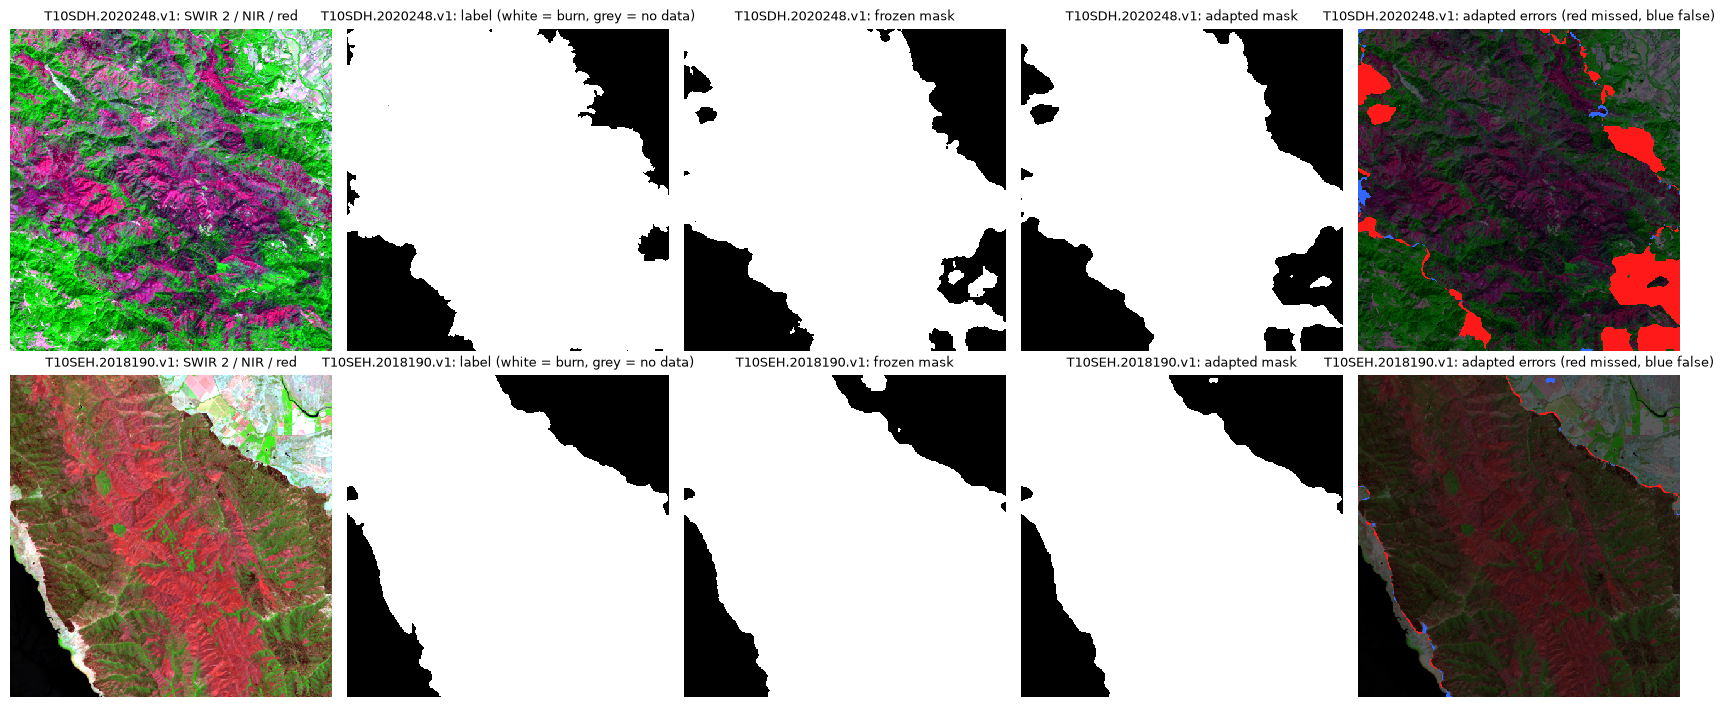

{'report': 'outputs/prithvi_burnscar_segmentation_evaluation_report.json'}


In [ ]:
adapted_test = pipe.evaluate(test_records)
adapted_val = pipe.evaluate(val_records)
comparison = {}
for key in ('mean_iou', 'accuracy', 'precision', 'recall', 'f1'):
    comparison[key] = {'baseline_not_burned': frozen_test['baseline_not_burned'][key], 'frozen': frozen_test['model'][key], 'adapted': adapted_test['model'][key]}
comparison['burn_iou'] = {'baseline_not_burned': frozen_test['baseline_not_burned']['iou']['burn scar'], 'frozen': frozen_test['model']['iou']['burn scar'], 'adapted': adapted_test['model']['iou']['burn scar']}
for key, row in comparison.items():
    print({key: row})
delta_burn_iou = adapted_test['model']['iou'][CLASS_NAMES[1]] - frozen_test['model']['iou'][CLASS_NAMES[1]]
# SWP-A: the direction is a recorded verdict, never an assert, so a BYOD run always reaches export and result.json.
comparison['verdict'] = {'adapted_vs_frozen_burn_iou': 'improved' if delta_burn_iou > 0 else ('no change' if delta_burn_iou == 0 else 'worse'), 'delta': round(delta_burn_iou, 4)}
print({'verdict': comparison['verdict']})
print({'validation_burn_iou': {'frozen': frozen_val['model']['iou']['burn scar'], 'adapted': adapted_val['model']['iou']['burn scar']}, 'validation_loss': {'frozen': adapt_result['history'][0]['val_loss'], 'kept_epoch': adapt_result['history'][adapt_result['best_epoch']]['val_loss']}})
# BS-S4: per-scene burn-scar IoU (the pooled metric lets large burns dominate).
adapted_predictions = pipe.predict(test_records)
test_labels, test_ids = [r['label'] for r in test_records], [r.get('source_id', r['id']) for r in test_records]
per_scene = {'frozen': per_chip_burn_iou([p['mask'] for p in frozen_predictions['predictions']], test_labels, test_ids), 'adapted': per_chip_burn_iou([p['mask'] for p in adapted_predictions['predictions']], test_labels, test_ids)}
for f_row, a_row in zip(per_scene['frozen'], per_scene['adapted']):
    print({'scene': f_row['id'], 'burn_label': f_row['positive_fraction'], 'frozen_burn_iou': f_row['iou'], 'adapted_burn_iou': a_row['iou']})
comparison['per_scene_burn_iou_range'] = {name: [min(v), max(v)] if (v := [row['iou'] for row in rows if row['iou'] is not None]) else None for name, rows in per_scene.items()}
print({'per_scene_burn_iou_range': comparison['per_scene_burn_iou_range']})
# BS-m6: see the scenes, labels, masks and errors, not only the numbers.
import matplotlib.pyplot as plt

shown = list(zip(test_records, frozen_predictions['predictions'], adapted_predictions['predictions']))[:2]
fig, axes = plt.subplots(len(shown), 5, figsize=(17, 3.6 * len(shown)), squeeze=False)
for row, (record, frozen_pred, adapted_pred) in zip(axes, shown):
    label, composite = record['label'], false_colour_composite(record['image'])
    errors = composite * 0.35
    errors[(label == 1) & (adapted_pred['mask'] == 0)] = (1.0, 0.1, 0.1)
    errors[(label == 0) & (adapted_pred['mask'] == 1)] = (0.2, 0.4, 1.0)
    errors[label < 0] = 0.5
    panels = [('SWIR 2 / NIR / red', composite, None), ('label (white = burn, grey = no data)', np.where(label < 0, 0.5, label.astype(np.float32)), 'gray'), ('frozen mask', frozen_pred['mask'], 'gray'), ('adapted mask', adapted_pred['mask'], 'gray'), ('adapted errors (red missed, blue false)', errors, None)]
    for ax, (title, image, cmap) in zip(row, panels):
        ax.imshow(image, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
        ax.set_title(record.get('source_id', record['id']) + ': ' + title, fontsize=9)
        ax.set_axis_off()
fig.tight_layout()
fig.savefig('outputs/prithvi_burnscar_segmentation_test_scenes.png', dpi=80)
plt.show()
evaluation_report = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY},
    'data_source': data_source,
    'dataset': dataset_report,
    'frozen': {'test': frozen_test, 'validation': frozen_val},
    'adapted': {'test': adapted_test, 'validation': adapted_val},
    'per_scene_burn_iou': per_scene,
    'comparison': comparison,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
}
with open('outputs/prithvi_burnscar_segmentation_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, indent=2)
# Contract integrity (not model quality): epoch 0 is a selection candidate, and re-scoring reproduces the kept epoch.
if adapt_result['history'][adapt_result['best_epoch']]['val_loss'] > adapt_result['history'][0]['val_loss']:
    raise RuntimeError('contract: the kept epoch has a higher validation loss than the frozen model, which epoch selection cannot produce')
if abs(adapted_val['model']['iou'][CLASS_NAMES[1]] - adapt_result['history'][adapt_result['best_epoch']]['val']['iou'][CLASS_NAMES[1]]) >= 1e-2:
    raise RuntimeError('contract: re-scoring the validation scenes does not reproduce the kept epoch')
print({'report': 'outputs/prithvi_burnscar_segmentation_evaluation_report.json'})

**What to notice:** the `burn_iou` row (baseline, frozen, adapted), the `precision` and `recall` rows, the `verdict` line with its `delta`, the per-scene range, and in the figure where the red and blue pixels sit.

<details><summary>Check your reasoning</summary>No, and not the same way. In the recorded run the test burn-scar IoU moved from 0.9251 to 0.9263 (F1 0.9611 → 0.9618, accuracy 0.9833 → 0.9839): the verdict was *improved* by about 0.001, far inside what one seed and 12 scenes can resolve. Underneath that flat IoU, precision rose from 0.9528 to 0.9741 while recall fell from 0.9695 to 0.9498: the adapted model draws tighter scars — fewer unburned pixels called burned, more burned pixels missed — a trade that matters for burned-area mapping (a conservative map under-reports area) even when the IoU does not move. Read the verdict as *the contract ran and did no harm*, not as a gain, and read the per-scene range to see which scenes the pooled number hides. On scenes from another region or year the same delta is the number that matters.</details>

## 8. The upstream example scenes, artifact export and fresh reload

The adapted model segments the three example scenes that ship with the upstream model repository (three HLS tiles over California, 2018 and 2020). **None of them is new to the checkpoint**, and the cell says so for each scene from the files themselves: `example_provenance` hashes the scene, looks it up in the checkpoint's own `splits/train.txt`, `val.txt` and `test.txt`, and compares it with the 44 pinned sample records. `T10SEH.2018190.v1` is byte-identical to sample test scene `test-001`, which Section 7 has already scored — so here its mask is compared with that label (burn-scar IoU printed as `label_agreement`); `T10SFF.2018190.v1` and `T10SGF.2020217.v1` are in the checkpoint's training split, so their burn fractions show what the model reproduces on scenes it trained on, not generalisation. They are used because they are the only unlabelled-looking inputs the model repository ships; a real sanity check on *new* scenes needs scenes from outside this dataset, which is what BYOD is for.

`pipe.save_artifact` writes the trained tensors (about 81 MB) as `adapter.safetensors`, with a `manifest.json` recording the artifact format, the base model id and revision, the digest of the converted base file, the adaptation scope, the tensor names, the file size and SHA-256, the training configuration and the epoch history (OUT8). `PrithviBurnScarPipeline.from_artifact` re-verifies the base file, checks the artifact manifest, scope and digest **before** deserialising, rebuilds the model and overlays the tensors — a fresh object from files, not the in-memory model (VER2). The cell asserts the same held-out burn-scar IoU within 0.001 and score maps within 0.01 (VER4: float16 tolerances; on one device they are usually identical).

In [ ]:
import importlib.metadata
import platform
import shutil

import tifffile

example_dir = WEIGHTS_DIR / 'examples'
new_records = [{'id': path.stem.replace('subsetted_512x512_HLS.S30.', ''), 'image': read_chip(path), 'source': str(path.name)} for path in sorted(example_dir.glob('*.tif'))]
new_predictions = pipe.predict(new_records)
# BS-m2: say what each example scene is (checkpoint split files + pinned sample digests), never call it new.
provenance = {}
for record, pred in zip(new_records, new_predictions['predictions']):
    tifffile.imwrite(f'outputs/prithvi_burnscar_segmentation_mask_' + record['id'] + '.tif', pred['mask'])
    prov = example_provenance(example_dir / record['source'], WEIGHTS_DIR / 'splits')
    row = {'scene': record['id'], 'burn_fraction': pred['class_fraction']['burn scar'], 'checkpoint_split': prov['upstream_split'], 'sample_record': prov['sample_record']}
    labelled = [r for r in test_records if r.get('source_id') == (prov['sample_record'] or {}).get('key')]
    if labelled:
        row['label_agreement'] = per_chip_burn_iou([pred['mask']], [labelled[0]['label']], [labelled[0]['id']])[0]
        row['note'] = 'a sample test scene already scored in Section 7 (byte-identical); compared with its label here'
    elif prov['upstream_split']:
        row['note'] = 'in the checkpoint ' + '/'.join(prov['upstream_split']) + ' split: reproduction on a training scene, not generalisation'
    else:
        row['note'] = 'not in the checkpoint split files or the sample: a sanity check without a label'
    provenance[record['id']] = row
    print(row)
with open('outputs/prithvi_burnscar_segmentation_predictions.json', 'w', encoding='utf-8') as f:
    json.dump({'model': new_predictions['model'], 'classes': new_predictions['classes'], 'decision_rule': new_predictions['decision_rule'], 'predictions': [{'id': p['id'], 'class_fraction': p['class_fraction'], 'provenance': provenance[p['id']]} for p in new_predictions['predictions']]}, f, indent=2)

artifact_dir = Path('outputs/prithvi_burnscar_segmentation_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'prithvi_burnscar_segmentation', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'trainable': artifact_manifest['adapter']['trainable'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...'})

reloaded = PrithviBurnScarPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device)
reloaded_test = reloaded.evaluate(test_records)
before = pipe.predict(test_records[:2])['predictions']
after = reloaded.predict(test_records[:2])['predictions']
parity = {'positive_iou_diff': round(abs(reloaded_test['model']['iou'][CLASS_NAMES[1]] - adapted_test['model']['iou'][CLASS_NAMES[1]]), 6), 'metrics_identical': reloaded_test['model'] == adapted_test['model'], 'max_abs_score_diff': max(float(np.abs(a['scores'] - b['scores']).max()) for a, b in zip(before, after))}
print({'reload_parity': parity, 'reloaded_best_epoch': reloaded.adapter['best_epoch']})
assert parity['positive_iou_diff'] < 1e-3 and parity['max_abs_score_diff'] < 1e-2

result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model': {**evaluation_report['model'], 'model_license': MODEL_LICENSE, 'device': pipe.device, 'source': pipe.source},
    'provenance': {
        'source_asset': [e for e in MANIFEST['files'] if e['path'] == SOURCE_CKPT_NAME],
        'pickle_audit_sha256': PICKLE_AUDIT_SHA256,
        'converted': verify_converted(WEIGHTS_DIR)['files'],
        'pickle_unpickled_once_for_conversion': True,
        'served_from_pickle': False,
        'remote_code_executed': False,
        'data_tarball': {'name': TAR_NAME, 'sha256': TAR_SHA256, 'pinned_members': 2 * len(SAMPLE_RECORDS)},
        'data_base_url': CORPUS_BASE_URL,
        'data_license': CORPUS_LICENSE,
    },
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'timm': timm.__version__, 'lightning': lightning.__version__, 'tifffile': tifffile.__version__, 'terratorch': importlib.metadata.version('terratorch')},
    'data_source': data_source,
    'comparison': comparison,
    'verdict': comparison['verdict'],
    'example_scenes': provenance,
    'adaptation_gpu_peak_gb': adapt_result['gpu_peak_gb'],
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes']},
    'reload_parity': parity,
}
with open('outputs/prithvi_burnscar_segmentation_result.json', 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, indent=2)

print('outputs/:')
for path in sorted(Path('outputs').rglob('*')):
    if path.is_file():
        print(f'  - {path.as_posix()} ({path.stat().st_size / 1024:.1f} KB)')

{'scene': 'T10SEH.2018190.v1.4_merged', 'burn_fraction': 0.7891, 'checkpoint_split': ['test'], 'sample_record': {'key': 'T10SEH.2018190.v1', 'role': 'test'}, 'label_agreement': {'id': 'test-001', 'iou': 0.9937, 'positive_fraction': 0.7911, 'labelled_pixels': 262144}, 'note': 'a sample test scene already scored in Section 7 (byte-identical); compared with its label here'}
{'scene': 'T10SFF.2018190.v1.4_merged', 'burn_fraction': 0.0208, 'checkpoint_split': ['train'], 'sample_record': None, 'note': 'in the checkpoint train split: reproduction on a training scene, not generalisation'}
{'scene': 'T10SGF.2020217.v1.4_merged', 'burn_fraction': 0.4168, 'checkpoint_split': ['train'], 'sample_record': None, 'note': 'in the checkpoint train split: reproduction on a training scene, not generalisation'}


{'artifact': 'outputs/prithvi_burnscar_segmentation_adapter', 'format': 'org.valcorza.prithvi-burnscar-segmentation.adapter.v1', 'trainable': 'decoder', 'tensors': 34, 'bytes': 81276896, 'sha256': '181e924e58aeba50...'}


{'reload_parity': {'positive_iou_diff': 0.0, 'metrics_identical': True, 'max_abs_score_diff': 0.0}, 'reloaded_best_epoch': 1}


outputs/:
  - outputs/prithvi_burnscar_segmentation_adapter/adapter.safetensors (79372.0 KB)
  - outputs/prithvi_burnscar_segmentation_adapter/manifest.json (5.8 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/pairs.csv (1.8 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-000.mask.tif (512.3 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-000_merged.tif (6144.4 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-001.mask.tif (512.3 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-001_merged.tif (6144.4 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-002.mask.tif (512.3 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-002_merged.tif (6144.4 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-003.mask.tif (512.3 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-003_merged.tif (6144.4 KB)
  - outputs/prithvi_burnscar_segmentation_byod_example/test-004.mask.tif (51

**What to notice:** each example scene's `checkpoint_split` and `sample_record`, the `label_agreement` of the one that is a sample test scene, the artifact's size and tensor count, and `reload_parity`.

<details><summary>Check your reasoning</summary>One example scene is sample test scene `test-001` (in the recorded run its label had burn fraction 0.791 and the adapted model predicted 0.7891), the other two are in the checkpoint's training split, so none of the three burn fractions says anything about new scenes. In the recorded run the adapter (34 tensors, about 81 MB) reloaded into a fresh pipeline with identical held-out metrics (`positive_iou_diff` 0.0, `metrics_identical` True, `max_abs_score_diff` 0.0): the adapter plus the pinned, re-verified base is the whole adapted model.</details>

## Interpretation and limits

On 12 held-out scenes from the model repository's test split the packaged burn-scar model finds burn scars with an IoU above 0.9, against a not-burned baseline that scores 0; a bounded fine-tuning of its neck, decoder and head on 24 scenes, selected by validation loss with the frozen model as a candidate, leaves the IoU where it was (0.9251 → 0.9263 in the build record) while trading recall for precision underneath it (precision 0.9528 → 0.9741, recall 0.9695 → 0.9498): a tighter, more conservative scar map. That is the claim: the adaptation contract runs end to end on real labelled multispectral scenes drawn from a digest-verified tarball, the pickle is audited and converted rather than served, and the artifact that carries the change is 81 MB and reloads with the same outputs. It is not a claim that this sample improves the model — the model already trained on this dataset — nor that 12 scenes measure its skill.

The numbers are sample-sanity evidence: one seeded run, 12 test scenes from a handful of HLS tiles, no dispersion estimate, pixel-pooled metrics that let large burns dominate, and labels derived from a burned-area product with their own uncertainty at scar edges and under smoke. Nothing here measures the model outside the contiguous United States, outside 2018–2021, on scenes larger than a chip, or on burn severity.

Three things to carry to real data. **The six bands and their scaling are the contract:** blue, green, red, narrow NIR, SWIR 1, SWIR 2 in that order, surface reflectance in [0, 1]; a different band order or an uncorrected product is segmented without complaint and silently wrong. **Split by fire or tile, not by scene:** neighbouring scenes of one fire are near-duplicates, and a random split makes memorisation look like skill. **Read the baseline first:** on a scene with 5 % burn the not-burned baseline is 95 % accurate; only the burn-scar IoU, precision and recall say whether the model did anything.

Successful execution proves that the recorded repository revision's pipeline modules, carried in this standalone notebook, can acquire and digest-verify a pickled upstream checkpoint, audit and convert it into safetensors without executing anything outside the audited allow-list, rebuild the model from the installed package, fetch a digest-pinned tarball and extract exactly the pinned labelled scenes, execute bounded fine-tuning, evaluate against a baseline and the frozen model on held-out scenes, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or burn-mapping skill beyond the checks shown.

## Optional experiment: Predict → Change → Run → Observe → Explain

None of this affects the default path, and every adaptation starts from the pinned base, so each run is a fresh experiment rather than continued training. **Scope of a re-run:** change the form field in Section 6, then run Sections 6, 7 and 8 in that order (Section 5 need not be re-run; if you do, it restores the base and prints `restored_pinned_base`). Pick one:

1. **Learning rate.** *Predict:* with `LEARNING_RATE = 1e-4` (ten times the default) on a model that already trained on this dataset, will any epoch beat the frozen model's validation loss (0.1072 in the record), or will epoch 0 be kept? *Change* the field, *run* 6–8, *observe* `best_epoch`, the per-epoch `val_loss` and the verdict, and *explain* the result in terms of what a larger step does to a model near a minimum. There is no recorded outcome for this setting; your run is the evidence.
2. **Scope.** *Predict:* does `TRAINABLE = 'decoder+last_block'` (32.9 M parameters) change the validation loss curve or the precision/recall trade? *Observe* `trainable_parameters`, `gpu_peak_gb` and the comparison rows.
3. **Epochs.** *Predict:* with `EPOCHS = 10`, where does the validation loss bottom out, and does the kept epoch change? *Observe* the drift after the minimum and whether the verdict moves.
4. **Your own scenes.** Set `USE_BYOD = True` with `BYOD_PATH` (a `group` column keeps one fire in one role) and re-run from Section 4: read the not-burned baseline before the adapted number, and compare the frozen column — the packaged model — with the adapted one.

## Troubleshooting

- **Section 1 stops with "This notebook needs a Linux x86_64 runtime"** — you are on Windows, macOS or an ARM machine. Use Google Colab, Kaggle or a Linux x86_64 Jupyter server.
- **The uv wheel fails its size/SHA-256 check, or a download in Section 1 times out** — run Section 1 again; a complete environment built from the same lock is reused, an incomplete one is finished. If it repeats, the network is blocking or altering `files.pythonhosted.org` or `pypi.org`.
- **"The isolated environment's Python process exited"** — usually out of memory. Restart the session and choose **Run all**.
- **You re-ran Section 1 on its own** — nothing is lost: it keeps the running worker and every variable, so the cells after it keep working. After a session restart, run from the top.
- **Section 3 reports a size or SHA-256 mismatch, or cannot reach the Hub** — the message names the file. Delete it from the snapshot folder Section 3 prints and run Section 3 again.
- **Section 3 stops during the pickle audit or conversion** — the audit refuses any global outside the allow-list and names it; the downloaded checkpoint is not the pinned one. Delete the snapshot folder and run Section 3 again.
- **Section 4 stops on the tarball's size or SHA-256** — the 2.6 GB download was cut short or altered. Run Section 4 again: a truncated download is fetched again, and scenes already extracted and verified are reused. If the digest still fails, delete `weights/hls-burn-scars/` and run it once more.
- **CUDA out of memory in Section 6** — another notebook holds the GPU, or `TRAINABLE = 'decoder+last_block'` with a larger `BATCH_SIZE` exceeds a T4. Restart the session, keep `BATCH_SIZE = 2`, and choose **Run all**.
- **Section 7 shows no figure** — the figure is also written to `outputs/prithvi_burnscar_segmentation_test_scenes.png`; on Jupyter make sure the notebook is trusted.
- **Section 5 prints `restored_pinned_base`** — you re-ran it after Section 6; the adapted tensors were put back to the base. Re-run Sections 6–8 in order.
- **BYOD: a band, shape or label refusal** — the message names the rule; chips must be six-band 512 × 512 GeoTIFFs in the documented band order with masks of 0 / 1 / −1, and the dataset needs some burn-scar pixels.
- **BYOD: "… bring at least 7 chips"** — the seeded split takes 25 % for test and 20 % for validation and must leave 4 training chips, so 7 distinct labelled chips is the minimum (more if a `group` column puts many chips in one group).
- **BYOD: "pairs.csv row … is listed but not in the zip"** or **"… is not a readable GeoTIFF"** — the message names the row and the file; fix the name in `pairs.csv` or replace the file. `outputs/prithvi_burnscar_segmentation_byod_example/` is a complete, loadable example of the layout.
- **BYOD: "chips have no 'group'"** — either give every row a `group` value (a fire or tile id) or leave the column out.
- **BYOD: "BYOD_PATH … does not exist"** — the path is relative to the working directory printed in the message.
- **BYOD: "the upload dialog exists only in Google Colab"** — on Kaggle or Jupyter, put the zip (or folder) in the runtime and set `BYOD_PATH` to its path.
- **BYOD: "Upload exactly one .zip file"** — the dialog was cancelled or several files were chosen; run the cell again.

## Glossary

- **HLS (Harmonized Landsat Sentinel-2):** NASA's surface-reflectance product that puts Landsat 8/9 and Sentinel-2 on one 30 m grid; the six bands here are blue, green, red, narrow NIR, SWIR 1 and SWIR 2.
- **Surface reflectance:** the fraction of sunlight a surface reflects in a band, after atmospheric correction; stored in [0, 1] or × 10 000.
- **Burn scar:** ground whose vegetation was removed or charred by fire; it darkens NIR and brightens SWIR, which is what the model keys on.
- **Segmentation mask / ignore class:** one class per pixel; −1 marks no-data pixels that are excluded from training and scoring.
- **Not-burned baseline:** predicting *not burned* for every pixel; its accuracy equals the unburned fraction and its burn-scar IoU is 0.
- **IoU, precision, recall, F1:** overlap of predicted and true burn pixels; the share of predicted burn that is real; the share of real burn found; their harmonic mean.
- **Encoder, neck, decoder, head:** the ViT-L backbone that turns patches into features; the pyramid that rescales them; the U-Net that upsamples them to pixels; the final two-class layer.
- **Frozen / adapted:** the packaged model as downloaded / after Section 6 trained the neck, decoder and head.
- **Pinned base:** the verified packaged weights; every adaptation starts from them (`restore_base`).
- **Group (fire or tile) split:** assigning every chip of one fire or HLS tile to one role, so near-duplicate neighbours cannot sit in both training and test; the `group` column of `pairs.csv`.
- **Precision / recall trade:** a model can raise precision (fewer false burned pixels) while lowering recall (more missed burned pixels) with the IoU barely moving; Section 7 shows both.
- **BatchNorm statistics:** running means and variances inside the decoder; kept fixed because two-scene batches would corrupt them.
- **Validation-loss selection:** keeping the epoch with the lowest validation loss, with the frozen model as epoch 0.
- **Pickle audit / safetensors:** the upstream checkpoint is a pickle that could run code when loaded; it is statically checked against an allow-list and converted once to safetensors, a format that stores only tensors.
- **Isolated environment:** the separate Python environment Section 1 builds from the hash lock; every later cell runs there.

## Conclusion (your notes)

Complete these in your own words; the recorded run's values are in the **Check your reasoning** answers above.

- The frozen model's test burn-scar IoU was ___ against the not-burned baseline's ___.
- Bounded fine-tuning moved it to ___ (verdict: ___) and moved precision ___ and recall ___, which I read as ___.
- The number I would not trust on its own is ___, because ___.
- Before adapting on my own scenes I would check the band order and scaling, split by ___, and compare against ___.

## References

- Repository README: https://github.com/kurtvalcorza/prithvi-burnscar-segmentation-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/prithvi-burnscar-segmentation-pipeline/blob/main/MODEL_CARD.md
- Weights and conversion notes: https://github.com/kurtvalcorza/prithvi-burnscar-segmentation-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face model repository: https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars (revision `a3f2c410e45b8ac7417976614528a872f024d831`)
- HLS Burn Scars dataset: https://huggingface.co/datasets/ibm-nasa-geospatial/hls_burn_scars (CC BY 4.0)
- Szwarcman, D., Roy, S., Fraccaro, P., et al. (2024). Prithvi-EO-2.0: A versatile multi-temporal foundation model for Earth observation applications. arXiv:2412.02732: https://arxiv.org/abs/2412.02732
- TerraTorch: https://github.com/IBM/terratorch
- DIMER Notebook Specification 2.0 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)